<a href="https://colab.research.google.com/github/DylanChrisWong/Radiomics-GenAI/blob/main/Radiomics_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Clean Generative AI Classification Analysis
===========================================

A clean, professional machine learning pipeline for comparing classification models
on original and synthetic datasets.

Author: dylan
Date: 2026-04-24
"""

'\nClean Generative AI Classification Analysis\n===========================================\n\nA clean, professional machine learning pipeline for comparing classification models\non original and synthetic datasets.\n\nAuthor: dylan\nDate: 2026-04-24\n'

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F

In [ ]:
!pip install ctgan
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from ctgan import CTGAN
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import os
from typing import Dict, Tuple, List, Any

from sklearn.linear_model import Lasso
# Step 6: Import necessary libraries
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from google.colab import drive
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)

# Configuration
CONFIG = {
    # 'test_size': 0.2,
    'random_state': 42,
    'cv_folds': 5,
    'cv_shuffle': True,
    'cv_random_state': 42,
}

In [ ]:
import pandas as pd

# Dictionary of file paths
data_paths = {
    'X_train': '/content/drive/MyDrive/Generative AI/Data/x_train.csv',
    'X_test': '/content/drive/MyDrive/Generative AI/Data/x_test.csv',
    'y_train': '/content/drive/MyDrive/Generative AI/Data/y_train.csv',
    'y_test': '/content/drive/MyDrive/Generative AI/Data/y_test.csv'
}

# Read all CSV files into DataFrames
dfs = {}
for key, path in data_paths.items():
    dfs[key] = pd.read_csv(path)

# Access individual DataFrames
X_train = dfs['X_train']
X_test = dfs['X_test']
y_train = dfs['y_train']
y_test = dfs['y_test']

# Check the shapes to verify
# print(f"X_train shape: {X_train.shape}")
# print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (9435, 1)
y_test shape: (1709, 1)


In [ ]:
X_train

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.830399,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.724026,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.650363,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.594166,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.633244,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.238112,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.269532,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.301243,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.241782,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290


In [ ]:
y_train

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X_test

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.755419,0.742857,0.328281,0.719474,0.705882,0.005986,0.98008,0.599990,0.772049,0.833333,...,0.282166,0.156319,0.337306,0.845606,0.035094,0.910987,8.630000e-06,0.860953,0.196355,0.000335
1,0.944571,0.885714,0.446098,0.879273,0.823529,0.005834,1.00000,0.702474,0.897706,1.000000,...,0.311853,0.159442,0.323738,0.817473,0.032639,0.810202,8.890000e-06,0.836485,0.203410,0.000352
2,0.863989,0.800000,0.377980,0.792507,0.764706,0.005792,1.00000,0.647076,0.820914,0.833333,...,0.259871,0.151897,0.352882,0.927471,0.035085,0.861046,8.130000e-06,0.920208,0.232400,0.000317
3,0.928945,0.914286,0.454917,0.902293,0.882353,0.004693,1.00000,0.717258,0.914204,0.833333,...,0.298058,0.169830,0.354851,0.881908,0.037470,1.000000,7.940000e-06,0.952587,0.217515,0.000314
4,0.700874,0.628571,0.254369,0.586588,0.529412,0.010803,1.00000,0.520996,0.639362,0.666667,...,0.231350,0.157895,0.326420,0.883110,0.031653,0.826711,8.590000e-06,0.862925,0.234978,0.000342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,0.073327,0.116279,0.024623,0.012458,0.100000,0.009888,0.21200,0.117338,0.093825,0.000000,...,0.078283,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816
1705,0.064675,0.093023,0.020482,0.007747,0.100000,0.010193,0.18400,0.106537,0.085278,0.000000,...,0.078564,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108
1706,0.080431,0.116279,0.028073,0.015377,0.100000,0.009173,0.22800,0.126704,0.101969,0.000000,...,0.078101,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438
1707,0.089851,0.162791,0.044603,0.033063,0.150000,0.007454,0.28800,0.161883,0.138749,0.125000,...,0.077030,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857


In [ ]:
y_test

,labels
0,0
1,0
2,0
3,0
4,0
...,...
1704,1
1705,1
1706,1
1707,1


In [ ]:
y_train

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
y_test

,labels
0,0
1,0
2,0
3,0
4,0
...,...
1704,1
1705,1
1706,1
1707,1


In [ ]:
/content/drive/MyDrive/Zenodo_dataset/Zenodo_dataset

In [ ]:
data_path = '/content/drive/MyDrive/Zenodo_dataset/Zenodo_dataset'
files = os.listdir(data_path)
print("Files found:", files)

Files found: ['B_test', 'B_train', 'M_test', 'M_train']


In [ ]:
folders = ['B_train', 'M_test', 'B_test', 'M_train']

In [ ]:
import os
import pandas as pd

data_path = '/content/drive/MyDrive/Zenodo_dataset/Zenodo_dataset'
folders = ['B_train', 'M_test', 'B_test', 'M_train']

# Save one CSV per folder
for folder in folders:
    folder_path = os.path.join(data_path, folder)

    if os.path.exists(folder_path):
        # Get all files in the folder
        files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]

        # Create DataFrame for this folder
        df = pd.DataFrame({
            'Filename': files,
            'Full_Path': [os.path.join(folder_path, f) for f in files],
            'Folder': folder,
            'Category': folder.split('_')[0],  # B or M
            'Set': folder.split('_')[1]        # train or test
        })

        # Save CSV
        csv_path = f'/content/{folder}.csv'
        df.to_csv(csv_path, index=False)

        print(f"✓ Saved: {csv_path}")
        print(f"  - {len(files)} files from {folder}")
        print(f"  - Columns: {list(df.columns)}")
        print()
    else:
        print(f"✗ Folder not found: {folder}")

print("All CSV files saved successfully to /content/")

✓ Saved: /content/B_train.csv
  - 6491 files from B_train
  - Columns: ['Filename', 'Full_Path', 'Folder', 'Category', 'Set']

✓ Saved: /content/M_test.csv
  - 543 files from M_test
  - Columns: ['Filename', 'Full_Path', 'Folder', 'Category', 'Set']

✓ Saved: /content/B_test.csv
  - 1166 files from B_test
  - Columns: ['Filename', 'Full_Path', 'Folder', 'Category', 'Set']

✓ Saved: /content/M_train.csv
  - 2944 files from M_train
  - Columns: ['Filename', 'Full_Path', 'Folder', 'Category', 'Set']

All CSV files saved successfully to /content/


In [ ]:
# Read all four CSV files
B_train_dfname = pd.read_csv('/content/B_train.csv')
M_train_dfname = pd.read_csv('/content/M_train.csv')

B_test_dfname = pd.read_csv('/content/B_test.csv')
M_test_dfname = pd.read_csv('/content/M_test.csv')

In [ ]:
# Concatenate rows
merged_trainname = pd.concat([B_train_dfname, M_train_dfname], axis=0, ignore_index=True)
merged_testname = pd.concat([B_test_dfname, M_test_dfname], axis=0, ignore_index=True)

In [ ]:
merged_trainname

,Filename,Full_Path,Folder,Category,Set
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train


In [ ]:
# Extract patient ID (everything before the space)
merged_trainname['Patient_ID'] = merged_trainname['Filename'].str.split(' ').str[0]

# Verify the result
print(merged_trainname[['Filename', 'Patient_ID']].head(10))

         Filename Patient_ID
0    P175 (8).jpg       P175
1    P175 (9).jpg       P175
2    P176 (1).jpg       P176
3   P176 (10).jpg       P176
4  P176 (100).jpg       P176
5  P176 (101).jpg       P176
6  P176 (102).jpg       P176
7  P176 (103).jpg       P176
8  P176 (104).jpg       P176
9  P176 (105).jpg       P176


In [ ]:
merged_trainname

,Filename,Full_Path,Folder,Category,Set,Patient_ID
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176
...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100


In [ ]:
y_train

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X_train_ful=pd.concat([merged_trainname,X_train, y_train],axis=1)
X_test_ful=pd.concat([merged_testname,X_test,y_test],axis=1)

In [ ]:
X_train_ful.drop(columns=['Filename', 'Full_Path', 'Folder', 'Category', 'Set'], inplace=True)

KeyError: "['Filename', 'Full_Path', 'Folder', 'Category', 'Set'] not found in axis"

In [ ]:
X_train_ful

,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
X_train_ful.to_csv('/content/drive/MyDrive/Generative AI/Data/X_train_ful.csv', index=False)

In [ ]:
X_train_ful

,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
# Install if needed: pip install scikit-learn
from sklearn.model_selection import StratifiedGroupKFold

patient_col = 'Patient_ID'  # Change to your patient column name
target_col = 'labels'      # Change to your target/label column

fold_results = []

sgkf = StratifiedGroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_train_ful, X_train_ful[target_col], groups=X_train_ful[patient_col])):
    train_df = X_train_ful.iloc[train_idx]
    val_df = X_train_ful.iloc[val_idx]

    print(f"Fold {fold + 1}:")
    print(f"  Train: {len(train_df)} samples")
    print(f"  Val: {len(val_df)} samples")
    print(f"  Train class distribution:\n{train_df[target_col].value_counts().to_dict()}")
    print()
        # Store the indices for later use
    fold_results.append({
        'fold': fold,
        'train_idx': train_idx,
        'val_idx': val_idx,
        'train_df': train_df,
        'val_df': val_df
    })


Fold 1:
  Train: 7548 samples
  Val: 1887 samples
  Train class distribution:
{0: 5193, 1: 2355}

Fold 2:
  Train: 7547 samples
  Val: 1888 samples
  Train class distribution:
{0: 5193, 1: 2354}

Fold 3:
  Train: 7550 samples
  Val: 1885 samples
  Train class distribution:
{0: 5193, 1: 2357}

Fold 4:
  Train: 7546 samples
  Val: 1889 samples
  Train class distribution:
{0: 5193, 1: 2353}

Fold 5:
  Train: 7549 samples
  Val: 1886 samples
  Train class distribution:
{0: 5192, 1: 2357}



In [ ]:
# Access specific folds
fold_0_train = fold_results[0]['train_df']
fold_0_val = fold_results[0]['val_df']

# Or directly
for fold_data in fold_results:
    fold_num = fold_data['fold']
    train_data = fold_data['train_df']
    val_data = fold_data['val_df']

    print(f"Processing Fold {fold_num + 1}")
    print(f"  Train shape: {train_data.shape}")
    print(f"  Val shape: {val_data.shape}")

    # Train your model here
    # model.fit(train_data.drop(columns=[target_col, patient_col]), train_data[target_col])
    # val_predictions = model.predict(val_data.drop(columns=[target_col, patient_col]))

Processing Fold 1
  Train shape: (7548, 184)
  Val shape: (1887, 184)
Processing Fold 2
  Train shape: (7547, 184)
  Val shape: (1888, 184)
Processing Fold 3
  Train shape: (7550, 184)
  Val shape: (1885, 184)
Processing Fold 4
  Train shape: (7546, 184)
  Val shape: (1889, 184)
Processing Fold 5
  Train shape: (7549, 184)
  Val shape: (1886, 184)


In [ ]:
for fold_data in fold_results:
    fold_num = fold_data['fold']

    # Assuming your fold_data contains these keys
    X_train = fold_data['X_train']  # DataFrame of features
    X_val = fold_data['X_val']      # DataFrame of features
    y_train = fold_data['y_train']  # Series/array of target
    y_val = fold_data['y_val']      # Series/array of target

    print(f"\nFold {fold_num + 1}: Train {X_train.shape}, Val {X_val.shape}")

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # Test alpha=0.01
    lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)

    # Find optimal
    lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_cv.fit(X_train_scaled, y_train)

    print(f"  Alpha 0.01: Val R²={lasso.score(X_val_scaled, y_val):.4f}, Features={np.sum(lasso.coef_ != 0)}")
    print(f"  Optimal:    Val R²={lasso_cv.score(X_val_scaled, y_val):.4f}, Features={np.sum(lasso_cv.coef_ != 0)}, Alpha={lasso_cv.alpha_:.6f}")

    # Check if 0.01 is reasonable
    if lasso_cv.alpha_ < 0.005:
        print(f"  ⚠ 0.01 is TOO STRONG - optimal is {lasso_cv.alpha_:.6f}")
    elif lasso_cv.alpha_ > 0.1:
        print(f"  ⚠ 0.01 is TOO WEAK - optimal is {lasso_cv.alpha_:.6f}")
    else:
        print(f"  ✓ 0.01 is in a reasonable range")

KeyError: 'X_train'

In [ ]:
X_train

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.830399,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.724026,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.650363,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.594166,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.633244,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.238112,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.269532,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.301243,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.241782,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290


In [ ]:
selected_features

['original_firstorder_RootMeanSquared_2',
 'original_firstorder_Uniformity_2',
 'original_glcm_ClusterShade_2',
 'original_glcm_Contrast_2',
 'original_glcm_Imc2_2',
 'original_glrlm_RunLengthNonUniformity_2',
 'original_glrlm_RunVariance_2',
 'original_glrlm_ShortRunLowGrayLevelEmphasis_2',
 'original_glszm_LargeAreaEmphasis_2',
 'original_glszm_LargeAreaLowGrayLevelEmphasis_2',
 'original_glszm_LowGrayLevelZoneEmphasis_2',
 'original_glszm_SmallAreaEmphasis_2',
 'original_glszm_SmallAreaLowGrayLevelEmphasis_2',
 'original_gldm_DependenceNonUniformity_2',
 'original_gldm_LargeDependenceHighGrayLevelEmphasis_2',
 'original_gldm_SmallDependenceHighGrayLevelEmphasis_2',
 'original_gldm_SmallDependenceLowGrayLevelEmphasis_2',
 'original_firstorder_Minimum_1',
 'original_firstorder_Skewness_1',
 'original_glcm_ClusterTendency_1',
 'original_gldm_DependenceVariance_1',
 'original_gldm_LargeDependenceLowGrayLevelEmphasis_1']

In [ ]:
# /content/drive/MyDrive/ful_data_df.csv
ful_data_df = pd.read_csv('/content/drive/MyDrive/ful_data_df.csv')

In [ ]:
ful_data_df

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.582547,0.545455,0.396354,0.616884,0.40,...,0.818368,0.025265,0.014643,0.070803,0.053259,1.270768e-01,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.645040,0.527273,0.434862,0.628177,0.55,...,0.801259,0.150401,0.144197,0.113444,0.159663,4.533057e-02,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.649142,0.490909,0.466725,0.598950,0.50,...,0.732614,0.139834,0.145134,0.102257,0.156583,4.500873e-02,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.689844,0.509091,0.456378,0.615469,0.55,...,0.657548,0.131487,0.146848,0.088266,0.139622,4.549148e-02,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.515126,0.363636,0.254387,0.446446,0.35,...,0.710785,0.122062,0.135625,0.092403,0.139296,4.822709e-02,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11139,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.073327,0.116279,0.024623,0.012458,0.10,...,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816,1
11140,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.064675,0.093023,0.020482,0.007747,0.10,...,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108,1
11141,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.080431,0.116279,0.028073,0.015377,0.10,...,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438,1
11142,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.089851,0.162791,0.044603,0.033063,0.15,...,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857,1


In [ ]:
# X_train_ful=ful_data_df

In [ ]:
# import pandas as pd
# from sklearn.model_selection import StratifiedGroupKFold

# # Step 2: Extract Patient_ID from Filename column
# # Assuming X_train_ful contains your data with 'Filename' column
# X_train_ful['Patient_ID'] = X_train_ful['Filename'].str.split(' ').str[0]

# # Verify Patient_ID extraction
# print("Patient_ID extraction sample:")
# print(X_train_ful[['Filename', 'Patient_ID']].head(10))
# print(f"\nTotal unique patients: {X_train_ful['Patient_ID'].nunique()}")
# print(f"Total samples: {len(X_train_ful)}")

# # Step 3: Define your columns
# patient_col = 'Patient_ID'
# target_col = 'labels'  # Make sure this matches your target column name

# X = X_train_ful
# y = X_train_ful
# groups = X_train_ful[patient_col]

# print(f"\nFeature matrix shape: {X.shape}")
# print(f"Target shape: {y.shape}")
# print(f"Unique classes in target: {y.unique()}")

# # Step 6: Perform StratifiedGroupKFold
# sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# # Step 7: Iterate through folds
# for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
#     # Split the data
#     X_train_fold = X.iloc[train_idx]
#     y_train_fold = y.iloc[train_idx]
#     X_val_fold = X.iloc[val_idx]
#     y_val_fold = y.iloc[val_idx]

#     # Get patient info for this fold
#     train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
#     val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

#     print(f"\n{'='*50}")
#     print(f"FOLD {fold + 1}")
#     print(f"{'='*50}")
#     print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
#     print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
#     print(f"\nTraining class distribution:")
#     print(y_train_fold.value_counts())
#     print(f"\nValidation class distribution:")
#     print(y_val_fold.value_counts())

#     # Check for patient leakage (should be empty)
#     overlapping_patients = set(train_patients) & set(val_patients)
#     if overlapping_patients:
#         print(f"WARNING: Patient leakage detected: {overlapping_patients}")
#     else:
#         print(f"\n✓ No patient leakage - patients are properly separated!")

Patient_ID extraction sample:
         Filename Patient_ID
0    P175 (8).jpg       P175
1    P175 (9).jpg       P175
2    P176 (1).jpg       P176
3   P176 (10).jpg       P176
4  P176 (100).jpg       P176
5  P176 (101).jpg       P176
6  P176 (102).jpg       P176
7  P176 (103).jpg       P176
8  P176 (104).jpg       P176
9  P176 (105).jpg       P176

Total unique patients: 180
Total samples: 9435

Feature matrix shape: (9435, 189)
Target shape: (9435, 189)


AttributeError: 'DataFrame' object has no attribute 'unique'

In [ ]:
train0=pd.connact[train_patients

array(['P175', 'P178', 'P179', 'P181', 'P183', 'P187', 'P189', 'P190',
       'P191', 'P192', 'P193', 'P195', 'P196', 'P200', 'P203', 'P206',
       'P209', 'P146', 'P147', 'P150', 'P152', 'P159', 'P162', 'P164',
       'P166', 'P169', 'P171', 'P174', 'P125', 'P127', 'P130', 'P131',
       'P132', 'P133', 'P134', 'P137', 'P139', 'P143', 'P144', 'P093',
       'P094', 'P095', 'P102', 'P109', 'P112', 'P113', 'P115', 'P116',
       'P119', 'P120', 'P122', 'P071', 'P072', 'P073', 'P074', 'P076',
       'P077', 'P078', 'P079', 'P081', 'P082', 'P083', 'P086', 'P087',
       'P088', 'P089', 'P091', 'P033', 'P034', 'P038', 'P039', 'P043',
       'P044', 'P045', 'P047', 'P048', 'P052', 'P054', 'P055', 'P056',
       'P057', 'P058', 'P059', 'P060', 'P061', 'P062', 'P002', 'P003',
       'P007', 'P010', 'P011', 'P014', 'P016', 'P017', 'P019', 'P022',
       'P023', 'P027', 'P151', 'P153', 'P154', 'P156', 'P157', 'P158',
       'P160', 'P165', 'P172', 'P177', 'P182', 'P185', 'P194', 'P198',
      

In [ ]:
train0 = pd.concat([X_train_fold, y_train_fold], axis=1)

In [ ]:
train0

,original_firstorder_RootMeanSquared_2,original_firstorder_Uniformity_2,original_glcm_ClusterShade_2,original_glcm_Contrast_2,original_glcm_Imc2_2,original_glrlm_RunLengthNonUniformity_2,original_glrlm_RunVariance_2,original_glrlm_ShortRunLowGrayLevelEmphasis_2,original_glszm_LargeAreaEmphasis_2,original_glszm_LargeAreaLowGrayLevelEmphasis_2,...,original_gldm_DependenceNonUniformity_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_gldm_SmallDependenceHighGrayLevelEmphasis_2,original_gldm_SmallDependenceLowGrayLevelEmphasis_2,original_firstorder_Minimum_1,original_firstorder_Skewness_1,original_glcm_ClusterTendency_1,original_gldm_DependenceVariance_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,labels
0,0.627484,0.410174,0.223471,0.065543,0.920643,0.049929,0.029236,0.232920,0.000137,0.000137,...,0.443615,0.531885,0.063977,0.088740,0.0,0.466538,0.807415,0.303836,0.830399,0
1,0.657526,0.401064,0.297128,0.080514,0.908284,0.070434,0.012365,0.257209,0.000079,0.000079,...,0.403427,0.523667,0.079273,0.125506,0.0,0.538898,0.726352,0.698430,0.724026,0
129,0.571936,0.303766,0.067049,0.653152,0.472017,0.693129,0.000392,0.526446,0.000003,0.000003,...,0.094084,0.044861,0.640430,0.829882,0.0,0.523831,0.314994,0.166452,0.089583,0
130,0.499019,0.409770,0.041192,0.479615,0.439859,0.547980,0.000576,0.516529,0.000005,0.000005,...,0.135738,0.052135,0.455598,0.727699,0.0,0.501774,0.348414,0.133750,0.082443,0
131,0.496013,0.407603,0.038409,0.487683,0.415191,0.563675,0.000466,0.514258,0.000005,0.000005,...,0.124233,0.042004,0.456662,0.749224,0.0,0.571633,0.353267,0.124382,0.087827,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.520868,0.635118,0.018063,0.217737,0.371587,0.431636,0.003180,0.470760,0.000035,0.000035,...,0.508107,0.221274,0.176365,0.378511,0.0,0.715836,0.389229,0.506483,0.238112,1
9431,0.170664,0.982428,0.000422,0.008673,0.112239,0.014790,0.358289,0.333022,0.000782,0.000782,...,0.977133,0.358199,0.007961,0.059021,0.0,0.503949,0.463126,0.651671,0.269532,1
9432,0.370116,0.834182,0.006710,0.091993,0.278025,0.184538,0.017315,0.435863,0.000086,0.000086,...,0.742755,0.293832,0.074735,0.204834,0.0,0.790776,0.336371,0.411160,0.301243,1
9433,0.298254,0.907615,0.003072,0.048965,0.217616,0.099946,0.046880,0.419615,0.000155,0.000155,...,0.848204,0.323934,0.040884,0.137613,0.0,0.689058,0.330770,0.364448,0.241782,1


In [ ]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.3 MB/s eta 0:00:00


In [ ]:
from ctgan import CTGAN

In [ ]:
# train0 = pd.concat([X_train_fold, y_train_fold], axis=1)
# # GenerativeGAN

# discrete_columns = ['labels']

# # Use verbose=True to see progress (recommended for timing)
# ctgan = CTGAN(batch_size=50, epochs=200, verbose=True)

# ctgan.fit(train0, discrete_columns)

# GAN_df = ctgan.sample(1774)



Gen. (+00.42) | Discrim. (-00.27): 100%|██████████| 200/200 [34:46<00:00, 10.43s/it]


In [ ]:
# # Step 7: Iterate through folds
# for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
#     # Split the data
#     X_train_fold = X.iloc[train_idx]
#     y_train_fold = y.iloc[train_idx]
#     X_val_fold = X.iloc[val_idx]
#     y_val_fold = y.iloc[val_idx]

#     # Get patient info for this fold
#     train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
#     val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

#     print(f"\n{'='*50}")
#     print(f"FOLD {fold + 1}")
#     print(f"{'='*50}")
#     print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
#     print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
#     print(f"\nTraining class distribution:")
#     print(y_train_fold.value_counts())
#     print(f"\nValidation class distribution:")
#     print(y_val_fold.value_counts())

#     # Check for patient leakage (should be empty)
#     overlapping_patients = set(train_patients) & set(val_patients)
#     if overlapping_patients:
#         print(f"WARNING: Patient leakage detected: {overlapping_patients}")
#     else:
#         print(f"\n✓ No patient leakage - patients are properly separated!")

#     # Merge features and labels for CTGAN
#     train0 = pd.concat([X_train_fold, y_train_fold], axis=1)

#     # Train CTGAN model
#     discrete_columns = ['labels']  # Assuming 'labels' is your target column name
#     ctgan = CTGAN(batch_size=50, epochs=200, verbose=True)
#     ctgan.fit(train0, discrete_columns)

#     # Generate synthetic data (same size as training set)
#     GAN_df = ctgan.sample(len(train0))

#     # Save synthetic data to CSV
#     GAN_df.to_csv(f'fold_{fold + 1}_synthetic_data.csv', index=False)
#     print(f"\n✓ Saved synthetic data to: fold_{fold + 1}_synthetic_data.csv")

#     # Optional: Also save the original training data for reference
#     train0.to_csv(f'fold_{fold + 1}_original_training_data.csv', index=False)

#     # Optional: Train your model on original + synthetic data
#     combined_train = pd.concat([train0, GAN_df], axis=0)
#     # model.fit(combined_train.drop('labels', axis=1), combined_train['labels'])

In [ ]:
X

,Filename,Full_Path,Folder,Category,Set,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.582547,0.545455,0.396354,0.616884,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.645040,0.527273,0.434862,0.628177,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.649142,0.490909,0.466725,0.598950,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.689844,0.509091,0.456378,0.615469,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.515126,0.363636,0.254387,0.446446,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.479219,0.513514,0.418945,0.405777,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.125624,0.135135,0.045599,0.030834,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.300642,0.324324,0.212113,0.210141,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.255086,0.270270,0.138055,0.128048,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
# Step 7: Iterate through folds
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=CONFIG['random_state'], probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=CONFIG['random_state']),
    'LDA': LinearDiscriminantAnalysis()
}

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Split the data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Get patient info for this fold
    train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
    val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

    print(f"\n{'='*50}")
    print(f"FOLD {fold + 1}")
    print(f"{'='*50}")
    print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
    print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
    print(f"\nTraining class distribution:")
    print(y_train_fold.value_counts())
    print(f"\nValidation class distribution:")
    print(y_val_fold.value_counts())

    # Check for patient leakage
    overlapping_patients = set(train_patients) & set(val_patients)
    if overlapping_patients:
        print(f"WARNING: Patient leakage detected: {overlapping_patients}")
    else:
        print(f"\n✓ No patient leakage - patients are properly separated!")

    # Merge features and labels for CTGAN
    train0 = pd.concat([X_train_fold, y_train_fold], axis=1)

    # Train CTGAN model
    discrete_columns = ['labels']
    ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    ctgan.fit(train0, discrete_columns)

    # Generate synthetic data (same size as training set)
    GAN_df = ctgan.sample(int(len(train0)*0.5))

    # Save synthetic data to CSV
    GAN_df.to_csv(f'fold_{fold + 1}_synthetic_data.csv', index=False)
    print(f"\n✓ Saved synthetic data to: fold_{fold + 1}_synthetic_data.csv")

    # Combine original and synthetic data
    combined_train = pd.concat([train0, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(train0)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_combined, y_combined)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC for models that support probability predictions
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            # For models without predict_proba (like LDA sometimes)
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Optional: Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# After all folds, create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

In [ ]:
import numpy as np

print("Groups info:")
print(f"Type: {type(groups)}")
print(f"Shape: {np.shape(groups)}")
print(f"Dtype: {getattr(groups, 'dtype', 'N/A')}")

# Sample values
sample_groups = groups[:10] if hasattr(groups, '__getitem__') else list(groups)[:10]
for i, g in enumerate(sample_groups):
    print(f"  Index {i}: {g} (type: {type(g)})")

Groups info:
Type: <class 'pandas.core.series.Series'>
Shape: (9435,)
Dtype: object
  Index 0: P175 (type: <class 'str'>)
  Index 1: P175 (type: <class 'str'>)
  Index 2: P176 (type: <class 'str'>)
  Index 3: P176 (type: <class 'str'>)
  Index 4: P176 (type: <class 'str'>)
  Index 5: P176 (type: <class 'str'>)
  Index 6: P176 (type: <class 'str'>)
  Index 7: P176 (type: <class 'str'>)
  Index 8: P176 (type: <class 'str'>)
  Index 9: P176 (type: <class 'str'>)


#VAE

In [ ]:
X=pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/training_set_withoutnormolized.csv')

In [ ]:
y=X['labels']
X=X.drop('labels',axis=1)

In [ ]:
y_train

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X_train=X

In [ ]:
X_train

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
y_train

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
patient_ids_df = pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/patient_ids.csv')

In [ ]:
patient_ids_df

,Patient_ID
0,P175
1,P175
2,P176
3,P176
4,P176
...,...
9430,P100
9431,P100
9432,P100
9433,P100


In [ ]:
groups=patient_ids_df

In [ ]:
# # ====================== VAE DEFINITION ======================
# class VAE(nn.Module):
#     def __init__(self, input_dim, latent_dim=16):
#         super(VAE, self).__init__()
#         self.encoder = nn.Sequential(
#             nn.Linear(input_dim, 128),
#             nn.ReLU(),
#             nn.Linear(128, 64),
#             nn.ReLU()
#         )
#         self.fc_mu = nn.Linear(64, latent_dim)
#         self.fc_logvar = nn.Linear(64, latent_dim)

#         self.decoder = nn.Sequential(
#             nn.Linear(latent_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, 128),
#             nn.ReLU(),
#             nn.Linear(128, input_dim)
#         )

#     def reparameterize(self, mu, logvar):
#         std = torch.exp(0.5 * logvar)
#         eps = torch.randn_like(std)
#         return mu + eps * std

#     def forward(self, x):
#         h = self.encoder(x)
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         z = self.reparameterize(mu, logvar)
#         return self.decoder(z), mu, logvar

# def vae_loss(recon_x, x, mu, logvar):
#     recon_loss = nn.MSELoss()(recon_x, x)
#     kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
#     return recon_loss + 0.001 * kl_loss  # beta=0.001

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
y=X['labels']

In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
# ====================== VAE DEFINITION (Simpler Version) ======================
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=10):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)

        self.fc2 = nn.Linear(latent_dim, 512)
        self.fc3 = nn.Linear(512, input_dim)
        self.fc_res = nn.Linear(latent_dim, input_dim)   # Residual connection

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h) + self.fc_res(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z


# ====================== Loss Function with Beta Warm-up ======================
def vae_loss(recon_x, x, mu, logvar, beta=0.1):
    recon = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl


# ====================== MAIN CROSS-VALIDATION ======================
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results_vae = {
    'fold': [], 'model': [], 'accuracy': [], 'precision': [],
    'recall': [], 'f1': [], 'auc': []
}

models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X
y
groups=patient_ids_df['Patient_ID']
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    X_train = X.iloc[train_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    X_val = X.iloc[val_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1} - VAE AUGMENTATION (Simple VAE)")
    print(f"{'='*60}")
    print(f"Original train: {len(X_train)} samples | Val: {len(X_val)} samples")

    # ------------------- Lasso Feature Selection -------------------
    lasso = Lasso(alpha=0.01, random_state=42)
    lasso.fit(X_train, y_train)
    selected_features = lasso.coef_ != 0
    print(f"Selected features: {selected_features.sum()} / {X_train.shape[1]}")

    X_train_sel = X_train.loc[:, selected_features].reset_index(drop=True)
    X_val_sel = X_val.loc[:, selected_features].reset_index(drop=True)

    if X_train_sel.shape[1] == 0:
        print("No features selected by Lasso. Skipping fold.")
        continue

    # ------------------- VAE Synthetic Data Generation -------------------
    X_train_minority = X_train_sel[y_train == 1].reset_index(drop=True)
    print(f"VAE training rows (label=1 only): {len(X_train_minority)}")

    if len(X_train_minority) < 2:
        print("Too few minority samples. Skipping augmentation.")
        X_synthetic = pd.DataFrame(columns=X_train_sel.columns)
        y_synthetic = pd.Series([1] * 0, dtype=y_train.dtype)
    else:
        scaler_vae = StandardScaler()
        X_train_scaled = scaler_vae.fit_transform(X_train_minority)
        train_tensor = torch.FloatTensor(X_train_scaled).to(device)
        train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

        vae = VAE(input_dim=X_train_minority.shape[1], latent_dim=10).to(device)
        optimizer = optim.AdamW(vae.parameters(), lr=1e-4, weight_decay=1e-5)

        vae.train()
        for epoch in range(200):
            epoch_loss = 0
            beta = min(0.1, 0.1 * (epoch / 30))   # Warm-up

            for (x_batch,) in train_loader:
                x_batch = x_batch.to(device)
                optimizer.zero_grad()

                recon, mu, logvar, _ = vae(x_batch)

                loss = vae_loss(recon, x_batch, mu, logvar, beta=beta)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            if (epoch + 1) % 50 == 0 or epoch == 0 or epoch == 199:
                print(f"    VAE Epoch {epoch+1}/200 - Loss: {epoch_loss / len(train_loader):.5f} | Beta: {beta:.4f}")

        # Generate synthetic samples
        vae.eval()
        n_synth = max(1, int(len(X_train_minority) * 0.5))
        print(f"Generating {n_synth} synthetic minority samples")

        with torch.no_grad():
            z = torch.randn(n_synth, 10).to(device)          # latent_dim=10
            synthetic_scaled = vae.decode(z).cpu().numpy()    # Use decode method

        X_synthetic = scaler_vae.inverse_transform(synthetic_scaled)
        X_synthetic = pd.DataFrame(X_synthetic, columns=X_train_sel.columns)

        y_synthetic = pd.Series([1] * len(X_synthetic),
                              name=y_train.name if hasattr(y_train, 'name') else 'target')

        # Save generated data
        synthetic_path = f'/content/drive/MyDrive/RadiomicGenAI/VAE/_{fold+1}.csv'
        X_synthetic.to_csv(synthetic_path, index=False)
        print(f"✓ Saved: {synthetic_path} ({len(X_synthetic)} samples)")

    # ------------------- Combine Original + Synthetic -------------------
    X_train_aug = pd.concat([X_train_sel, X_synthetic], ignore_index=True)
    y_train_aug = pd.concat([y_train, y_synthetic], ignore_index=True)

    print(f"Augmented training set size: {len(X_train_aug)} samples")

    # ------------------- Scale for Models -------------------
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_aug)
    X_val_final = scaler.transform(X_val_sel)

    # ------------------- Train & Evaluate Models -------------------
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on VAE-augmented data...")

        model.fit(X_train_final, y_train_aug)

        y_pred = model.predict(X_val_final)
        y_pred_proba = model.predict_proba(X_val_final)[:, 1] if hasattr(model, 'predict_proba') else None

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='binary', zero_division=0)
        rec = recall_score(y_val, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='binary', zero_division=0)
        auc = roc_auc_score(y_val, y_pred_proba) if y_pred_proba is not None else roc_auc_score(y_val, y_pred)

        results_vae['fold'].append(fold + 1)
        results_vae['model'].append(model_name)
        results_vae['accuracy'].append(acc)
        results_vae['precision'].append(prec)
        results_vae['recall'].append(rec)
        results_vae['f1'].append(f1)
        results_vae['auc'].append(auc)

        print(f"  ✓ Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# ====================== SUMMARY ======================
results_df = pd.DataFrame(results_vae)
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY - Simple VAE AUGMENTED DATA")
print("="*70)
print(summary)

results_df.to_csv('cross_validation_results_simple_vae.csv', index=False)
summary.to_csv('model_performance_summary_simple_vae.csv')

best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()
print(f"\n⭐ Best Model: {best_model} (Avg F1: {best_f1:.4f})")


FOLD 1 - VAE AUGMENTATION (Simple VAE)
Original train: 7822 samples | Val: 1613 samples


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.604e+02, tolerance: 1.697e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 33 / 182
VAE training rows (label=1 only): 2488
    VAE Epoch 1/200 - Loss: 1.28426 | Beta: 0.0000
    VAE Epoch 50/200 - Loss: 0.18438 | Beta: 0.1000
    VAE Epoch 100/200 - Loss: 0.16857 | Beta: 0.1000
    VAE Epoch 150/200 - Loss: 0.16191 | Beta: 0.1000
    VAE Epoch 200/200 - Loss: 0.15678 | Beta: 0.1000
Generating 1244 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/VAE/_1.csv (1244 samples)
Augmented training set size: 9066 samples

▶ Training SVM (Linear) on VAE-augmented data...
  ✓ Acc: 0.9653 | Prec: 0.9149 | Rec: 0.9671 | F1: 0.9403 | AUC: 0.9910

▶ Training KNN on VAE-augmented data...
  ✓ Acc: 0.9492 | Prec: 0.9048 | Rec: 0.9167 | F1: 0.9107 | AUC: 0.9809

▶ Training Random Forest on VAE-augmented data...
  ✓ Acc: 0.9969 | Prec: 0.9978 | Rec: 0.9912 | F1: 0.9945 | AUC: 1.0000

▶ Training LDA on VAE-augmented data...
  ✓ Acc: 0.9690 | Prec: 0.9212 | Rec: 0.9737 | F1: 0.9467 | AUC: 0.9912

FOLD 2 - VAE AUGMENTATION (Simple VAE)
Ori

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.203e+02, tolerance: 1.539e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 30 / 182
VAE training rows (label=1 only): 2174
    VAE Epoch 1/200 - Loss: 1.25545 | Beta: 0.0000
    VAE Epoch 50/200 - Loss: 0.18393 | Beta: 0.1000
    VAE Epoch 100/200 - Loss: 0.16448 | Beta: 0.1000
    VAE Epoch 150/200 - Loss: 0.15727 | Beta: 0.1000
    VAE Epoch 200/200 - Loss: 0.15204 | Beta: 0.1000
Generating 1087 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/VAE/_2.csv (1087 samples)
Augmented training set size: 8534 samples

▶ Training SVM (Linear) on VAE-augmented data...
  ✓ Acc: 0.9593 | Prec: 0.9563 | Rec: 0.9377 | F1: 0.9469 | AUC: 0.9923

▶ Training KNN on VAE-augmented data...
  ✓ Acc: 0.9386 | Prec: 0.9737 | Rec: 0.8649 | F1: 0.9161 | AUC: 0.9767

▶ Training Random Forest on VAE-augmented data...
  ✓ Acc: 0.9748 | Prec: 0.9959 | Rec: 0.9390 | F1: 0.9666 | AUC: 0.9990

▶ Training LDA on VAE-augmented data...
  ✓ Acc: 0.9497 | Prec: 0.9491 | Rec: 0.9195 | F1: 0.9340 | AUC: 0.9893

FOLD 3 - VAE AUGMENTATION (Simple VAE)
Ori

...

Selected features: 36 / 182
VAE training rows (label=1 only): 2170
    VAE Epoch 1/200 - Loss: 1.26907 | Beta: 0.0000
    VAE Epoch 50/200 - Loss: 0.19308 | Beta: 0.1000
    VAE Epoch 100/200 - Loss: 0.17508 | Beta: 0.1000
    VAE Epoch 150/200 - Loss: 0.16612 | Beta: 0.1000
    VAE Epoch 200/200 - Loss: 0.16212 | Beta: 0.1000
Generating 1085 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/VAE/_3.csv (1085 samples)
Augmented training set size: 8636 samples

▶ Training SVM (Linear) on VAE-augmented data...
  ✓ Acc: 0.9124 | Prec: 0.8709 | Rec: 0.9238 | F1: 0.8966 | AUC: 0.9743

▶ Training KNN on VAE-augmented data...
  ✓ Acc: 0.9374 | Prec: 0.9518 | Rec: 0.8928 | F1: 0.9213 | AUC: 0.9772

▶ Training Random Forest on VAE-augmented data...
  ✓ Acc: 0.9963 | Prec: 1.0000 | Rec: 0.9910 | F1: 0.9955 | AUC: 0.9999

▶ Training LDA on VAE-augmented data...
  ✓ Acc: 0.9151 | Prec: 0.9039 | Rec: 0.8876 | F1: 0.8957 | AUC: 0.9676

FOLD 4 - VAE AUGMENTATION (Simple VAE)
Ori

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.429e+02, tolerance: 1.636e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 33 / 182
VAE training rows (label=1 only): 2411
    VAE Epoch 1/200 - Loss: 1.23990 | Beta: 0.0000
    VAE Epoch 50/200 - Loss: 0.19462 | Beta: 0.1000
    VAE Epoch 100/200 - Loss: 0.17790 | Beta: 0.1000
    VAE Epoch 150/200 - Loss: 0.17088 | Beta: 0.1000
    VAE Epoch 200/200 - Loss: 0.16703 | Beta: 0.1000
Generating 1205 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/VAE/_4.csv (1205 samples)
Augmented training set size: 8710 samples

▶ Training SVM (Linear) on VAE-augmented data...
  ✓ Acc: 0.9731 | Prec: 0.9429 | Rec: 0.9606 | F1: 0.9517 | AUC: 0.9920

▶ Training KNN on VAE-augmented data...
  ✓ Acc: 0.9554 | Prec: 0.8887 | Rec: 0.9587 | F1: 0.9224 | AUC: 0.9827

▶ Training Random Forest on VAE-augmented data...
  ✓ Acc: 0.9881 | Prec: 0.9980 | Rec: 0.9587 | F1: 0.9780 | AUC: 0.9995

▶ Training LDA on VAE-augmented data...
  ✓ Acc: 0.9710 | Prec: 0.9251 | Rec: 0.9737 | F1: 0.9488 | AUC: 0.9912

FOLD 5 - VAE AUGMENTATION (Simple VAE)
Ori

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.256e+02, tolerance: 1.668e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 33 / 182
VAE training rows (label=1 only): 2533
    VAE Epoch 1/200 - Loss: 1.27108 | Beta: 0.0000
    VAE Epoch 50/200 - Loss: 0.19001 | Beta: 0.1000
    VAE Epoch 100/200 - Loss: 0.17053 | Beta: 0.1000
    VAE Epoch 150/200 - Loss: 0.16438 | Beta: 0.1000
    VAE Epoch 200/200 - Loss: 0.16081 | Beta: 0.1000
Generating 1266 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/VAE/_5.csv (1266 samples)
Augmented training set size: 8681 samples

▶ Training SVM (Linear) on VAE-augmented data...
  ✓ Acc: 0.9248 | Prec: 0.8019 | Rec: 0.8370 | F1: 0.8190 | AUC: 0.9724

▶ Training KNN on VAE-augmented data...
  ✓ Acc: 0.9198 | Prec: 0.8089 | Rec: 0.7932 | F1: 0.8010 | AUC: 0.9346

▶ Training Random Forest on VAE-augmented data...
  ✓ Acc: 0.9792 | Prec: 0.9817 | Rec: 0.9148 | F1: 0.9471 | AUC: 0.9983

▶ Training LDA on VAE-augmented data...
  ✓ Acc: 0.9084 | Prec: 0.7557 | Rec: 0.8127 | F1: 0.7831 | AUC: 0.9605

FINAL RESULTS SUMMARY - Simple VAE AUGMENT

In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X_val_sel

,original_firstorder_Energy_1,original_firstorder_TotalEnergy_1,original_glcm_ClusterProminence_1,original_glrlm_GrayLevelNonUniformity_1,original_glrlm_LongRunHighGrayLevelEmphasis_1,original_glrlm_RunLengthNonUniformity_1,original_glrlm_RunVariance_1,original_glszm_GrayLevelNonUniformity_1,original_glszm_LargeAreaEmphasis_1,original_glszm_LargeAreaHighGrayLevelEmphasis_1,original_glszm_LargeAreaLowGrayLevelEmphasis_1,original_glszm_SizeZoneNonUniformity_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,18083117889,18083117889,1298.755098,65227.50804,91.658036,432471.6983,0.587677,33647.62865,1427.395604,1.142330e+05,288.598961,109937.47720,1420.498768,173729.2640,81904.30978,418.061863,2628.591259,0
1,18248848060,18248848060,1331.886451,65039.47388,87.208106,448134.1354,0.502025,34742.20102,423.695028,1.701699e+04,250.064761,119771.96020,417.513510,180750.0059,80948.89248,390.082465,2740.002105,0
2,17723083599,17723083599,1325.598313,65201.95488,82.183590,459867.1992,0.497413,35675.90007,834.016790,2.887460e+04,547.166841,125754.66270,828.284005,187006.3033,80538.31373,359.947014,3032.092153,0
3,16212494661,16212494661,1374.032048,53736.66117,348.877553,243381.0102,4.549648,15140.84999,42246.950150,1.945560e+06,9169.054416,30009.20401,42203.076140,109654.8996,85629.99193,990.579964,1618.166405,0
4,18381209531,18381209531,1412.839847,45852.17639,2579.536071,163161.6121,26.080037,10784.51245,189695.177100,1.449663e+07,6421.163536,18744.89111,189602.175900,102076.1679,85844.59770,1823.878219,872.146789,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1608,26937653249,26937653249,1301.795253,79138.51171,3480.548221,273604.7282,35.439171,23283.01058,248875.587000,1.822640e+07,3832.453546,28280.95233,248814.054700,164291.0370,133395.25320,1822.222358,1315.651491,1
1609,27001566494,27001566494,1323.611048,76845.76852,4027.349177,258791.3660,41.047889,21543.13844,287864.936100,2.094213e+07,4350.481995,25386.05741,287793.501700,164724.4802,133086.24910,1875.931437,1242.139911,1
1610,27180964236,27180964236,1385.662578,70192.83543,4751.469015,213816.3300,50.276075,17941.26276,446393.687000,3.060145e+07,7765.997850,19152.53415,446283.186500,172453.7996,133267.06220,2070.283809,1072.503092,1
1611,27247677492,27247677492,1469.367200,67600.80354,4489.063301,204434.6259,47.595567,16788.65720,518683.509400,3.457531e+07,11945.754500,17580.04650,518558.855500,173159.5366,132044.79100,2095.799393,1029.123334,1


In [ ]:
  X_train_aug

,original_firstorder_Energy_1,original_firstorder_TotalEnergy_1,original_firstorder_Variance_1,original_glcm_ClusterProminence_1,original_glrlm_GrayLevelNonUniformity_1,original_glrlm_LongRunHighGrayLevelEmphasis_1,original_glrlm_RunLengthNonUniformity_1,original_glrlm_RunVariance_1,original_glszm_GrayLevelNonUniformity_1,original_glszm_LargeAreaEmphasis_1,original_glszm_LargeAreaHighGrayLevelEmphasis_1,original_glszm_LargeAreaLowGrayLevelEmphasis_1,original_glszm_SizeZoneNonUniformity_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,1.794113e+10,1.794113e+10,5597.865038,2154.097387,16552.091860,14944.862360,21237.916150,244.410595,1458.759404,3.569954e+06,1.718602e+08,792113.537100,1330.142472,3.564437e+06,288752.214100,84025.227100,2743.474939,246.932734,0.000000
1,1.707369e+10,1.707369e+10,5401.945493,1991.480322,40406.785750,701.149057,120057.306200,20.417193,8070.825853,2.042104e+05,1.959274e+06,149448.938800,8958.373739,2.040195e+05,108469.865800,82967.711660,1388.268638,684.987757,0.000000
2,1.808312e+10,1.808312e+10,4730.642559,1298.755098,65227.508040,91.658036,432471.698300,0.587677,33647.628650,1.427396e+03,1.142330e+05,288.598961,109937.477200,1.420499e+03,173729.264000,81904.309780,418.061863,2628.591259,0.000000
3,1.824885e+10,1.824885e+10,4961.865950,1331.886451,65039.473880,87.208106,448134.135400,0.502025,34742.201020,4.236950e+02,1.701699e+04,250.064761,119771.960200,4.175135e+02,180750.005900,80948.892480,390.082465,2740.002105,0.000000
4,1.772308e+10,1.772308e+10,5064.300724,1325.598313,65201.954880,82.183590,459867.199200,0.497413,35675.900070,8.340168e+02,2.887460e+04,547.166841,125754.662700,8.282840e+02,187006.303300,80538.313730,359.947014,3032.092153,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8676,5.703135e+09,5.588064e+09,4228.568359,1376.277466,8527.075195,6468.229004,10604.460938,95.248344,639.054932,5.996251e+05,2.817895e+07,46321.347656,1062.717529,5.754449e+05,67954.750000,29511.582031,2319.153076,173.707794,1.002462
8677,1.608413e+10,1.605886e+10,4863.073730,1298.613159,64685.785156,114.274292,420450.281250,-0.629744,34618.230469,-4.370176e+04,-9.122747e+05,-2332.744629,112788.335938,-1.923197e+04,169553.281250,83196.132812,423.878937,3008.052734,0.999486
8678,1.641503e+10,1.642118e+10,4398.645996,1313.939453,60277.031250,479.407593,302071.781250,4.875658,22485.085938,1.475737e+04,2.361657e+06,2317.763184,53568.144531,3.562053e+04,131774.203125,86065.632812,738.424377,1806.331055,1.000520
8679,6.435168e+09,6.394151e+09,4313.881348,1441.413208,7531.568848,9157.435547,7460.085449,137.280304,552.706299,1.030905e+06,4.727090e+07,85246.187500,264.438171,1.057524e+06,93809.539062,32649.085938,2469.667725,145.488312,1.001673


In [ ]:
X_train_sel

,original_firstorder_Energy_1,original_firstorder_TotalEnergy_1,original_firstorder_Variance_1,original_glcm_ClusterProminence_1,original_glrlm_GrayLevelNonUniformity_1,original_glrlm_LongRunHighGrayLevelEmphasis_1,original_glrlm_RunLengthNonUniformity_1,original_glrlm_RunVariance_1,original_glszm_GrayLevelNonUniformity_1,original_glszm_LargeAreaEmphasis_1,original_glszm_LargeAreaHighGrayLevelEmphasis_1,original_glszm_LargeAreaLowGrayLevelEmphasis_1,original_glszm_SizeZoneNonUniformity_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,17941126163,17941126163,5597.865038,2154.097387,16552.09186,14944.862360,21237.91615,244.410595,1458.759404,3.569954e+06,1.718602e+08,792113.537100,1330.142472,3.564437e+06,288752.2141,84025.22710,2743.474939,246.932734,0
1,17073693953,17073693953,5401.945493,1991.480322,40406.78575,701.149057,120057.30620,20.417193,8070.825853,2.042104e+05,1.959274e+06,149448.938800,8958.373739,2.040195e+05,108469.8658,82967.71166,1388.268638,684.987757,0
2,18083117889,18083117889,4730.642559,1298.755098,65227.50804,91.658036,432471.69830,0.587677,33647.628650,1.427396e+03,1.142330e+05,288.598961,109937.477200,1.420499e+03,173729.2640,81904.30978,418.061863,2628.591259,0
3,18248848060,18248848060,4961.865950,1331.886451,65039.47388,87.208106,448134.13540,0.502025,34742.201020,4.236950e+02,1.701699e+04,250.064761,119771.960200,4.175135e+02,180750.0059,80948.89248,390.082465,2740.002105,0
4,17723083599,17723083599,5064.300724,1325.598313,65201.95488,82.183590,459867.19920,0.497413,35675.900070,8.340168e+02,2.887460e+04,547.166841,125754.662700,8.282840e+02,187006.3033,80538.31373,359.947014,3032.092153,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7410,22613138283,22613138283,4584.155776,1419.325234,94920.17502,470.208433,444530.29780,4.467944,39613.478710,1.645275e+04,1.462301e+06,1210.668225,72231.860840,1.643531e+04,192336.6905,131109.56710,897.245339,2811.328484,1
7411,26903640186,26903640186,4498.998705,1476.455450,60545.43675,6712.363270,151373.18890,71.434664,9634.282331,8.403423e+05,5.094596e+07,56933.375290,9092.383580,8.400165e+05,186338.3087,131626.28900,2121.881423,927.341294,1
7412,22237141710,22237141710,4239.794774,1395.593402,89353.09341,157.075519,377259.58710,2.067735,26849.840860,2.660886e+04,9.579904e+05,16089.735250,40666.996610,2.657499e+04,190486.7131,133428.07380,729.331874,2355.523827,1
7413,22750606603,22750606603,4182.122164,1241.964473,86675.53802,162.509163,362616.99130,1.658092,23955.441530,1.904029e+04,8.743617e+05,7930.851595,35593.552630,1.900018e+04,192747.9766,134316.17130,754.098627,1961.434243,1


In [ ]:
X_synthetic

,original_firstorder_Energy_1,original_firstorder_TotalEnergy_1,original_firstorder_Variance_1,original_glcm_ClusterProminence_1,original_glrlm_GrayLevelNonUniformity_1,original_glrlm_LongRunHighGrayLevelEmphasis_1,original_glrlm_RunLengthNonUniformity_1,original_glrlm_RunVariance_1,original_glszm_GrayLevelNonUniformity_1,original_glszm_LargeAreaEmphasis_1,original_glszm_LargeAreaHighGrayLevelEmphasis_1,original_glszm_LargeAreaLowGrayLevelEmphasis_1,original_glszm_SizeZoneNonUniformity_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,9.824847e+09,1.001835e+10,4819.130371,1674.995117,29107.351562,1768.046021,120452.890625,22.777159,8153.190918,-6.339801e+04,4.188397e+06,5481.481934,13688.905273,5.068353e+04,44954.023438,46615.277344,1577.930664,708.930725,1.001153
1,1.616387e+10,1.624130e+10,4387.257324,1148.252930,66264.835938,-42.257935,390105.906250,-1.939108,30941.576172,5.079724e+04,2.984013e+06,6488.067871,90065.046875,3.682990e+04,161876.984375,87242.609375,427.402740,2554.019775,0.999744
2,1.417420e+10,1.432263e+10,4540.832520,1591.502197,21281.695312,5720.105469,42677.210938,87.295509,2851.170654,1.055150e+06,5.628065e+07,93149.968750,3388.770264,1.053844e+06,150638.546875,69838.546875,2239.150146,453.649506,1.000414
3,1.678487e+10,1.664867e+10,4437.119141,1385.026978,55210.339844,555.674194,253453.359375,5.966096,17976.398438,2.697368e+03,4.100021e+06,3922.036621,39840.273438,3.904115e+04,116533.109375,85291.500000,980.773132,1521.114868,0.999319
4,1.667381e+10,1.662778e+10,4214.325684,1399.491455,32879.363281,2779.014648,77741.210938,41.061771,4233.706055,6.356605e+05,3.292556e+07,50866.640625,3600.957764,6.313755e+05,124577.914062,83645.453125,1903.685059,629.434998,0.999951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,5.703135e+09,5.588064e+09,4228.568359,1376.277466,8527.075195,6468.229004,10604.460938,95.248344,639.054932,5.996251e+05,2.817895e+07,46321.347656,1062.717529,5.754449e+05,67954.750000,29511.582031,2319.153076,173.707794,1.002462
1262,1.608413e+10,1.605886e+10,4863.073730,1298.613159,64685.785156,114.274292,420450.281250,-0.629744,34618.230469,-4.370176e+04,-9.122747e+05,-2332.744629,112788.335938,-1.923197e+04,169553.281250,83196.132812,423.878937,3008.052734,0.999486
1263,1.641503e+10,1.642118e+10,4398.645996,1313.939453,60277.031250,479.407593,302071.781250,4.875658,22485.085938,1.475737e+04,2.361657e+06,2317.763184,53568.144531,3.562053e+04,131774.203125,86065.632812,738.424377,1806.331055,1.000520
1264,6.435168e+09,6.394151e+09,4313.881348,1441.413208,7531.568848,9157.435547,7460.085449,137.280304,552.706299,1.030905e+06,4.727090e+07,85246.187500,264.438171,1.057524e+06,93809.539062,32649.085938,2469.667725,145.488312,1.001673


In [ ]:
 = pd.concat([X_train_sel, X_synthetic], ignore_index=True)

In [ ]:
y_train_aug

,labels
0,0
1,0
2,0
3,0
4,0
...,...
8676,1
8677,1
8678,1
8679,1


In [ ]:
X_synthetic

,original_firstorder_Energy_1,original_firstorder_TotalEnergy_1,original_firstorder_Variance_1,original_glcm_ClusterProminence_1,original_glrlm_GrayLevelNonUniformity_1,original_glrlm_LongRunHighGrayLevelEmphasis_1,original_glrlm_RunLengthNonUniformity_1,original_glrlm_RunVariance_1,original_glszm_GrayLevelNonUniformity_1,original_glszm_LargeAreaEmphasis_1,original_glszm_LargeAreaHighGrayLevelEmphasis_1,original_glszm_LargeAreaLowGrayLevelEmphasis_1,original_glszm_SizeZoneNonUniformity_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,9.824847e+09,1.001835e+10,4819.130371,1674.995117,29107.351562,1768.046021,120452.890625,22.777159,8153.190918,-6.339801e+04,4.188397e+06,5481.481934,13688.905273,5.068353e+04,44954.023438,46615.277344,1577.930664,708.930725,1.001153
1,1.616387e+10,1.624130e+10,4387.257324,1148.252930,66264.835938,-42.257935,390105.906250,-1.939108,30941.576172,5.079724e+04,2.984013e+06,6488.067871,90065.046875,3.682990e+04,161876.984375,87242.609375,427.402740,2554.019775,0.999744
2,1.417420e+10,1.432263e+10,4540.832520,1591.502197,21281.695312,5720.105469,42677.210938,87.295509,2851.170654,1.055150e+06,5.628065e+07,93149.968750,3388.770264,1.053844e+06,150638.546875,69838.546875,2239.150146,453.649506,1.000414
3,1.678487e+10,1.664867e+10,4437.119141,1385.026978,55210.339844,555.674194,253453.359375,5.966096,17976.398438,2.697368e+03,4.100021e+06,3922.036621,39840.273438,3.904115e+04,116533.109375,85291.500000,980.773132,1521.114868,0.999319
4,1.667381e+10,1.662778e+10,4214.325684,1399.491455,32879.363281,2779.014648,77741.210938,41.061771,4233.706055,6.356605e+05,3.292556e+07,50866.640625,3600.957764,6.313755e+05,124577.914062,83645.453125,1903.685059,629.434998,0.999951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1261,5.703135e+09,5.588064e+09,4228.568359,1376.277466,8527.075195,6468.229004,10604.460938,95.248344,639.054932,5.996251e+05,2.817895e+07,46321.347656,1062.717529,5.754449e+05,67954.750000,29511.582031,2319.153076,173.707794,1.002462
1262,1.608413e+10,1.605886e+10,4863.073730,1298.613159,64685.785156,114.274292,420450.281250,-0.629744,34618.230469,-4.370176e+04,-9.122747e+05,-2332.744629,112788.335938,-1.923197e+04,169553.281250,83196.132812,423.878937,3008.052734,0.999486
1263,1.641503e+10,1.642118e+10,4398.645996,1313.939453,60277.031250,479.407593,302071.781250,4.875658,22485.085938,1.475737e+04,2.361657e+06,2317.763184,53568.144531,3.562053e+04,131774.203125,86065.632812,738.424377,1806.331055,1.000520
1264,6.435168e+09,6.394151e+09,4313.881348,1441.413208,7531.568848,9157.435547,7460.085449,137.280304,552.706299,1.030905e+06,4.727090e+07,85246.187500,264.438171,1.057524e+06,93809.539062,32649.085938,2469.667725,145.488312,1.001673


In [ ]:
X_train_aug

,original_firstorder_Energy_1,original_firstorder_TotalEnergy_1,original_firstorder_Variance_1,original_glcm_ClusterProminence_1,original_glrlm_GrayLevelNonUniformity_1,original_glrlm_LongRunHighGrayLevelEmphasis_1,original_glrlm_RunLengthNonUniformity_1,original_glrlm_RunVariance_1,original_glszm_GrayLevelNonUniformity_1,original_glszm_LargeAreaEmphasis_1,original_glszm_LargeAreaHighGrayLevelEmphasis_1,original_glszm_LargeAreaLowGrayLevelEmphasis_1,original_glszm_SizeZoneNonUniformity_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,1.794113e+10,1.794113e+10,5597.865038,2154.097387,16552.091860,14944.862360,21237.916150,244.410595,1458.759404,3.569954e+06,1.718602e+08,792113.537100,1330.142472,3.564437e+06,288752.214100,84025.227100,2743.474939,246.932734,0.000000
1,1.707369e+10,1.707369e+10,5401.945493,1991.480322,40406.785750,701.149057,120057.306200,20.417193,8070.825853,2.042104e+05,1.959274e+06,149448.938800,8958.373739,2.040195e+05,108469.865800,82967.711660,1388.268638,684.987757,0.000000
2,1.808312e+10,1.808312e+10,4730.642559,1298.755098,65227.508040,91.658036,432471.698300,0.587677,33647.628650,1.427396e+03,1.142330e+05,288.598961,109937.477200,1.420499e+03,173729.264000,81904.309780,418.061863,2628.591259,0.000000
3,1.824885e+10,1.824885e+10,4961.865950,1331.886451,65039.473880,87.208106,448134.135400,0.502025,34742.201020,4.236950e+02,1.701699e+04,250.064761,119771.960200,4.175135e+02,180750.005900,80948.892480,390.082465,2740.002105,0.000000
4,1.772308e+10,1.772308e+10,5064.300724,1325.598313,65201.954880,82.183590,459867.199200,0.497413,35675.900070,8.340168e+02,2.887460e+04,547.166841,125754.662700,8.282840e+02,187006.303300,80538.313730,359.947014,3032.092153,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8676,5.703135e+09,5.588064e+09,4228.568359,1376.277466,8527.075195,6468.229004,10604.460938,95.248344,639.054932,5.996251e+05,2.817895e+07,46321.347656,1062.717529,5.754449e+05,67954.750000,29511.582031,2319.153076,173.707794,1.002462
8677,1.608413e+10,1.605886e+10,4863.073730,1298.613159,64685.785156,114.274292,420450.281250,-0.629744,34618.230469,-4.370176e+04,-9.122747e+05,-2332.744629,112788.335938,-1.923197e+04,169553.281250,83196.132812,423.878937,3008.052734,0.999486
8678,1.641503e+10,1.642118e+10,4398.645996,1313.939453,60277.031250,479.407593,302071.781250,4.875658,22485.085938,1.475737e+04,2.361657e+06,2317.763184,53568.144531,3.562053e+04,131774.203125,86065.632812,738.424377,1806.331055,1.000520
8679,6.435168e+09,6.394151e+09,4313.881348,1441.413208,7531.568848,9157.435547,7460.085449,137.280304,552.706299,1.030905e+06,4.727090e+07,85246.187500,264.438171,1.057524e+06,93809.539062,32649.085938,2469.667725,145.488312,1.001673


In [ ]:
print(len(np.unique(groups)))
print(len(groups))

180
9435


In [ ]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):

    train_groups = set(groups.iloc[train_idx])
    val_groups = set(groups.iloc[val_idx])

    overlap = train_groups.intersection(val_groups)

    print(f"Fold {fold+1}: overlap groups = {len(overlap)}")

In [ ]:

# # Step 2: Extract Patient_ID from Filename column
# X_train_ful['Patient_ID'] = X_train_ful['Filename'].str.split(' ').str[0]

# # Verify Patient_ID extraction
# print("Patient_ID extraction sample:")
# print(X_train_ful[['Filename', 'Patient_ID']].head(10))
# print(f"\nTotal unique patients: {X_train_ful['Patient_ID'].nunique()}")
# print(f"Total samples: {len(X_train_ful)}")

# # Step 3: Define your columns
patient_col = 'Patient_ID'
# target_col = 'labels'
# exclude_cols = ['Filename', 'Full_Path', 'Folder', 'Category', 'Set', 'Patient_ID', 'labels']
# # Step 5: Prepare feature matrix X and target y

# # X_train_ful = X_train_ful.drop(columns=exclude_cols)
# X = X_train_ful.drop(columns=exclude_cols)
# y = X_train_ful[target_col]
# groups = patient_ids_df
groups = patient_ids_df['Patient_ID']
# print(f"\nFeature matrix shape: {X.shape}")
# print(f"Target shape: {y.shape}")
# print(f"Unique classes in target: {y.unique()}")



# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Split the data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # # Get patient info for this fold
    # train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
    # val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

    # print(f"\n{'='*50}")
    # print(f"FOLD {fold + 1}")
    # print(f"{'='*50}")
    # print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
    # print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
    # print(f"\nTraining class distribution:")
    # print(y_train_fold.value_counts())
    # print(f"\nValidation class distribution:")
    # print(y_val_fold.value_counts())

    # # Check for patient leakage
    # overlapping_patients = set(train_patients) & set(val_patients)
    # if overlapping_patients:
    #     print(f"WARNING: Patient leakage detected: {overlapping_patients}")
    # else:
    #     print(f"\n✓ No patient leakage - patients are properly separated!")
    # scaler = MinMaxScaler()
    # X_train_fold= scaler.fit_transform(X_train_fold)
    # X_val_fold= scaler.transform(X_val_fold)

    #     # Convert back to DataFrame
    # X_train_fold_scaled = pd.DataFrame(
    #     X_train_fold_scaled,
    #     columns=X_train_fold_selected.columns,
    #     index=X_train_fold_selected.index
    # )

    # lasso = Lasso(alpha=0.01,random_state=42,max_iter=10000)
    # lasso.fit(X_train_fold, y_train_fold)

    # # Keep only important features
    # feature_mask = lasso.coef_ != 0
    # X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    # X_val_fold_selected = X_val_fold.iloc[:, feature_mask]





    # X_val_fold_scaled = pd.DataFrame(
    #     X_val_fold_scaled,
    #     columns=X_val_fold_selected.columns,
    #     index=X_val_fold_selected.index
    # )

    # # Use scaled data for CTGAN and models
    # X_train_fold_selected = X_train_fold_scaled
    # X_val_fold = X_val_fold_scaled
    original_columns = X_train_fold.columns
    original_index = X_train_fold.index
    # Keep your original variable names but fix the logic
    scaler = MinMaxScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    # Convert back to DataFrame
    X_train_fold = pd.DataFrame(X_train_fold, columns=original_columns, index=original_index)
    X_val_fold = pd.DataFrame(X_val_fold, columns=original_columns, index=original_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

# Now X_train_fold and X_val_fold are ready for CTGAN
    # scaler = MinMaxScaler()

    # # # X_train_fold_selected = scaler.fit_transform(X_train_fold_selected)
    # # X_train_fold_selected = pd.DataFrame(
    # # scaler.fit_transform(X_train_fold_selected),
    # # columns=X_train_fold_selected.columns,
    # # index=X_train_fold_selected.index)

    # for col in X_train_fold_selected.columns:
    #  X_train_fold_selected[col] = scaler.fit_transform(X_train_fold_selected[col].values.reshape(-1, 1))



    # X_val_fold_selected = X_val_fold.iloc[:, lasso.coef_ != 0]

    # # X_val_fold_selected = pd.DataFrame(
    # # scaler.transform(X_val_fold_selected),
    # # columns=X_val_fold_selected.columns,
    # # index=X_val_fold_selected.index)
    # for col in X_val_fold_selected.columns:
    #  X_val_fold_selected[col] = scaler.fit_transform(X_val_fold_selected[col].values.reshape(-1, 1))

    # # X_val_fold_selected = scaler.transform(X_val_fold_selected)


    # X_val_fold=X_val_fold_selected
    # # READ PRE-GENERATED SYNTHETIC DATA
    # synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    ctgan.fit(ct_fold_selected, discrete_columns)

    # Generate synthetic data (same size as training set)
    GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")

    # try:
    #     GAN_df = pd.read_csv(/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv')
    #     print(f"\n✓ Loaded synthetic data from: {/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'}")
    #     print(f"  Synthetic data shape: {GAN_df.shape}")
    # except FileNotFoundError:
    #     print(f"\n✗ ERROR: Synthetic data file not found: {/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'}")
    #     print(f"  Please check that the file exists and the path is correct")
    #     continue

    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())



# GAN

In [ ]:
X=pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/training_set_withoutnormolized.csv')
y=X['labels']

In [ ]:
X=X.drop('labels',axis=1)

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
groups

,Patient_ID
0,P175
1,P175
2,P176
3,P176
4,P176
...,...
9430,P100
9431,P100
9432,P100
9433,P100


In [ ]:
original_columns

Index(['diagnostics_Image-original_Mean_2',
       'original_firstorder_90Percentile_2', 'original_firstorder_Energy_2',
       'original_firstorder_Entropy_2',
       'original_firstorder_InterquartileRange_2',
       'original_firstorder_Kurtosis_2', 'original_firstorder_Maximum_2',
       'original_firstorder_MeanAbsoluteDeviation_2',
       'original_firstorder_Mean_2', 'original_firstorder_Median_2',
       ...
       'original_gldm_LowGrayLevelEmphasis_1',
       'original_gldm_SmallDependenceEmphasis_1',
       'original_gldm_SmallDependenceHighGrayLevelEmphasis_1',
       'original_gldm_SmallDependenceLowGrayLevelEmphasis_1',
       'original_ngtdm_Busyness_1', 'original_ngtdm_Coarseness_1',
       'original_ngtdm_Complexity_1', 'original_ngtdm_Contrast_1',
       'original_ngtdm_Strength_1', 'labels'],
      dtype='object', length=183)

In [ ]:
original_index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       9425, 9426, 9427, 9428, 9429, 9430, 9431, 9432, 9433, 9434],
      dtype='int64', length=7822)

In [ ]:
# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Store the indices and columns for each fold separately
    train_columns = X_train_fold.columns
    train_index = X_train_fold.index
    val_columns = X_val_fold.columns
    val_index = X_val_fold.index

    # Scale the training fold
    scaler = MinMaxScaler()
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold)

    # Convert back to DataFrame using the correct indices
    X_train_fold = pd.DataFrame(X_train_fold_scaled, columns=train_columns, index=train_index)
    X_val_fold = pd.DataFrame(X_val_fold_scaled, columns=val_columns, index=val_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    ctgan.fit(ct_fold_selected, discrete_columns)

    # Generate synthetic data (same size as training set)
    GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")


    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY GAN")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())

Gen. (-00.57) | Discrim. (+00.76): 100%|██████████| 100/100 [01:31<00:00,  1.09it/s]



✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_1_synthetic_data.csv

Combined training set size: 9066 samples
Original: 7822 | Synthetic: 1244

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9913
  ✓ Precision: 0.9763
  ✓ Recall: 0.9934
  ✓ F1-Score: 0.9848
  ✓ AUC: 0.9994
  ✓ Confusion Matrix:
    TN: 1146 | FP:   11
    FN:    3 | TP:  453

▶ Training KNN...
  ✓ Accuracy: 0.9957
  ✓ Precision: 1.0000
  ✓ Recall: 0.9846
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9934
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    7 | TP:  449

▶ Training Random Forest...
  ✓ Accuracy: 0.9975
  ✓ Precision: 0.9956
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9956
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1155 | FP:    2
    FN:    2 | TP:  454

▶ Training LDA...
  ✓ Accuracy: 0.9944
  ✓ Precision: 0.9848
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9902
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1150 | FP:    7
    FN:    2 | TP:  454


Gen. (-00.26) | Discrim. (-00.25): 100%|██████████| 100/100 [01:26<00:00,  1.16it/s]



✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_2_synthetic_data.csv

Combined training set size: 8534 samples
Original: 7447 | Synthetic: 1087

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9814
  ✓ Precision: 0.9553
  ✓ Recall: 0.9987
  ✓ F1-Score: 0.9765
  ✓ AUC: 0.9959
  ✓ Confusion Matrix:
    TN: 1182 | FP:   36
    FN:    1 | TP:  769

▶ Training KNN...
  ✓ Accuracy: 0.9940
  ✓ Precision: 0.9922
  ✓ Recall: 0.9922
  ✓ F1-Score: 0.9922
  ✓ AUC: 0.9971
  ✓ Confusion Matrix:
    TN: 1212 | FP:    6
    FN:    6 | TP:  764

▶ Training Random Forest...
  ✓ Accuracy: 0.9894
  ✓ Precision: 0.9973
  ✓ Recall: 0.9753
  ✓ F1-Score: 0.9862
  ✓ AUC: 0.9996
  ✓ Confusion Matrix:
    TN: 1216 | FP:    2
    FN:   19 | TP:  751

▶ Training LDA...
  ✓ Accuracy: 0.9824
  ✓ Precision: 0.9577
  ✓ Recall: 0.9987
  ✓ F1-Score: 0.9777
  ✓ AUC: 0.9945
  ✓ Confusion Matrix:
    TN: 1184 | FP:   34
    FN:    1 | TP:  769


Gen. (-00.07) | Discrim. (-00.47): 100%|██████████| 100/100 [01:26<00:00,  1.16it/s]



✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_3_synthetic_data.csv

Combined training set size: 8636 samples
Original: 7551 | Synthetic: 1085

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9517
  ✓ Precision: 0.8957
  ✓ Recall: 0.9987
  ✓ F1-Score: 0.9444
  ✓ AUC: 0.9814
  ✓ Confusion Matrix:
    TN: 1020 | FP:   90
    FN:    1 | TP:  773

▶ Training KNN...
  ✓ Accuracy: 0.9995
  ✓ Precision: 0.9987
  ✓ Recall: 1.0000
  ✓ F1-Score: 0.9994
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1109 | FP:    1
    FN:    0 | TP:  774

▶ Training Random Forest...
  ✓ Accuracy: 0.9968
  ✓ Precision: 0.9923
  ✓ Recall: 1.0000
  ✓ F1-Score: 0.9961
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1104 | FP:    6
    FN:    0 | TP:  774

▶ Training LDA...
  ✓ Accuracy: 0.9586
  ✓ Precision: 0.9085
  ✓ Recall: 1.0000
  ✓ F1-Score: 0.9520
  ✓ AUC: 0.9707
  ✓ Confusion Matrix:
    TN: 1032 | FP:   78
    FN:    0 | TP:  774


Gen. (-00.09) | Discrim. (-00.33): 100%|██████████| 100/100 [01:34<00:00,  1.06it/s]



✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_4_synthetic_data.csv

Combined training set size: 8710 samples
Original: 7505 | Synthetic: 1205

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9741
  ✓ Precision: 0.9229
  ✓ Recall: 0.9887
  ✓ F1-Score: 0.9547
  ✓ AUC: 0.9903
  ✓ Confusion Matrix:
    TN: 1353 | FP:   44
    FN:    6 | TP:  527

▶ Training KNN...
  ✓ Accuracy: 0.9995
  ✓ Precision: 1.0000
  ✓ Recall: 0.9981
  ✓ F1-Score: 0.9991
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1397 | FP:    0
    FN:    1 | TP:  532

▶ Training Random Forest...
  ✓ Accuracy: 0.9984
  ✓ Precision: 1.0000
  ✓ Recall: 0.9944
  ✓ F1-Score: 0.9972
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1397 | FP:    0
    FN:    3 | TP:  530

▶ Training LDA...
  ✓ Accuracy: 0.9736
  ✓ Precision: 0.9184
  ✓ Recall: 0.9925
  ✓ F1-Score: 0.9540
  ✓ AUC: 0.9892
  ✓ Confusion Matrix:
    TN: 1350 | FP:   47
    FN:    4 | TP:  529


Gen. (-00.13) | Discrim. (+00.28): 100%|██████████| 100/100 [01:37<00:00,  1.03it/s]



✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_5_synthetic_data.csv

Combined training set size: 8681 samples
Original: 7415 | Synthetic: 1266

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9332
  ✓ Precision: 0.7584
  ✓ Recall: 0.9854
  ✓ F1-Score: 0.8571
  ✓ AUC: 0.9807
  ✓ Confusion Matrix:
    TN: 1480 | FP:  129
    FN:    6 | TP:  405

▶ Training KNN...
  ✓ Accuracy: 0.9965
  ✓ Precision: 0.9879
  ✓ Recall: 0.9951
  ✓ F1-Score: 0.9915
  ✓ AUC: 0.9994
  ✓ Confusion Matrix:
    TN: 1604 | FP:    5
    FN:    2 | TP:  409

▶ Training Random Forest...
  ✓ Accuracy: 0.9936
  ✓ Precision: 0.9854
  ✓ Recall: 0.9830
  ✓ F1-Score: 0.9842
  ✓ AUC: 0.9998
  ✓ Confusion Matrix:
    TN: 1603 | FP:    6
    FN:    7 | TP:  404

▶ Training LDA...
  ✓ Accuracy: 0.9431
  ✓ Precision: 0.7814
  ✓ Recall: 1.0000
  ✓ F1-Score: 0.8773
  ✓ AUC: 0.9793
  ✓ Confusion Matrix:
    TN: 1494 | FP:  115
    FN:    0 | TP:  411

FINAL RESULTS SUMMARY GAN

Model Performance Across Folds:

In [ ]:
X_balanced

,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_gldm_DependenceVariance_1
0,0.920643,0.299695,0.049929,0.270755,0.531885,0.303836
1,0.908284,0.302697,0.070434,0.285843,0.523667,0.698430
2,0.472017,0.185814,0.693129,0.252615,0.044861,0.166452
3,0.439859,0.160702,0.547980,0.262948,0.052135,0.133750
4,0.415191,0.156156,0.563675,0.260843,0.042004,0.124382
...,...,...,...,...,...,...
9759,0.747917,0.229230,0.028695,0.105942,0.516334,0.535823
9760,0.453505,0.162653,0.960168,0.460697,0.017942,0.139149
9761,0.664195,0.071890,0.022419,0.276935,0.355783,0.362863
9762,0.593253,0.162377,0.640136,0.411573,0.206978,0.471599


In [ ]:
y_balanced

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9759,1
9760,1
9761,1
9762,1


In [ ]:
  feature_mask

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

## Gan reread in

In [ ]:
X=pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/training_set_withoutnormolized.csv')
patient_ids_df = pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/patient_ids.csv')

In [ ]:
y=X['labels']
X = X.drop('labels', axis=1)

In [ ]:
X

In [ ]:
GAN_df

,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_firstorder_90Percentile_1,original_firstorder_Energy_1,original_firstorder_Maximum_1,original_firstorder_Range_1,original_firstorder_TotalEnergy_1,original_firstorder_Variance_1,...,original_glszm_SmallAreaHighGrayLevelEmphasis_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_DependenceVariance_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceEmphasis_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,labels
0,0.223211,-0.044257,-0.011373,0.334373,0.550202,0.524944,0.995812,0.573053,0.851663,0.466732,...,0.321732,0.091630,0.427319,0.296180,0.011433,0.922235,0.783272,0.690692,-0.002908,1
1,0.302441,-0.051477,0.059620,0.268446,0.603432,0.823878,1.005816,0.385958,0.038330,0.654835,...,0.221355,0.023373,0.212866,0.443643,0.007486,0.999361,0.722680,0.337049,0.031761,1
2,0.448072,0.090292,0.409003,0.415238,0.396162,0.483621,1.007348,0.998448,0.059059,0.328348,...,0.388581,0.061490,0.213669,0.210367,0.108728,0.542950,0.566848,0.592558,0.634234,1
3,-0.011605,-0.008307,-0.032389,0.366709,0.199442,0.447533,1.001035,0.998610,0.341413,0.119869,...,0.205949,0.096553,0.465305,0.534936,0.752714,0.779455,0.412632,0.346314,0.031636,1
4,0.258665,-0.018677,0.023861,0.350578,0.476521,0.438058,1.001968,0.245127,0.678879,0.282276,...,0.092146,0.108475,0.024955,0.454811,0.044480,0.932240,0.737397,0.508989,0.262255,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,0.308717,0.022440,0.000128,0.295669,0.455584,0.668451,0.956716,0.778500,0.723035,0.528231,...,0.076841,0.188359,0.205072,0.584114,-0.000443,0.939304,0.541922,0.751990,0.474934,1
1201,0.044423,-0.009823,0.030087,0.346027,0.461619,0.010188,1.004775,0.322969,0.088140,0.375059,...,0.113609,0.100969,0.016515,0.483735,0.009291,0.811417,0.815930,0.722203,-0.005617,1
1202,0.355796,0.165430,0.355444,0.113446,0.429038,0.396157,1.000322,0.984992,0.503402,0.689531,...,0.658705,-0.011747,0.323022,0.302026,0.445914,0.238684,0.166509,0.232263,0.293482,1
1203,-0.029659,-0.020609,-0.032526,0.289031,0.449295,0.000103,0.939421,0.519469,0.065139,0.441702,...,-0.015182,0.107471,0.074233,0.355326,0.101800,0.881008,0.708937,0.881617,0.157795,1


In [ ]:
X_train_fold_selected

,original_glcm_Correlation_2,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,labels
2,0.962633,0.896271,0.369315,0.073978,0.291421,0.528136,0
3,0.934842,0.858610,0.296625,0.144000,0.262517,0.465963,0
4,0.952834,0.825116,0.280882,0.039554,0.317509,0.347959,0
5,0.961759,0.830101,0.315121,0.033546,0.312913,0.374771,0
6,0.953091,0.848451,0.327665,0.081707,0.279524,0.443385,0
...,...,...,...,...,...,...,...
9430,0.339708,0.371587,0.100594,0.431636,0.461972,0.221274,1
9431,0.247550,0.112239,0.058944,0.014790,0.651101,0.358199,1
9432,0.314016,0.278025,0.089053,0.184538,0.506648,0.293832,1
9433,0.287763,0.217616,0.080957,0.099946,0.548478,0.323934,1


In [ ]:
combined_train

,original_glcm_Correlation_2,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,labels,original_firstorder_90Percentile_1,original_firstorder_Energy_1,original_firstorder_Maximum_1,...,original_glszm_SizeZoneNonUniformity_1,original_glszm_SmallAreaHighGrayLevelEmphasis_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_DependenceVariance_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceEmphasis_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1
2,0.962633,0.896271,0.369315,0.073978,0.291421,0.528136,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.934842,0.858610,0.296625,0.144000,0.262517,0.465963,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.952834,0.825116,0.280882,0.039554,0.317509,0.347959,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.961759,0.830101,0.315121,0.033546,0.312913,0.374771,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.953091,0.848451,0.327665,0.081707,0.279524,0.443385,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,NaN,0.308717,0.022440,NaN,0.000128,0.295669,1,0.455584,0.668451,0.956716,...,0.009897,0.076841,0.188359,0.205072,0.584114,-0.000443,0.939304,0.541922,0.751990,0.474934
1201,NaN,0.044423,-0.009823,NaN,0.030087,0.346027,1,0.461619,0.010188,1.004775,...,0.032468,0.113609,0.100969,0.016515,0.483735,0.009291,0.811417,0.815930,0.722203,-0.005617
1202,NaN,0.355796,0.165430,NaN,0.355444,0.113446,1,0.429038,0.396157,1.000322,...,0.468700,0.658705,-0.011747,0.323022,0.302026,0.445914,0.238684,0.166509,0.232263,0.293482
1203,NaN,-0.029659,-0.020609,NaN,-0.032526,0.289031,1,0.449295,0.000103,0.939421,...,0.017105,-0.015182,0.107471,0.074233,0.355326,0.101800,0.881008,0.708937,0.881617,0.157795


In [ ]:
# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Store the indices and columns for each fold separately
    train_columns = X_train_fold.columns
    train_index = X_train_fold.index
    val_columns = X_val_fold.columns
    val_index = X_val_fold.index

    # Scale the training fold
    scaler = MinMaxScaler()
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold)

    # Convert back to DataFrame using the correct indices
    X_train_fold = pd.DataFrame(X_train_fold_scaled, columns=train_columns, index=train_index)
    X_val_fold = pd.DataFrame(X_val_fold_scaled, columns=val_columns, index=val_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    # ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    # ctgan.fit(ct_fold_selected, discrete_columns)

    # # Generate synthetic data (same size as training set)
    # GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    # GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    # print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")

    csv_path = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'
 # 6. Read the synthetic data back in from the CSV
    GAN_df = pd.read_csv(csv_path)
    print(f"✓ Successfully re-read synthetic data into memory for Fold {fold + 1}")

    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())

✓ Successfully re-read synthetic data into memory for Fold 1

Combined training set size: 9066 samples
Original: 7822 | Synthetic: 1244

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9938
  ✓ Precision: 0.9848
  ✓ Recall: 0.9934
  ✓ F1-Score: 0.9891
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1150 | FP:    7
    FN:    3 | TP:  453

▶ Training KNN...
  ✓ Accuracy: 0.9957
  ✓ Precision: 1.0000
  ✓ Recall: 0.9846
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9933
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    7 | TP:  449

▶ Training Random Forest...
  ✓ Accuracy: 0.9988
  ✓ Precision: 1.0000
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9978
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    2 | TP:  454

▶ Training LDA...
  ✓ Accuracy: 0.9957
  ✓ Precision: 0.9891
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1152 | FP:    5
    FN:    2 | TP:  454
✓ Successfully re-read synthetic data into memory for Fold 2

Combined training set size: 853

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Store the indices and columns for each fold separately
    train_columns = X_train_fold.columns
    train_index = X_train_fold.index
    val_columns = X_val_fold.columns
    val_index = X_val_fold.index

    # Scale the training fold
    scaler = MinMaxScaler()
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold)

    # Convert back to DataFrame using the correct indices
    X_train_fold = pd.DataFrame(X_train_fold_scaled, columns=train_columns, index=train_index)
    X_val_fold = pd.DataFrame(X_val_fold_scaled, columns=val_columns, index=val_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    # ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    # ctgan.fit(ct_fold_selected, discrete_columns)

    # # Generate synthetic data (same size as training set)
    # GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    # GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    # print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")

    csv_path = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'
 # 6. Read the synthetic data back in from the CSV
    GAN_df = pd.read_csv(csv_path)
    print(f"✓ Successfully re-read synthetic data into memory for Fold {fold + 1}")

    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())

✓ Successfully re-read synthetic data into memory for Fold 1

Combined training set size: 9066 samples
Original: 7822 | Synthetic: 1244

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9938
  ✓ Precision: 0.9848
  ✓ Recall: 0.9934
  ✓ F1-Score: 0.9891
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1150 | FP:    7
    FN:    3 | TP:  453

▶ Training KNN...
  ✓ Accuracy: 0.9957
  ✓ Precision: 1.0000
  ✓ Recall: 0.9846
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9933
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    7 | TP:  449

▶ Training Random Forest...
  ✓ Accuracy: 0.9988
  ✓ Precision: 1.0000
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9978
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    2 | TP:  454

▶ Training LDA...
  ✓ Accuracy: 0.9957
  ✓ Precision: 0.9891
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1152 | FP:    5
    FN:    2 | TP:  454
✓ Successfully re-read synthetic data into memory for Fold 2

Combined training set size: 853

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Store the indices and columns for each fold separately
    train_columns = X_train_fold.columns
    train_index = X_train_fold.index
    val_columns = X_val_fold.columns
    val_index = X_val_fold.index

    # Scale the training fold
    scaler = MinMaxScaler()
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold)

    # Convert back to DataFrame using the correct indices
    X_train_fold = pd.DataFrame(X_train_fold_scaled, columns=train_columns, index=train_index)
    X_val_fold = pd.DataFrame(X_val_fold_scaled, columns=val_columns, index=val_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    # ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    # ctgan.fit(ct_fold_selected, discrete_columns)

    # # Generate synthetic data (same size as training set)
    # GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    # GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    # print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")

    csv_path = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'
 # 6. Read the synthetic data back in from the CSV
    GAN_df = pd.read_csv(csv_path)
    print(f"✓ Successfully re-read synthetic data into memory for Fold {fold + 1}")

    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())

✓ Successfully re-read synthetic data into memory for Fold 1

Combined training set size: 9066 samples
Original: 7822 | Synthetic: 1244

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9938
  ✓ Precision: 0.9848
  ✓ Recall: 0.9934
  ✓ F1-Score: 0.9891
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1150 | FP:    7
    FN:    3 | TP:  453

▶ Training KNN...
  ✓ Accuracy: 0.9957
  ✓ Precision: 1.0000
  ✓ Recall: 0.9846
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9933
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    7 | TP:  449

▶ Training Random Forest...
  ✓ Accuracy: 0.9988
  ✓ Precision: 1.0000
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9978
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    2 | TP:  454

▶ Training LDA...
  ✓ Accuracy: 0.9957
  ✓ Precision: 0.9891
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1152 | FP:    5
    FN:    2 | TP:  454
✓ Successfully re-read synthetic data into memory for Fold 2

Combined training set size: 853

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Store the indices and columns for each fold separately
    train_columns = X_train_fold.columns
    train_index = X_train_fold.index
    val_columns = X_val_fold.columns
    val_index = X_val_fold.index

    # Scale the training fold
    scaler = MinMaxScaler()
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold)

    # Convert back to DataFrame using the correct indices
    X_train_fold = pd.DataFrame(X_train_fold_scaled, columns=train_columns, index=train_index)
    X_val_fold = pd.DataFrame(X_val_fold_scaled, columns=val_columns, index=val_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    # ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    # ctgan.fit(ct_fold_selected, discrete_columns)

    # # Generate synthetic data (same size as training set)
    # GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    # GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    # print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")

    csv_path = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'
 # 6. Read the synthetic data back in from the CSV
    GAN_df = pd.read_csv(csv_path)
    print(f"✓ Successfully re-read synthetic data into memory for Fold {fold + 1}")

    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())

✓ Successfully re-read synthetic data into memory for Fold 1

Combined training set size: 9066 samples
Original: 7822 | Synthetic: 1244

▶ Training SVM (Linear)...
  ✓ Accuracy: 0.9938
  ✓ Precision: 0.9848
  ✓ Recall: 0.9934
  ✓ F1-Score: 0.9891
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1150 | FP:    7
    FN:    3 | TP:  453

▶ Training KNN...
  ✓ Accuracy: 0.9957
  ✓ Precision: 1.0000
  ✓ Recall: 0.9846
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9933
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    7 | TP:  449

▶ Training Random Forest...
  ✓ Accuracy: 0.9988
  ✓ Precision: 1.0000
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9978
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    2 | TP:  454

▶ Training LDA...
  ✓ Accuracy: 0.9957
  ✓ Precision: 0.9891
  ✓ Recall: 0.9956
  ✓ F1-Score: 0.9923
  ✓ AUC: 0.9995
  ✓ Confusion Matrix:
    TN: 1152 | FP:    5
    FN:    2 | TP:  454
✓ Successfully re-read synthetic data into memory for Fold 2

Combined training set size: 853

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X_combined

,original_glcm_Correlation_2,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_firstorder_90Percentile_1,original_firstorder_Energy_1,original_firstorder_Maximum_1,original_firstorder_Range_1,...,original_glszm_SizeZoneNonUniformity_1,original_glszm_SmallAreaHighGrayLevelEmphasis_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_DependenceVariance_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceEmphasis_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1
2,0.962633,0.896271,0.369315,0.073978,0.291421,0.528136,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.934842,0.858610,0.296625,0.144000,0.262517,0.465963,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.952834,0.825116,0.280882,0.039554,0.317509,0.347959,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.961759,0.830101,0.315121,0.033546,0.312913,0.374771,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0.953091,0.848451,0.327665,0.081707,0.279524,0.443385,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1200,NaN,0.308717,0.022440,NaN,0.000128,0.295669,0.455584,0.668451,0.956716,0.778500,...,0.009897,0.076841,0.188359,0.205072,0.584114,-0.000443,0.939304,0.541922,0.751990,0.474934
1201,NaN,0.044423,-0.009823,NaN,0.030087,0.346027,0.461619,0.010188,1.004775,0.322969,...,0.032468,0.113609,0.100969,0.016515,0.483735,0.009291,0.811417,0.815930,0.722203,-0.005617
1202,NaN,0.355796,0.165430,NaN,0.355444,0.113446,0.429038,0.396157,1.000322,0.984992,...,0.468700,0.658705,-0.011747,0.323022,0.302026,0.445914,0.238684,0.166509,0.232263,0.293482
1203,NaN,-0.029659,-0.020609,NaN,-0.032526,0.289031,0.449295,0.000103,0.939421,0.519469,...,0.017105,-0.015182,0.107471,0.074233,0.355326,0.101800,0.881008,0.708937,0.881617,0.157795


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
patient_ids_df

,Patient_ID
0,P175
1,P175
2,P176
3,P176
4,P176
...,...
9430,P100
9431,P100
9432,P100
9433,P100


In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


#DIFFUSION

In [ ]:
X=pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/training_set_withoutnormolized.csv')

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
# X=X.drop(columns=['Unnamed: 0'])

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
patient_ids_df = pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/patient_ids.csv')

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
y=X['labels']

In [ ]:
X=X.drop(columns=['labels'])

In [ ]:
# X = X.drop('labels', axis=1)
y
groups = patient_ids_df['Patient_ID']

In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
groups

,Patient_ID
0,P175
1,P175
2,P176
3,P176
4,P176
...,...
9430,P100
9431,P100
9432,P100
9433,P100


In [ ]:
# ====================== DIFFUSION MODEL DEFINITIONS ======================
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time * embeddings.unsqueeze(0)
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return x + self.block(x)

class NumericalDiffusion(nn.Module):
    def __init__(self, input_dim, timesteps, hidden_dim=512):
        super().__init__()
        self.input_dim = input_dim
        self.timesteps = timesteps

        # Time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Network with residual connections
        self.net = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(-1) / self.timesteps  # Normalized time
        time_emb = self.time_mlp(t)
        return self.net(torch.cat([x, time_emb], dim=-1))

def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

@torch.no_grad()
def sample_diffusion(model, num_samples, input_dim, timesteps, alphas, alphas_cumprod, betas, device):
    model.eval()
    x = torch.randn((num_samples, input_dim), device=device)

    for i in reversed(range(timesteps)):
        t = torch.full((num_samples,), i, dtype=torch.long, device=device)
        predicted_noise = model(x, t.float())

        alpha = alphas[t].reshape(-1, 1)
        alpha_cumprod_t = alphas_cumprod[t].reshape(-1, 1)
        beta = betas[t].reshape(-1, 1)

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
        ) + torch.sqrt(beta) * noise

    return x.cpu()

# ====================== MAIN CROSS-VALIDATION WITH DIFFUSION ======================
# # Set seeds for reproducibility
# torch.manual_seed(42)
# np.random.seed(42)
# random.seed(42)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

results_diffusion = {
    'fold': [], 'model': [], 'accuracy': [], 'precision': [],
    'recall': [], 'f1': [], 'auc': []
}

models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Diffusion hyperparameters
num_epochs = 200
# timesteps = 1000
timesteps = 200
diffusion_hidden_dim = 512
batch_size = 128

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    X_train_fold = X.iloc[train_idx].reset_index(drop=True)
    y_train_fold = y.iloc[train_idx].reset_index(drop=True)
    X_val_fold = X.iloc[val_idx].reset_index(drop=True)
    y_val_fold = y.iloc[val_idx].reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1} - DIFFUSION AUGMENTATION")
    print(f"{'='*60}")
    print(f"Original train: {len(X_train_fold)} samples | Val: {len(X_val_fold)} samples")

    # ------------------- Lasso Feature Selection -------------------
    lasso = Lasso(alpha=0.01, random_state=42)
    lasso.fit(X_train_fold, y_train_fold)
    selected_features = lasso.coef_ != 0
    print(f"Selected features: {selected_features.sum()} / {X_train_fold.shape[1]}")

    X_train_sel = X_train_fold.loc[:, selected_features].reset_index(drop=True)
    X_val_sel = X_val_fold.loc[:, selected_features].reset_index(drop=True)

    if X_train_sel.shape[1] == 0:
        print("No features selected by Lasso. Skipping fold.")
        continue

    # ------------------- DIFFUSION Synthetic Data Generation -------------------
    X_train_minority = X_train_sel[y_train_fold == 1].reset_index(drop=True)
    print(f"Diffusion training rows (label=1 only): {len(X_train_minority)}")

    if len(X_train_minority) < 5:  # Need enough samples for diffusion
        print("Too few minority samples. Skipping augmentation.")
        X_synthetic = pd.DataFrame(columns=X_train_sel.columns)
        y_synthetic = pd.Series([1] * 0, dtype=y_train_fold.dtype)
    else:
        # Scale the minority data
        scaler_diffusion = StandardScaler()
        X_train_scaled = scaler_diffusion.fit_transform(X_train_minority)
        train_tensor = torch.FloatTensor(X_train_scaled).to(device)
        train_loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

        # Initialize diffusion model
        diffusion_model = NumericalDiffusion(
            input_dim=X_train_minority.shape[1],
            timesteps=timesteps,
            hidden_dim=diffusion_hidden_dim
        ).to(device)
        optimizer = torch.optim.AdamW(diffusion_model.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        # Precompute diffusion schedules
        betas = cosine_beta_schedule(timesteps).to(device)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, axis=0)
        sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

        def forward_diffusion(x_0, t, noise=None):
            if noise is None:
                noise = torch.randn_like(x_0)
            sqrt_alpha = sqrt_alphas_cumprod[t].reshape(-1, 1)
            sqrt_one_minus_alpha = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1)
            return sqrt_alpha * x_0 + sqrt_one_minus_alpha * noise, noise

        # Train diffusion model
        diffusion_model.train()
        for epoch in range(num_epochs):
            epoch_loss = 0
            for (x_batch,) in train_loader:
                x_batch = x_batch.to(device)
                batch_size_curr = x_batch.shape[0]

                t = torch.randint(0, timesteps, (batch_size_curr,), device=device)
                x_t, noise = forward_diffusion(x_batch, t)

                optimizer.zero_grad()
                predicted_noise = diffusion_model(x_t, t.float())
                loss = F.mse_loss(predicted_noise, noise)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), 1.0)
                optimizer.step()

                epoch_loss += loss.item()

            scheduler.step()

            if (epoch + 1) % 50 == 0 or epoch == 0 or epoch == num_epochs - 1:
                print(f"    Diffusion Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss / len(train_loader):.5f}")

        # Generate synthetic samples
        n_synth = max(1, int(len(X_train_minority) * 0.5))
        print(f"Generating {n_synth} synthetic minority samples")

        synthetic_scaled = sample_diffusion(
            diffusion_model, n_synth, X_train_minority.shape[1],
            timesteps, alphas, alphas_cumprod, betas, device
        ).numpy()

        X_synthetic = scaler_diffusion.inverse_transform(synthetic_scaled)
        X_synthetic = pd.DataFrame(X_synthetic, columns=X_train_sel.columns)

        y_synthetic = pd.Series([1] * len(X_synthetic),
                              name=y_train_fold.name if hasattr(y_train_fold, 'name') else 'target')

        # Save generated data
        synthetic_path = f'/content/drive/MyDrive/RadiomicGenAI/Diffusion/_{fold+1}.csv'
        X_synthetic.to_csv(synthetic_path, index=False)
        print(f"✓ Saved: {synthetic_path} ({len(X_synthetic)} samples)")

    # ------------------- Combine Original + Synthetic -------------------
    X_train_aug = pd.concat([X_train_sel, X_synthetic], ignore_index=True)
    y_train_aug = pd.concat([y_train_fold, y_synthetic], ignore_index=True)

    print(f"Augmented training set size: {len(X_train_aug)} samples")

    # ------------------- Scale for Models -------------------
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_aug)
    X_val_final = scaler.transform(X_val_sel)

    # ------------------- Train & Evaluate Models -------------------
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on Diffusion-augmented data...")

        model.fit(X_train_final, y_train_aug)

        y_pred = model.predict(X_val_final)
        y_pred_proba = model.predict_proba(X_val_final)[:, 1] if hasattr(model, 'predict_proba') else None

        acc = accuracy_score(y_val_fold, y_pred)
        prec = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        rec = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)
        auc = roc_auc_score(y_val_fold, y_pred_proba) if y_pred_proba is not None else roc_auc_score(y_val_fold, y_pred)

        results_diffusion['fold'].append(fold + 1)
        results_diffusion['model'].append(model_name)
        results_diffusion['accuracy'].append(acc)
        results_diffusion['precision'].append(prec)
        results_diffusion['recall'].append(rec)
        results_diffusion['f1'].append(f1)
        results_diffusion['auc'].append(auc)

        print(f"  ✓ Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# ====================== SUMMARY ======================
results_df = pd.DataFrame(results_diffusion)
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY - DIFFUSION AUGMENTED DATA")
print("="*70)
print(summary)

results_df.to_csv('cross_validation_results_diffusion.csv', index=False)
summary.to_csv('model_performance_summary_diffusion.csv', index=False)

best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()
print(f"\n⭐ Best Model: {best_model} (Avg F1: {best_f1:.4f})")


FOLD 1 - DIFFUSION AUGMENTATION
Original train: 7822 samples | Val: 1613 samples


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.604e+02, tolerance: 1.697e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 33 / 182
Diffusion training rows (label=1 only): 2488
    Diffusion Epoch 1/200 - Loss: 0.80657
    Diffusion Epoch 50/200 - Loss: 0.21550
    Diffusion Epoch 100/200 - Loss: 0.18676
    Diffusion Epoch 150/200 - Loss: 0.17421
    Diffusion Epoch 200/200 - Loss: 0.15827
Generating 1244 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/Diffusion/_1.csv (1244 samples)
Augmented training set size: 9066 samples

▶ Training SVM (Linear) on Diffusion-augmented data...
  ✓ Acc: 0.9727 | Prec: 0.9421 | Rec: 0.9627 | F1: 0.9523 | AUC: 0.9929

▶ Training KNN on Diffusion-augmented data...
  ✓ Acc: 0.9082 | Prec: 0.8305 | Rec: 0.8487 | F1: 0.8395 | AUC: 0.9435

▶ Training Random Forest on Diffusion-augmented data...
  ✓ Acc: 0.9975 | Prec: 0.9978 | Rec: 0.9934 | F1: 0.9956 | AUC: 1.0000

▶ Training LDA on Diffusion-augmented data...
  ✓ Acc: 0.9758 | Prec: 0.9446 | Rec: 0.9715 | F1: 0.9578 | AUC: 0.9932

FOLD 2 - DIFFUSION AUGMENTATION
Original train: 744

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.203e+02, tolerance: 1.539e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 30 / 182
Diffusion training rows (label=1 only): 2174
    Diffusion Epoch 1/200 - Loss: 0.79983
    Diffusion Epoch 50/200 - Loss: 0.20797
    Diffusion Epoch 100/200 - Loss: 0.18590
    Diffusion Epoch 150/200 - Loss: 0.16921
    Diffusion Epoch 200/200 - Loss: 0.16232
Generating 1087 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/Diffusion/_2.csv (1087 samples)
Augmented training set size: 8534 samples

▶ Training SVM (Linear) on Diffusion-augmented data...
  ✓ Acc: 0.9633 | Prec: 0.9592 | Rec: 0.9455 | F1: 0.9523 | AUC: 0.9907

▶ Training KNN on Diffusion-augmented data...
  ✓ Acc: 0.9688 | Prec: 0.9917 | Rec: 0.9273 | F1: 0.9584 | AUC: 0.9971

▶ Training Random Forest on Diffusion-augmented data...
  ✓ Acc: 0.9784 | Prec: 0.9959 | Rec: 0.9481 | F1: 0.9714 | AUC: 0.9994

▶ Training LDA on Diffusion-augmented data...
  ✓ Acc: 0.9577 | Prec: 0.9751 | Rec: 0.9143 | F1: 0.9437 | AUC: 0.9905

FOLD 3 - DIFFUSION AUGMENTATION
Original train: 755

...

Selected features: 36 / 182
Diffusion training rows (label=1 only): 2170
    Diffusion Epoch 1/200 - Loss: 0.83512
    Diffusion Epoch 50/200 - Loss: 0.20753
    Diffusion Epoch 100/200 - Loss: 0.18721
    Diffusion Epoch 150/200 - Loss: 0.16408
    Diffusion Epoch 200/200 - Loss: 0.16933
Generating 1085 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/Diffusion/_3.csv (1085 samples)
Augmented training set size: 8636 samples

▶ Training SVM (Linear) on Diffusion-augmented data...
  ✓ Acc: 0.9268 | Prec: 0.8936 | Rec: 0.9328 | F1: 0.9128 | AUC: 0.9731

▶ Training KNN on Diffusion-augmented data...
  ✓ Acc: 0.9713 | Prec: 0.9651 | Rec: 0.9651 | F1: 0.9651 | AUC: 0.9935

▶ Training Random Forest on Diffusion-augmented data...
  ✓ Acc: 0.9947 | Prec: 1.0000 | Rec: 0.9871 | F1: 0.9935 | AUC: 0.9997

▶ Training LDA on Diffusion-augmented data...
  ✓ Acc: 0.8774 | Prec: 0.8724 | Rec: 0.8217 | F1: 0.8463 | AUC: 0.9508

FOLD 4 - DIFFUSION AUGMENTATION
Original train: 750

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.429e+02, tolerance: 1.636e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 33 / 182
Diffusion training rows (label=1 only): 2411
    Diffusion Epoch 1/200 - Loss: 0.79762
    Diffusion Epoch 50/200 - Loss: 0.21884
    Diffusion Epoch 100/200 - Loss: 0.18496
    Diffusion Epoch 150/200 - Loss: 0.17876
    Diffusion Epoch 200/200 - Loss: 0.17154
Generating 1205 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/Diffusion/_4.csv (1205 samples)
Augmented training set size: 8710 samples

▶ Training SVM (Linear) on Diffusion-augmented data...
  ✓ Acc: 0.9699 | Prec: 0.9310 | Rec: 0.9625 | F1: 0.9465 | AUC: 0.9907

▶ Training KNN on Diffusion-augmented data...
  ✓ Acc: 0.9746 | Prec: 0.9515 | Rec: 0.9568 | F1: 0.9542 | AUC: 0.9912

▶ Training Random Forest on Diffusion-augmented data...
  ✓ Acc: 0.9933 | Prec: 0.9962 | Rec: 0.9794 | F1: 0.9877 | AUC: 0.9999

▶ Training LDA on Diffusion-augmented data...
  ✓ Acc: 0.9611 | Prec: 0.9179 | Rec: 0.9437 | F1: 0.9306 | AUC: 0.9900

FOLD 5 - DIFFUSION AUGMENTATION
Original train: 741

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.256e+02, tolerance: 1.668e-01
  model = cd_fast.enet_coordinate_descent(


Selected features: 33 / 182
Diffusion training rows (label=1 only): 2533
    Diffusion Epoch 1/200 - Loss: 0.79044
    Diffusion Epoch 50/200 - Loss: 0.21841
    Diffusion Epoch 100/200 - Loss: 0.18608
    Diffusion Epoch 150/200 - Loss: 0.17085
    Diffusion Epoch 200/200 - Loss: 0.16320
Generating 1266 synthetic minority samples
✓ Saved: /content/drive/MyDrive/RadiomicGenAI/Diffusion/_5.csv (1266 samples)
Augmented training set size: 8681 samples

▶ Training SVM (Linear) on Diffusion-augmented data...
  ✓ Acc: 0.9064 | Prec: 0.7489 | Rec: 0.8127 | F1: 0.7795 | AUC: 0.9545

▶ Training KNN on Diffusion-augmented data...
  ✓ Acc: 0.9698 | Prec: 0.9534 | Rec: 0.8954 | F1: 0.9235 | AUC: 0.9796

▶ Training Random Forest on Diffusion-augmented data...
  ✓ Acc: 0.9782 | Prec: 0.9816 | Rec: 0.9100 | F1: 0.9444 | AUC: 0.9963

▶ Training LDA on Diffusion-augmented data...
  ✓ Acc: 0.9238 | Prec: 0.7752 | Rec: 0.8808 | F1: 0.8246 | AUC: 0.9732

FINAL RESULTS SUMMARY - DIFFUSION AUGMENTED DATA
  

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
ddd=pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/training_set_withoutnormolized.csv')

In [ ]:
ddd

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
X=ddd.drop(columns='labels')
y=ddd['labels']

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
x_train_ful

In [ ]:
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=CONFIG['random_state'], probability=True),
    # 'SVM (RBF)': SVC(kernel='rbf', random_state=CONFIG['random_state'], probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=CONFIG['random_state']),
    'LDA': LinearDiscriminantAnalysis()
}

In [ ]:
X_train_ful

In [ ]:
X_train_ful

,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
X=X_train_ful.drop(columns=['labels','Patient_ID'])

NameError: name 'X_train_ful' is not defined

In [ ]:
X_train_ful

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.830399,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.724026,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.650363,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.594166,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.633244,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.238112,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.269532,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.301243,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.241782,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290


In [ ]:
X_train_fold

,Filename,Full_Path,Folder,Category,Set,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.582547,0.545455,0.396354,0.616884,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.645040,0.527273,0.434862,0.628177,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.649142,0.490909,0.466725,0.598950,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.689844,0.509091,0.456378,0.615469,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.515126,0.363636,0.254387,0.446446,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.479219,0.513514,0.418945,0.405777,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.125624,0.135135,0.045599,0.030834,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.300642,0.324324,0.212113,0.210141,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.255086,0.270270,0.138055,0.128048,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
Filename	Full_Path	Folder	Category	Set	Patient_ID labels

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
train0

,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_gldm_DependenceVariance_1,labels
0,0.920643,0.299695,0.049929,0.270755,0.531885,0.303836,0
1,0.908284,0.302697,0.070434,0.285843,0.523667,0.698430,0
129,0.472017,0.185814,0.693129,0.252615,0.044861,0.166452,0
130,0.439859,0.160702,0.547980,0.262948,0.052135,0.133750,0
131,0.415191,0.156156,0.563675,0.260843,0.042004,0.124382,0
...,...,...,...,...,...,...,...
9430,0.371587,0.100594,0.431636,0.461972,0.221274,0.506483,1
9431,0.112239,0.058944,0.014790,0.651101,0.358199,0.651671,1
9432,0.278025,0.089053,0.184538,0.506648,0.293832,0.411160,1
9433,0.217616,0.080957,0.099946,0.548478,0.323934,0.364448,1


In [ ]:
X_val_fold_selected

array([[ 0.22814975,  0.32384653,  0.25830094, ..., -1.60183375,
        -1.5065412 ,  2.27187216],
       [ 0.1039667 ,  0.14837886,  0.31355186, ..., -1.63647105,
        -1.5507594 ,  2.41855894],
       [ 0.00870915,  0.11661186,  0.30229272, ..., -1.67377745,
        -1.51741855,  2.80313326],
       ...,
       [-0.67067387, -0.39183701,  1.76257713, ...,  0.44354652,
        -0.92959861,  0.22308088],
       [-0.81740224, -0.43150458,  1.93195365, ...,  0.47513372,
        -0.78177907,  0.16596582],
       [-0.93754417, -0.4609155 ,  1.9708081 , ...,  0.60773343,
        -0.51626053,  0.0352424 ]])

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
X_train_ful['Patient_ID'] = X_train_ful['Filename'].str.split(' ').str[0]



In [ ]:
# Save Patient_ID as a DataFrame to CSV
# X_train_ful[['Patient_ID']].to_csv('/content/drive/MyDrive/RadiomicGenAI/data/patient_ids.csv', index=False)

# Read it back as a DataFrame
patient_ids_df = pd.read_csv('/content/drive/MyDrive/RadiomicGenAI/data/patient_ids.csv')

In [ ]:
patient_ids_df

,Patient_ID
0,P175
1,P175
2,P176
3,P176
4,P176
...,...
9430,P100
9431,P100
9432,P100
9433,P100


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,11.774804,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,10.380040,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,9.414163,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,8.677305,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,9.189694,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,4.008698,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,4.420683,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,4.836480,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,4.056826,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544


In [ ]:
groups = patient_ids_df['Patient_ID']

In [ ]:

# # Step 2: Extract Patient_ID from Filename column
# X_train_ful['Patient_ID'] = X_train_ful['Filename'].str.split(' ').str[0]

# # Verify Patient_ID extraction
# print("Patient_ID extraction sample:")
# print(X_train_ful[['Filename', 'Patient_ID']].head(10))
# print(f"\nTotal unique patients: {X_train_ful['Patient_ID'].nunique()}")
# print(f"Total samples: {len(X_train_ful)}")

# # Step 3: Define your columns
patient_col = 'Patient_ID'
# target_col = 'labels'
# exclude_cols = ['Filename', 'Full_Path', 'Folder', 'Category', 'Set', 'Patient_ID', 'labels']
# # Step 5: Prepare feature matrix X and target y

# # X_train_ful = X_train_ful.drop(columns=exclude_cols)
# X = X_train_ful.drop(columns=exclude_cols)
# y = X_train_ful[target_col]
# groups = patient_ids_df
groups = patient_ids_df['Patient_ID']
# print(f"\nFeature matrix shape: {X.shape}")
# print(f"Target shape: {y.shape}")
# print(f"Unique classes in target: {y.unique()}")



# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (remove CONFIG dependency)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Split the data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # # Get patient info for this fold
    # train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
    # val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

    # print(f"\n{'='*50}")
    # print(f"FOLD {fold + 1}")
    # print(f"{'='*50}")
    # print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
    # print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
    # print(f"\nTraining class distribution:")
    # print(y_train_fold.value_counts())
    # print(f"\nValidation class distribution:")
    # print(y_val_fold.value_counts())

    # # Check for patient leakage
    # overlapping_patients = set(train_patients) & set(val_patients)
    # if overlapping_patients:
    #     print(f"WARNING: Patient leakage detected: {overlapping_patients}")
    # else:
    #     print(f"\n✓ No patient leakage - patients are properly separated!")
    # scaler = MinMaxScaler()
    # X_train_fold= scaler.fit_transform(X_train_fold)
    # X_val_fold= scaler.transform(X_val_fold)

    #     # Convert back to DataFrame
    # X_train_fold_scaled = pd.DataFrame(
    #     X_train_fold_scaled,
    #     columns=X_train_fold_selected.columns,
    #     index=X_train_fold_selected.index
    # )

    # lasso = Lasso(alpha=0.01,random_state=42,max_iter=10000)
    # lasso.fit(X_train_fold, y_train_fold)

    # # Keep only important features
    # feature_mask = lasso.coef_ != 0
    # X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    # X_val_fold_selected = X_val_fold.iloc[:, feature_mask]





    # X_val_fold_scaled = pd.DataFrame(
    #     X_val_fold_scaled,
    #     columns=X_val_fold_selected.columns,
    #     index=X_val_fold_selected.index
    # )

    # # Use scaled data for CTGAN and models
    # X_train_fold_selected = X_train_fold_scaled
    # X_val_fold = X_val_fold_scaled
    original_columns = X_train_fold.columns
    original_index = X_train_fold.index
    # Keep your original variable names but fix the logic
    scaler = MinMaxScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold = scaler.transform(X_val_fold)

    # Convert back to DataFrame
    X_train_fold = pd.DataFrame(X_train_fold, columns=original_columns, index=original_index)
    X_val_fold = pd.DataFrame(X_val_fold, columns=original_columns, index=original_index)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    # Select features
    feature_mask = lasso.coef_ != 0
    X_train_fold_selected = X_train_fold.iloc[:, feature_mask]
    X_val_fold = X_val_fold.iloc[:, feature_mask]

# Now X_train_fold and X_val_fold are ready for CTGAN
    # scaler = MinMaxScaler()

    # # # X_train_fold_selected = scaler.fit_transform(X_train_fold_selected)
    # # X_train_fold_selected = pd.DataFrame(
    # # scaler.fit_transform(X_train_fold_selected),
    # # columns=X_train_fold_selected.columns,
    # # index=X_train_fold_selected.index)

    # for col in X_train_fold_selected.columns:
    #  X_train_fold_selected[col] = scaler.fit_transform(X_train_fold_selected[col].values.reshape(-1, 1))



    # X_val_fold_selected = X_val_fold.iloc[:, lasso.coef_ != 0]

    # # X_val_fold_selected = pd.DataFrame(
    # # scaler.transform(X_val_fold_selected),
    # # columns=X_val_fold_selected.columns,
    # # index=X_val_fold_selected.index)
    # for col in X_val_fold_selected.columns:
    #  X_val_fold_selected[col] = scaler.fit_transform(X_val_fold_selected[col].values.reshape(-1, 1))

    # # X_val_fold_selected = scaler.transform(X_val_fold_selected)


    # X_val_fold=X_val_fold_selected
    # # READ PRE-GENERATED SYNTHETIC DATA
    # synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'

    # Train CTGAN model
    X_train_fold_selected=pd.concat([X_train_fold_selected,y_train_fold],axis=1)
    discrete_columns = ['labels']

    ct_fold_selected=X_train_fold_selected[X_train_fold_selected['labels'] == 1]
    ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    ctgan.fit(ct_fold_selected, discrete_columns)

    # Generate synthetic data (same size as training set)
    GAN_df = ctgan.sample(int(len(ct_fold_selected)*0.5))

    # Save synthetic data to CSV
    GAN_df.to_csv(f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv', index=False)
    print(f"\n✓ Saved synthetic data to: /content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv")

    # try:
    #     GAN_df = pd.read_csv(/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv')
    #     print(f"\n✓ Loaded synthetic data from: {/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'}")
    #     print(f"  Synthetic data shape: {GAN_df.shape}")
    # except FileNotFoundError:
    #     print(f"\n✗ ERROR: Synthetic data file not found: {/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'}")
    #     print(f"  Please check that the file exists and the path is correct")
    #     continue

    # Combine original and synthetic data
    combined_train = pd.concat([X_train_fold_selected, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(X_train_fold_selected)} | Synthetic: {len(GAN_df)}")

    # Train and evaluate each model
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        # Train the model
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results.csv', index=False)
summary.to_csv('model_performance_summary.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results.csv (detailed per fold)")
print(f"  - model_performance_summary.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD")
print(f"{'='*60}")
print(results_df.round(4).to_string())

ValueError: Shape of passed values is (1613, 182), indices imply (7822, 182)

In [ ]:
# Check what groups looks like
print(type(groups))
print(groups.shape if hasattr(groups, 'shape') else len(groups))
print(groups[:5])  # Check first few entries

# Fix if groups contains arrays
if hasattr(groups[0], '__len__') and not isinstance(groups[0], (str, int, float)):
    # If each group is an array, extract scalar values
    groups = np.array([g[0] if hasattr(g, '__len__') else g for g in groups])

In [ ]:
y_train_fold

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X_train_fold_selected

,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_firstorder_10Percentile_1,original_firstorder_Energy_1,original_firstorder_Maximum_1,original_firstorder_Mean_1,original_firstorder_Minimum_1,original_firstorder_TotalEnergy_1,...,original_glszm_SizeZoneNonUniformity_1,original_glszm_SmallAreaHighGrayLevelEmphasis_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_DependenceVariance_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceEmphasis_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1
0,1.960557,1.119584,0.355294,2.075606,-1.756103,0.414365,0.436845,-0.305513,-0.42426,0.414365,...,-0.667152,-1.375803,1.602160,1.734067,-0.877988,0.262863,1.214314,1.276928,3.081214,-0.863889
1,1.912832,1.140560,0.435973,2.019636,-1.654946,0.273683,0.436845,-0.716974,-0.42426,0.273683,...,-0.408244,0.003335,-0.451630,-0.420324,1.527433,0.228172,-0.141410,-0.400759,2.422466,-0.287133
2,1.866446,1.606053,0.465798,2.050074,-1.452632,0.365320,0.436845,-0.302586,-0.42426,0.365320,...,-0.455881,0.129065,-0.425584,-0.427992,1.198626,0.214997,-0.169851,-0.380762,1.966281,-0.303829
3,1.721011,1.098133,0.311245,1.626635,-1.250319,0.630279,0.436845,0.585916,-0.42426,0.630279,...,-0.478132,0.199324,-0.451201,-0.399061,1.207683,0.216098,-0.108673,-0.098352,1.618262,-0.395765
4,1.591672,0.988135,0.605292,0.822962,-1.452632,0.586372,0.436845,0.361191,-0.42426,0.586372,...,-0.501490,0.114954,-0.419826,-0.393113,1.039895,0.190811,-0.072022,-0.093552,1.860264,-0.397532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,-0.159672,-0.271627,1.377736,-0.039838,-1.452632,1.172079,0.436845,-1.762377,-0.42426,1.172079,...,1.739311,-0.330762,-0.566277,0.581892,0.357339,1.807456,-1.197542,-1.008625,-0.586727,2.512469
9431,-1.161169,-0.562657,2.389012,0.892703,-0.137595,1.867919,-0.783077,-0.050416,-0.42426,1.867919,...,-0.403695,-1.126023,-0.062927,0.510211,1.242394,1.824407,0.056586,0.507422,-0.392145,0.031957
9432,-0.520969,-0.352267,1.616620,0.454327,-0.946849,1.111099,0.436845,-1.736552,-0.42426,1.111099,...,0.667973,-0.222461,-0.560080,0.559785,-0.223746,1.883514,-1.112536,-1.216495,-0.195764,1.912344
9433,-0.754246,-0.408838,1.840285,0.659335,-0.744535,1.194374,0.436845,-1.496562,-0.42426,1.194374,...,0.495776,-0.332605,-0.564709,0.586807,-0.508497,1.912648,-1.110554,-1.185835,-0.563996,1.393474


In [ ]:
X_train_fold_selected

,original_glcm_Imc2_2,original_glrlm_HighGrayLevelRunEmphasis_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_firstorder_10Percentile_1,original_firstorder_Energy_1,original_firstorder_Maximum_1,original_firstorder_Mean_1,original_firstorder_Minimum_1,original_firstorder_TotalEnergy_1,...,original_glszm_SizeZoneNonUniformity_1,original_glszm_SmallAreaHighGrayLevelEmphasis_1,original_glszm_ZoneVariance_1,original_gldm_DependenceNonUniformity_1,original_gldm_DependenceVariance_1,original_gldm_GrayLevelNonUniformity_1,original_gldm_LargeDependenceEmphasis_1,original_gldm_LargeDependenceHighGrayLevelEmphasis_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1
0,1.960557,1.119584,0.355294,2.075606,-1.756103,0.414365,0.436845,-0.305513,-0.42426,0.414365,...,-0.667152,-1.375803,1.602160,1.734067,-0.877988,0.262863,1.214314,1.276928,3.081214,-0.863889
1,1.912832,1.140560,0.435973,2.019636,-1.654946,0.273683,0.436845,-0.716974,-0.42426,0.273683,...,-0.408244,0.003335,-0.451630,-0.420324,1.527433,0.228172,-0.141410,-0.400759,2.422466,-0.287133
2,1.866446,1.606053,0.465798,2.050074,-1.452632,0.365320,0.436845,-0.302586,-0.42426,0.365320,...,-0.455881,0.129065,-0.425584,-0.427992,1.198626,0.214997,-0.169851,-0.380762,1.966281,-0.303829
3,1.721011,1.098133,0.311245,1.626635,-1.250319,0.630279,0.436845,0.585916,-0.42426,0.630279,...,-0.478132,0.199324,-0.451201,-0.399061,1.207683,0.216098,-0.108673,-0.098352,1.618262,-0.395765
4,1.591672,0.988135,0.605292,0.822962,-1.452632,0.586372,0.436845,0.361191,-0.42426,0.586372,...,-0.501490,0.114954,-0.419826,-0.393113,1.039895,0.190811,-0.072022,-0.093552,1.860264,-0.397532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,-0.159672,-0.271627,1.377736,-0.039838,-1.452632,1.172079,0.436845,-1.762377,-0.42426,1.172079,...,1.739311,-0.330762,-0.566277,0.581892,0.357339,1.807456,-1.197542,-1.008625,-0.586727,2.512469
9431,-1.161169,-0.562657,2.389012,0.892703,-0.137595,1.867919,-0.783077,-0.050416,-0.42426,1.867919,...,-0.403695,-1.126023,-0.062927,0.510211,1.242394,1.824407,0.056586,0.507422,-0.392145,0.031957
9432,-0.520969,-0.352267,1.616620,0.454327,-0.946849,1.111099,0.436845,-1.736552,-0.42426,1.111099,...,0.667973,-0.222461,-0.560080,0.559785,-0.223746,1.883514,-1.112536,-1.216495,-0.195764,1.912344
9433,-0.754246,-0.408838,1.840285,0.659335,-0.744535,1.194374,0.436845,-1.496562,-0.42426,1.194374,...,0.495776,-0.332605,-0.564709,0.586807,-0.508497,1.912648,-1.110554,-1.185835,-0.563996,1.393474


In [ ]:
X_train_fold_selected

array([[ 1.9605571 ,  1.1195837 ,  0.3552941 , ...,  1.27692841,
         3.08121422, -0.86388924],
       [ 1.91283219,  1.14056048,  0.4359726 , ..., -0.40075916,
         2.42246569, -0.28713316],
       [ 1.86644562,  1.60605301,  0.46579836, ..., -0.38076231,
         1.96628087, -0.30382944],
       ...,
       [-0.52096876, -0.35226686,  1.61662017, ..., -1.21649476,
        -0.19576403,  1.91234358],
       [-0.75424582, -0.40883765,  1.84028537, ..., -1.18583457,
        -0.56399555,  1.39347368],
       [-0.6445061 , -0.38082   ,  1.74748098, ..., -1.0712454 ,
        -0.70605537,  1.45045698]])

In [ ]:
X_val_fold

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
129,0.707169,0.563636,0.329853,0.647533,0.700000,0.008319,0.992063,0.565343,0.642007,0.625000,...,2.061180,0.121264,0.320467,12.794340,0.029488,2628.591259,0.000009,55.109671,0.184368,0.000353
130,0.637966,0.509091,0.251821,0.551070,0.650000,0.008232,1.000000,0.494280,0.564936,0.625000,...,1.967557,0.129622,0.337622,13.494618,0.032736,2740.002105,0.000009,59.014999,0.205657,0.000338
131,0.644803,0.509091,0.248830,0.550145,0.650000,0.007872,0.964286,0.494367,0.566839,0.625000,...,2.038150,0.137935,0.348917,13.685740,0.035781,3032.092153,0.000008,62.446203,0.220411,0.000326
132,0.419983,0.309091,0.162136,0.326577,0.350000,0.043176,0.821429,0.345977,0.377153,0.375000,...,3.886809,0.122467,0.146887,5.202976,0.013396,1618.166405,0.000016,29.881501,0.087948,0.000654
133,0.439686,0.327273,0.127207,0.313502,0.450000,0.019943,0.980159,0.347614,0.364308,0.250000,...,3.008876,0.103055,0.105681,3.208554,0.011833,872.146789,0.000023,21.429284,0.064814,0.000911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9391,0.277242,0.324324,0.196138,0.206667,0.277778,0.003557,0.482213,0.356728,0.293194,0.142857,...,2.591891,0.108162,0.113208,2.823993,0.013631,1315.651491,0.000016,20.399108,0.057474,0.000629
9392,0.267887,0.297297,0.182225,0.192655,0.222222,0.003717,0.446640,0.342323,0.279792,0.142857,...,2.710770,0.109931,0.106718,2.643175,0.013265,1242.139911,0.000017,19.573949,0.055638,0.000657
9393,0.241281,0.270270,0.144038,0.151826,0.222222,0.004732,0.490119,0.301759,0.238455,0.142857,...,3.282737,0.117073,0.089725,2.146848,0.011899,1072.503092,0.000019,17.350757,0.049575,0.000746
9394,0.216027,0.243243,0.110827,0.111112,0.166667,0.004841,0.395257,0.263799,0.209611,0.142857,...,3.595714,0.122852,0.085758,2.065208,0.011613,1029.123334,0.000020,16.868041,0.050193,0.000780


In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.830399,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.724026,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.650363,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.594166,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.633244,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.238112,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.269532,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.301243,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.241782,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290


In [ ]:
X_train_ful

In [ ]:
X_train_ful

,Filename,Full_Path,Folder,Category,Set,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.582547,0.545455,0.396354,0.616884,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.645040,0.527273,0.434862,0.628177,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.649142,0.490909,0.466725,0.598950,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.689844,0.509091,0.456378,0.615469,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.515126,0.363636,0.254387,0.446446,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.479219,0.513514,0.418945,0.405777,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.125624,0.135135,0.045599,0.030834,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.300642,0.324324,0.212113,0.210141,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.255086,0.270270,0.138055,0.128048,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.173132,0.026577,0.863694,0.003960,246.932734,0.000086,6.201536,0.024274,0.003386,0
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.170193,0.076930,3.026352,0.005895,684.987757,0.000035,14.119858,0.055241,0.001427,0
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.158400,0.072678,3.042003,0.005387,672.306679,0.000034,13.940555,0.052952,0.001417,0
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.145505,0.069319,3.070603,0.004752,602.480388,0.000035,13.579652,0.052140,0.001447,0
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.154650,0.065527,2.883267,0.004940,601.138072,0.000036,13.119562,0.052339,0.001513,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.164967,0.195757,5.327710,0.022384,2811.328484,0.000010,33.429773,0.096601,0.000432,1
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.114699,0.062187,1.789185,0.006931,927.341294,0.000023,13.909700,0.042053,0.000933,1
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.146813,0.148293,4.687939,0.014999,2355.523827,0.000013,24.874536,0.070293,0.000535,1
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.139370,0.139403,4.418923,0.014668,1961.434243,0.000013,24.762431,0.067801,0.000544,1


In [ ]:
y=X['labels']

In [ ]:
y

,labels
0,0
1,0
2,0
3,0
4,0
...,...
9430,1
9431,1
9432,1
9433,1


In [ ]:
X_train_ful

In [ ]:
X

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,0.250000,...,0.830399,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997
1,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,0.250000,...,0.724026,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561
2,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,0.250000,...,0.650363,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140
3,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,0.375000,...,0.594166,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391
4,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,0.250000,...,0.633244,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,0.428571,...,0.238112,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714
9431,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,0.142857,...,0.269532,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270
9432,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,0.285714,...,0.301243,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932
9433,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,0.285714,...,0.241782,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290


In [ ]:
y

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import SVC

# Create data with patient groups
data = X_train_ful

X
y=X_train_ful['labels']
groups = data['Patient_ID']

print("Original data:")
print(data)
print("\n" + "="*60)

# Split using groups
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups)):
    print(f"\nFOLD {fold+1}")
    print("-" * 40)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    print(f"Training patients: {groups.iloc[train_idx].unique()}")
    print(f"Validation patients: {groups.iloc[val_idx].unique()}")



Original data:
     Patient_ID  diagnostics_Image-original_Mean_2  \
0          P175                           0.582547   
1          P175                           0.645040   
2          P176                           0.649142   
3          P176                           0.689844   
4          P176                           0.515126   
...         ...                                ...   
9430       P100                           0.479219   
9431       P100                           0.125624   
9432       P100                           0.300642   
9433       P100                           0.255086   
9434       P100                           0.275362   

      original_firstorder_90Percentile_2  original_firstorder_Energy_2  \
0                               0.545455                      0.396354   
1                               0.527273                      0.434862   
2                               0.490909                      0.466725   
3                               0.509091

In [ ]:
# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage for ORIGINAL DATA ONLY
results_original = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models (same as before)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds - ORIGINAL DATA ONLY (no GAN)
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Split the data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # # Get patient info for this fold
    # train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
    # val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

    # print(f"\n{'='*50}")
    # print(f"FOLD {fold + 1} - ORIGINAL DATA ONLY")
    # print(f"{'='*50}")
    # print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
    # print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
    # print(f"\nTraining class distribution:")
    # print(y_train_fold.value_counts())
    # print(f"\nValidation class distribution:")
    # print(y_val_fold.value_counts())

    # # Check for patient leakage
    # overlapping_patients = set(train_patients) & set(val_patients)
    # if overlapping_patients:
    #     print(f"WARNING: Patient leakage detected: {overlapping_patients}")
    # else:
    #     print(f"\n✓ No patient leakage - patients are properly separated!")

    # Lasso feature selection (on original training data only)
    lasso = Lasso(alpha=0.01)
    lasso.fit(X_train_fold, y_train_fold)

    # Keep only important features
    X_train_fold_selected = X_train_fold.iloc[:, lasso.coef_ != 0]
    scaler = StandardScaler()

    X_train_fold_selected = scaler.fit_transform(X_train_fold_selected)
    X_val_fold_selected = X_val_fold.iloc[:, lasso.coef_ != 0]

    X_val_fold_selected = scaler.transform(X_val_fold_selected)

    print(f"\nFeatures after Lasso selection: {X_train_fold_selected.shape[1]}")

    # Train and evaluate each model on ORIGINAL DATA ONLY
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on ORIGINAL data...")

        # Train the model on original data only
        model.fit(X_train_fold_selected, y_train_fold)

        # Predict on validation set
        y_pred = model.predict(X_val_fold_selected)
        y_pred_proba = model.predict_proba(X_val_fold_selected)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results_original['fold'].append(fold + 1)
        results_original['model'].append(model_name)
        results_original['accuracy'].append(accuracy)
        results_original['precision'].append(precision)
        results_original['recall'].append(recall)
        results_original['f1'].append(f1)
        results_original['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary for ORIGINAL DATA
results_original_df = pd.DataFrame(results_original)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY - ORIGINAL DATA ONLY")
print(f"{'='*60}")

# Summary statistics per model
summary_original = results_original_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds (Original Data Only):")
print(summary_original)

# Save results to CSV
results_original_df.to_csv('cross_validation_results_original_only.csv', index=False)
summary_original.to_csv('model_performance_summary_original_only.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results_original_only.csv (detailed per fold)")
print(f"  - model_performance_summary_original_only.csv (summary statistics)")

# Find best model by average F1 score
best_model_original = results_original_df.groupby('model')['f1'].mean().idxmax()
best_f1_original = results_original_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model (Original Data Only): {best_model_original} (Average F1-Score: {best_f1_original:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD - ORIGINAL DATA ONLY")
print(f"{'='*60}")
print(results_original_df.round(4).to_string())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.604e+02, tolerance: 1.697e-01
  model = cd_fast.enet_coordinate_descent(



Features after Lasso selection: 33

▶ Training SVM (Linear) on ORIGINAL data...
  ✓ Accuracy: 0.9696
  ✓ Precision: 0.9266
  ✓ Recall: 0.9693
  ✓ F1-Score: 0.9475
  ✓ AUC: 0.9910
  ✓ Confusion Matrix:
    TN: 1122 | FP:   35
    FN:   14 | TP:  442

▶ Training KNN on ORIGINAL data...
  ✓ Accuracy: 0.9628
  ✓ Precision: 0.9439
  ✓ Recall: 0.9232
  ✓ F1-Score: 0.9335
  ✓ AUC: 0.9863
  ✓ Confusion Matrix:
    TN: 1132 | FP:   25
    FN:   35 | TP:  421

▶ Training Random Forest on ORIGINAL data...
  ✓ Accuracy: 0.9981
  ✓ Precision: 1.0000
  ✓ Recall: 0.9934
  ✓ F1-Score: 0.9967
  ✓ AUC: 1.0000
  ✓ Confusion Matrix:
    TN: 1157 | FP:    0
    FN:    3 | TP:  453

▶ Training LDA on ORIGINAL data...
  ✓ Accuracy: 0.9696
  ✓ Precision: 0.9376
  ✓ Recall: 0.9561
  ✓ F1-Score: 0.9468
  ✓ AUC: 0.9910
  ✓ Confusion Matrix:
    TN: 1128 | FP:   29
    FN:   20 | TP:  436


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.203e+02, tolerance: 1.539e-01
  model = cd_fast.enet_coordinate_descent(



Features after Lasso selection: 30

▶ Training SVM (Linear) on ORIGINAL data...
  ✓ Accuracy: 0.9577
  ✓ Precision: 0.9598
  ✓ Recall: 0.9299
  ✓ F1-Score: 0.9446
  ✓ AUC: 0.9917
  ✓ Confusion Matrix:
    TN: 1188 | FP:   30
    FN:   54 | TP:  716

▶ Training KNN on ORIGINAL data...
  ✓ Accuracy: 0.9281
  ✓ Precision: 0.9757
  ✓ Recall: 0.8351
  ✓ F1-Score: 0.8999
  ✓ AUC: 0.9706
  ✓ Confusion Matrix:
    TN: 1202 | FP:   16
    FN:  127 | TP:  643

▶ Training Random Forest on ORIGINAL data...
  ✓ Accuracy: 0.9733
  ✓ Precision: 0.9972
  ✓ Recall: 0.9338
  ✓ F1-Score: 0.9645
  ✓ AUC: 0.9990
  ✓ Confusion Matrix:
    TN: 1216 | FP:    2
    FN:   51 | TP:  719

▶ Training LDA on ORIGINAL data...
  ✓ Accuracy: 0.9447
  ✓ Precision: 0.9521
  ✓ Recall: 0.9026
  ✓ F1-Score: 0.9267
  ✓ AUC: 0.9889
  ✓ Confusion Matrix:
    TN: 1183 | FP:   35
    FN:   75 | TP:  695


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.113e+02, tolerance: 1.546e-01
  model = cd_fast.enet_coordinate_descent(



Features after Lasso selection: 36

▶ Training SVM (Linear) on ORIGINAL data...
  ✓ Accuracy: 0.9151
  ✓ Precision: 0.8762
  ✓ Recall: 0.9238
  ✓ F1-Score: 0.8994
  ✓ AUC: 0.9754
  ✓ Confusion Matrix:
    TN: 1009 | FP:  101
    FN:   59 | TP:  715

▶ Training KNN on ORIGINAL data...
  ✓ Accuracy: 0.9390
  ✓ Precision: 0.9647
  ✓ Recall: 0.8837
  ✓ F1-Score: 0.9225
  ✓ AUC: 0.9769
  ✓ Confusion Matrix:
    TN: 1085 | FP:   25
    FN:   90 | TP:  684

▶ Training Random Forest on ORIGINAL data...
  ✓ Accuracy: 0.9958
  ✓ Precision: 1.0000
  ✓ Recall: 0.9897
  ✓ F1-Score: 0.9948
  ✓ AUC: 0.9998
  ✓ Confusion Matrix:
    TN: 1110 | FP:    0
    FN:    8 | TP:  766

▶ Training LDA on ORIGINAL data...
  ✓ Accuracy: 0.9098
  ✓ Precision: 0.9148
  ✓ Recall: 0.8605
  ✓ F1-Score: 0.8868
  ✓ AUC: 0.9673
  ✓ Confusion Matrix:
    TN: 1048 | FP:   62
    FN:  108 | TP:  666


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.429e+02, tolerance: 1.636e-01
  model = cd_fast.enet_coordinate_descent(



Features after Lasso selection: 33

▶ Training SVM (Linear) on ORIGINAL data...
  ✓ Accuracy: 0.9668
  ✓ Precision: 0.9450
  ✓ Recall: 0.9343
  ✓ F1-Score: 0.9396
  ✓ AUC: 0.9907
  ✓ Confusion Matrix:
    TN: 1368 | FP:   29
    FN:   35 | TP:  498

▶ Training KNN on ORIGINAL data...
  ✓ Accuracy: 0.9539
  ✓ Precision: 0.9022
  ✓ Recall: 0.9343
  ✓ F1-Score: 0.9180
  ✓ AUC: 0.9773
  ✓ Confusion Matrix:
    TN: 1343 | FP:   54
    FN:   35 | TP:  498

▶ Training Random Forest on ORIGINAL data...
  ✓ Accuracy: 0.9907
  ✓ Precision: 0.9981
  ✓ Recall: 0.9681
  ✓ F1-Score: 0.9829
  ✓ AUC: 0.9998
  ✓ Confusion Matrix:
    TN: 1396 | FP:    1
    FN:   17 | TP:  516

▶ Training LDA on ORIGINAL data...
  ✓ Accuracy: 0.9699
  ✓ Precision: 0.9310
  ✓ Recall: 0.9625
  ✓ F1-Score: 0.9465
  ✓ AUC: 0.9908
  ✓ Confusion Matrix:
    TN: 1359 | FP:   38
    FN:   20 | TP:  513


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.256e+02, tolerance: 1.668e-01
  model = cd_fast.enet_coordinate_descent(



Features after Lasso selection: 33

▶ Training SVM (Linear) on ORIGINAL data...
  ✓ Accuracy: 0.9238
  ✓ Precision: 0.8082
  ✓ Recall: 0.8200
  ✓ F1-Score: 0.8140
  ✓ AUC: 0.9717
  ✓ Confusion Matrix:
    TN: 1529 | FP:   80
    FN:   74 | TP:  337

▶ Training KNN on ORIGINAL data...
  ✓ Accuracy: 0.9223
  ✓ Precision: 0.8307
  ✓ Recall: 0.7762
  ✓ F1-Score: 0.8025
  ✓ AUC: 0.9311
  ✓ Confusion Matrix:
    TN: 1544 | FP:   65
    FN:   92 | TP:  319

▶ Training Random Forest on ORIGINAL data...
  ✓ Accuracy: 0.9762
  ✓ Precision: 0.9892
  ✓ Recall: 0.8929
  ✓ F1-Score: 0.9386
  ✓ AUC: 0.9953
  ✓ Confusion Matrix:
    TN: 1605 | FP:    4
    FN:   44 | TP:  367

▶ Training LDA on ORIGINAL data...
  ✓ Accuracy: 0.9134
  ✓ Precision: 0.7823
  ✓ Recall: 0.7956
  ✓ F1-Score: 0.7889
  ✓ AUC: 0.9595
  ✓ Confusion Matrix:
    TN: 1518 | FP:   91
    FN:   84 | TP:  327

FINAL RESULTS SUMMARY - ORIGINAL DATA ONLY

Model Performance Across Folds (Original Data Only):
              accuracy     

In [ ]:
X_train_ful

,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175,0.582547,0.545455,0.396354,0.616884,0.400000,0.009485,0.785714,0.609804,0.531721,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175,0.645040,0.527273,0.434862,0.628177,0.550000,0.014145,1.000000,0.619630,0.579742,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176,0.649142,0.490909,0.466725,0.598950,0.500000,0.018614,1.000000,0.611184,0.570195,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176,0.689844,0.509091,0.456378,0.615469,0.550000,0.017537,0.888889,0.612716,0.587089,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176,0.515126,0.363636,0.254387,0.446446,0.350000,0.022841,0.785714,0.445207,0.421455,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100,0.479219,0.513514,0.418945,0.405777,0.500000,0.001643,0.608696,0.522998,0.494131,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100,0.125624,0.135135,0.045599,0.030834,0.111111,0.007162,0.308300,0.165895,0.137921,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100,0.300642,0.324324,0.212113,0.210141,0.333333,0.003833,0.513834,0.359016,0.339695,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100,0.255086,0.270270,0.138055,0.128048,0.277778,0.004762,0.407115,0.285912,0.275194,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
y_test

,labels
0,0
1,0
2,0
3,0
4,0
...,...
1704,1
1705,1
1706,1
1707,1


In [ ]:
X_test

,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,original_firstorder_Median_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,0.755419,0.742857,0.328281,0.719474,0.705882,0.005986,0.98008,0.599990,0.772049,0.833333,...,0.282166,0.156319,0.337306,0.845606,0.035094,0.910987,8.630000e-06,0.860953,0.196355,0.000335
1,0.944571,0.885714,0.446098,0.879273,0.823529,0.005834,1.00000,0.702474,0.897706,1.000000,...,0.311853,0.159442,0.323738,0.817473,0.032639,0.810202,8.890000e-06,0.836485,0.203410,0.000352
2,0.863989,0.800000,0.377980,0.792507,0.764706,0.005792,1.00000,0.647076,0.820914,0.833333,...,0.259871,0.151897,0.352882,0.927471,0.035085,0.861046,8.130000e-06,0.920208,0.232400,0.000317
3,0.928945,0.914286,0.454917,0.902293,0.882353,0.004693,1.00000,0.717258,0.914204,0.833333,...,0.298058,0.169830,0.354851,0.881908,0.037470,1.000000,7.940000e-06,0.952587,0.217515,0.000314
4,0.700874,0.628571,0.254369,0.586588,0.529412,0.010803,1.00000,0.520996,0.639362,0.666667,...,0.231350,0.157895,0.326420,0.883110,0.031653,0.826711,8.590000e-06,0.862925,0.234978,0.000342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,0.073327,0.116279,0.024623,0.012458,0.100000,0.009888,0.21200,0.117338,0.093825,0.000000,...,0.078283,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816
1705,0.064675,0.093023,0.020482,0.007747,0.100000,0.010193,0.18400,0.106537,0.085278,0.000000,...,0.078564,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108
1706,0.080431,0.116279,0.028073,0.015377,0.100000,0.009173,0.22800,0.126704,0.101969,0.000000,...,0.078101,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438
1707,0.089851,0.162791,0.044603,0.033063,0.150000,0.007454,0.28800,0.161883,0.138749,0.125000,...,0.077030,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857


In [ ]:
# 1. Check for exact duplicate rows
print("Duplicate rows:", X.duplicated().sum())

# 2. Check if any feature is extremely predictive alone
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, y)
top_features = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(top_features.head(10))

# 3. Correlation with target (be careful with this)
corrs = X.corrwith(y).abs().sort_values(ascending=False)
print(corrs.head(15))

Duplicate rows: 5
original_firstorder_90Percentile_2                      0.595237
original_firstorder_InterquartileRange_2                0.485427
original_firstorder_Range_2                             0.474395
original_firstorder_Maximum_2                           0.472304
original_firstorder_Median_2                            0.330380
original_gldm_SmallDependenceLowGrayLevelEmphasis_2     0.311232
original_glszm_ZonePercentage_2                         0.263174
original_gldm_LargeDependenceHighGrayLevelEmphasis_2    0.231716
original_glszm_SmallAreaLowGrayLevelEmphasis_2          0.230183
original_gldm_GrayLevelNonUniformity_2                  0.214996
dtype: float64
original_gldm_LargeDependenceHighGrayLevelEmphasis_2    0.502445
original_glszm_SmallAreaLowGrayLevelEmphasis_2          0.242401
original_glrlm_HighGrayLevelRunEmphasis_2               0.214246
original_firstorder_Energy_2                            0.207335
original_firstorder_TotalEnergy_2                       0

In [ ]:
# 1. Check for exact duplicate rows
print("Duplicate rows:", X.duplicated().sum())

# 2. Check if any feature is extremely predictive alone
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(X, y)
top_features = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(top_features.head(10))

# 3. Correlation with target (be careful with this)
corrs = X.corrwith(y).abs().sort_values(ascending=False)
print(corrs.head(15))

Duplicate rows: 5
original_firstorder_90Percentile_2                      0.595237
original_firstorder_InterquartileRange_2                0.485427
original_firstorder_Range_2                             0.474395
original_firstorder_Maximum_2                           0.472304
original_firstorder_Median_2                            0.330380
original_gldm_SmallDependenceLowGrayLevelEmphasis_2     0.311232
original_glszm_ZonePercentage_2                         0.263174
original_gldm_LargeDependenceHighGrayLevelEmphasis_2    0.231716
original_glszm_SmallAreaLowGrayLevelEmphasis_2          0.230183
original_gldm_GrayLevelNonUniformity_2                  0.214996
dtype: float64
original_gldm_LargeDependenceHighGrayLevelEmphasis_2    0.502445
original_glszm_SmallAreaLowGrayLevelEmphasis_2          0.242401
original_glrlm_HighGrayLevelRunEmphasis_2               0.214246
original_firstorder_Energy_2                            0.207335
original_firstorder_TotalEnergy_2                       0

In [ ]:
# ==================== FIXES START HERE ====================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ... (your previous code until the fold loop remains the same)

# Step 7: Define models with pipelines (handles NaNs + scaling)
models = {
    'SVM (Linear)': make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler(),
        SVC(kernel='linear', random_state=42, probability=True)
    ),
    'KNN': make_pipeline(
        SimpleImputer(strategy='mean'),
        StandardScaler(),
        KNeighborsClassifier()
    ),
    'Random Forest': make_pipeline(
        SimpleImputer(strategy='mean'),
        RandomForestClassifier(random_state=42)
    ),
    'LDA': make_pipeline(
        SimpleImputer(strategy='mean'),
        LinearDiscriminantAnalysis()
    )
}

# Step 8: Fold loop
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # ... (your existing split and print code)

    # Lasso feature selection
    lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
    lasso.fit(X_train_fold, y_train_fold)

    selected_cols = X_train_fold.columns[lasso.coef_ != 0].tolist()
    print(f"  → Lasso selected {len(selected_cols)} features")

    X_train_fold = X_train_fold[selected_cols]
    X_val_fold = X_val_fold[selected_cols]

    # Merge for training
    train0 = pd.concat([X_train_fold, y_train_fold.reset_index(drop=True)], axis=1)

    # ====================== CTGAN PART ======================
    discrete_columns = ['labels']
    ctgan = CTGAN(batch_size=50, epochs=100, verbose=True)
    ctgan.fit(train0, discrete_columns)

    # Generate synthetic data
    GAN_df = ctgan.sample(int(len(train0) * 0.5))

    # Save
    synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'
    GAN_df.to_csv(synthetic_file, index=False)
    print(f"✓ Saved synthetic data: {synthetic_file}")

    # Combine
    combined_train = pd.concat([train0, GAN_df], axis=0, ignore_index=True)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    print(f"Combined training set: {len(X_combined)} samples "
          f"({len(train0)} original + {len(GAN_df)} synthetic)")

    # ====================== TRAINING ======================
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name}...")

        try:
            model.fit(X_combined, y_combined)

            # Predict
            y_pred = model.predict(X_val_fold)

            # Get probabilities if available
            if hasattr(model, "predict_proba"):
                y_pred_proba = model.predict_proba(X_val_fold)[:, 1]
            else:
                y_pred_proba = y_pred  # fallback

            # Metrics
            accuracy = accuracy_score(y_val_fold, y_pred)
            precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
            recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
            f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)
            auc = roc_auc_score(y_val_fold, y_pred_proba)

            # Store results...
            results['fold'].append(fold + 1)
            results['model'].append(model_name)
            results['accuracy'].append(accuracy)
            results['precision'].append(precision)
            results['recall'].append(recall)
            results['f1'].append(f1)
            results['auc'].append(auc)

            print(f"  ✓ Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | "
                  f"Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

        except Exception as e:
            print(f"  ✗ Error training {model_name}: {e}")
            continue

# Rest of your code (results summary, best model, etc.) remains the same

In [ ]:
GAN_df

,original_glcm_ClusterShade_2,original_glcm_Imc2_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_gldm_DependenceVariance_1,labels
0,0.158795,0.618681,0.297734,0.314814,0.022267,0.304756,0
1,0.734689,0.639720,0.007107,0.059663,0.132681,0.407264,0
2,-0.006423,0.007277,0.016470,0.007112,0.121091,0.387051,0
3,-0.004549,-0.023436,0.004839,0.003209,0.372419,0.115069,0
4,0.003798,0.785096,0.001091,0.107556,0.488506,0.558434,0
...,...,...,...,...,...,...,...
3702,-0.004631,0.137158,0.005998,0.002270,0.473588,0.345786,0
3703,0.223329,0.852067,0.008644,0.334575,0.494001,0.446667,0
3704,0.062411,0.395836,0.548362,0.478304,0.211241,0.377102,1
3705,-0.002097,0.031081,0.011376,0.008459,0.126446,0.214254,0


In [ ]:
train0

,original_glcm_Imc2_2,original_glrlm_RunLengthNonUniformity_2,original_glszm_SmallAreaLowGrayLevelEmphasis_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,labels
0,0.920643,0.049929,0.270755,0.531885,0
1,0.908284,0.070434,0.285843,0.523667,0
2,0.896271,0.073978,0.291421,0.528136,0
3,0.858610,0.144000,0.262517,0.465963,0
4,0.825116,0.039554,0.317509,0.347959,0
...,...,...,...,...,...
9430,0.371587,0.431636,0.461972,0.221274,1
9431,0.112239,0.014790,0.651101,0.358199,1
9432,0.278025,0.184538,0.506648,0.293832,1
9433,0.217616,0.099946,0.548478,0.323934,1


In [ ]:
train0, GAN_df

(      original_glcm_Imc2_2  original_glrlm_RunLengthNonUniformity_2  \
 0                 0.920643                                 0.049929   
 1                 0.908284                                 0.070434   
 2                 0.896271                                 0.073978   
 3                 0.858610                                 0.144000   
 4                 0.825116                                 0.039554   
 ...                    ...                                      ...   
 9430              0.371587                                 0.431636   
 9431              0.112239                                 0.014790   
 9432              0.278025                                 0.184538   
 9433              0.217616                                 0.099946   
 9434              0.246034                                 0.143981   
 
       original_glszm_SmallAreaLowGrayLevelEmphasis_2  \
 0                                           0.270755   
 1                  

In [ ]:
# Step 1: Define your selected features
selected_features = [
    'original_firstorder_RootMeanSquared_2',
    'original_firstorder_Uniformity_2',
    'original_glcm_ClusterShade_2',
    'original_glcm_Contrast_2',
    'original_glcm_Imc2_2',
    'original_glrlm_RunLengthNonUniformity_2',
    'original_glrlm_RunVariance_2',
    'original_glrlm_ShortRunLowGrayLevelEmphasis_2',
    'original_glszm_LargeAreaEmphasis_2',
    'original_glszm_LargeAreaLowGrayLevelEmphasis_2',
    'original_glszm_LowGrayLevelZoneEmphasis_2',
    'original_glszm_SmallAreaEmphasis_2',
    'original_glszm_SmallAreaLowGrayLevelEmphasis_2',
    'original_gldm_DependenceNonUniformity_2',
    'original_gldm_LargeDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceLowGrayLevelEmphasis_2',
    'original_firstorder_Minimum_1',
    'original_firstorder_Skewness_1',
    'original_glcm_ClusterTendency_1',
    'original_gldm_DependenceVariance_1',
    'original_gldm_LargeDependenceLowGrayLevelEmphasis_1'
]

# Step 2: Extract Patient_ID from Filename column
X_train_ful['Patient_ID'] = X_train_ful['Filename'].str.split(' ').str[0]

# Verify Patient_ID extraction
print("Patient_ID extraction sample:")
print(X_train_ful[['Filename', 'Patient_ID']].head(10))
print(f"\nTotal unique patients: {X_train_ful['Patient_ID'].nunique()}")
print(f"Total samples: {len(X_train_ful)}")

# Step 3: Define your columns
patient_col = 'Patient_ID'
target_col = 'labels'

# Step 4: Verify all selected features exist
missing_features = [f for f in selected_features if f not in X_train_ful.columns]
if missing_features:
    print(f"Warning: These features are missing: {missing_features}")
else:
    print(f"\nAll {len(selected_features)} selected features found!")

# Step 5: Prepare feature matrix X and target y
X = X_train_ful[selected_features]
y = X_train_ful[target_col]
groups = X_train_ful[patient_col]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Unique classes in target: {y.unique()}")
print(f"\nOriginal class distribution:")
print(y.value_counts())


# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage
results = {
    'fold': [],
    'model': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'auc': []
}

# Define models
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds with SMOTE
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Split the data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Get patient info for this fold
    train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
    val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

    print(f"\n{'='*50}")
    print(f"FOLD {fold + 1}")
    print(f"{'='*50}")
    print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
    print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
    print(f"\nTraining class distribution:")
    print(y_train_fold.value_counts())
    print(f"\nValidation class distribution:")
    print(y_val_fold.value_counts())

    # Check for patient leakage
    overlapping_patients = set(train_patients) & set(val_patients)
    if overlapping_patients:
        print(f"WARNING: Patient leakage detected: {overlapping_patients}")
    else:
        print(f"\n✓ No patient leakage - patients are properly separated!")

    # Merge features and labels for training
    train0 = pd.concat([X_train_fold, y_train_fold], axis=1)

    # READ PRE-GENERATED SYNTHETIC DATA
    synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'

    try:
        GAN_df = pd.read_csv(synthetic_file)
        print(f"\n✓ Loaded synthetic data from: {synthetic_file}")
        print(f"  Synthetic data shape: {GAN_df.shape}")
    except FileNotFoundError:
        print(f"\n✗ ERROR: Synthetic data file not found: {synthetic_file}")
        print(f"  Please check that the file exists and the path is correct")
        continue

    # Combine original and synthetic data
    combined_train = pd.concat([train0, GAN_df], axis=0)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    print(f"\nCombined training set size: {len(X_combined)} samples")
    print(f"Original: {len(train0)} | Synthetic: {len(GAN_df)}")
    print(f"\nClass distribution before SMOTE: {Counter(y_combined)}")

    # APPLY SMOTE FOR BALANCING
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\n✓ SMOTE applied successfully!")
    print(f"Class distribution after SMOTE: {Counter(y_balanced)}")
    print(f"Training set size after SMOTE: {len(X_balanced)} samples")

    # Train and evaluate each model with balanced data
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on SMOTE-balanced data...")

        # Train the model on balanced data
        model.fit(X_balanced, y_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        # AUC calculation
        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results['fold'].append(fold + 1)
        results['model'].append(model_name)
        results['accuracy'].append(accuracy)
        results['precision'].append(precision)
        results['recall'].append(recall)
        results['f1'].append(f1)
        results['auc'].append(auc)

        # Print metrics
        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

        # Print confusion matrix
        cm = confusion_matrix(y_val_fold, y_pred)
        print(f"  ✓ Confusion Matrix:")
        print(f"    TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
        print(f"    FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}")

# Step 9: Create results summary
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("FINAL RESULTS SUMMARY (WITH SMOTE BALANCING)")
print(f"{'='*60}")

# Summary statistics per model
summary = results_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

print("\nModel Performance Across Folds:")
print(summary)

# Save results to CSV
results_df.to_csv('cross_validation_results_with_smote.csv', index=False)
summary.to_csv('model_performance_summary_with_smote.csv')

print(f"\n✓ Results saved to:")
print(f"  - cross_validation_results_with_smote.csv (detailed per fold)")
print(f"  - model_performance_summary_with_smote.csv (summary statistics)")

# Find best model by average F1 score
best_model = results_df.groupby('model')['f1'].mean().idxmax()
best_f1 = results_df.groupby('model')['f1'].mean().max()

print(f"\n⭐ Best Model with SMOTE: {best_model} (Average F1-Score: {best_f1:.4f})")

# Optional: Display detailed results table
print(f"\n{'='*60}")
print("DETAILED RESULTS PER FOLD (WITH SMOTE)")
print(f"{'='*60}")
print(results_df.round(4).to_string())

# Additional analysis: Compare with previous results (if available)
print(f"\n{'='*60}")
print("SMOTE IMPROVEMENT ANALYSIS")
print(f"{'='*60}")

# Calculate average improvement across all models
avg_f1_improvement = results_df.groupby('model')['f1'].mean()
print("\nAverage F1-Score with SMOTE:")
for model, f1_score in avg_f1_improvement.items():
    print(f"  {model}: {f1_score:.4f}")

Patient_ID extraction sample:
         Filename Patient_ID
0    P175 (8).jpg       P175
1    P175 (9).jpg       P175
2    P176 (1).jpg       P176
3   P176 (10).jpg       P176
4  P176 (100).jpg       P176
5  P176 (101).jpg       P176
6  P176 (102).jpg       P176
7  P176 (103).jpg       P176
8  P176 (104).jpg       P176
9  P176 (105).jpg       P176

Total unique patients: 180
Total samples: 9435

All 22 selected features found!

Feature matrix shape: (9435, 22)
Target shape: (9435,)
Unique classes in target: [0 1]

Original class distribution:
labels
0    6491
1    2944
Name: count, dtype: int64

FOLD 1
Training set: 7822 samples from 144 patients
Validation set: 1613 samples from 36 patients

Training class distribution:
labels
0    5334
1    2488
Name: count, dtype: int64

Validation class distribution:
labels
0    1157
1     456
Name: count, dtype: int64

✓ No patient leakage - patients are properly separated!

✓ Loaded synthetic data from: /content/drive/MyDrive/RadiomicGenAI/GAN/fol

                                              feature  mi_score
16  original_gldm_SmallDependenceLowGrayLevelEmpha...  0.311232
12     original_glszm_SmallAreaLowGrayLevelEmphasis_2  0.231800
14  original_gldm_LargeDependenceHighGrayLevelEmph...  0.231663
13            original_gldm_DependenceNonUniformity_2  0.200729
10          original_glszm_LowGrayLevelZoneEmphasis_2  0.198600
8                  original_glszm_LargeAreaEmphasis_2  0.171027
9      original_glszm_LargeAreaLowGrayLevelEmphasis_2  0.170613
15  original_gldm_SmallDependenceHighGrayLevelEmph...  0.126497
6                        original_glrlm_RunVariance_2  0.118768
5             original_glrlm_RunLengthNonUniformity_2  0.118123


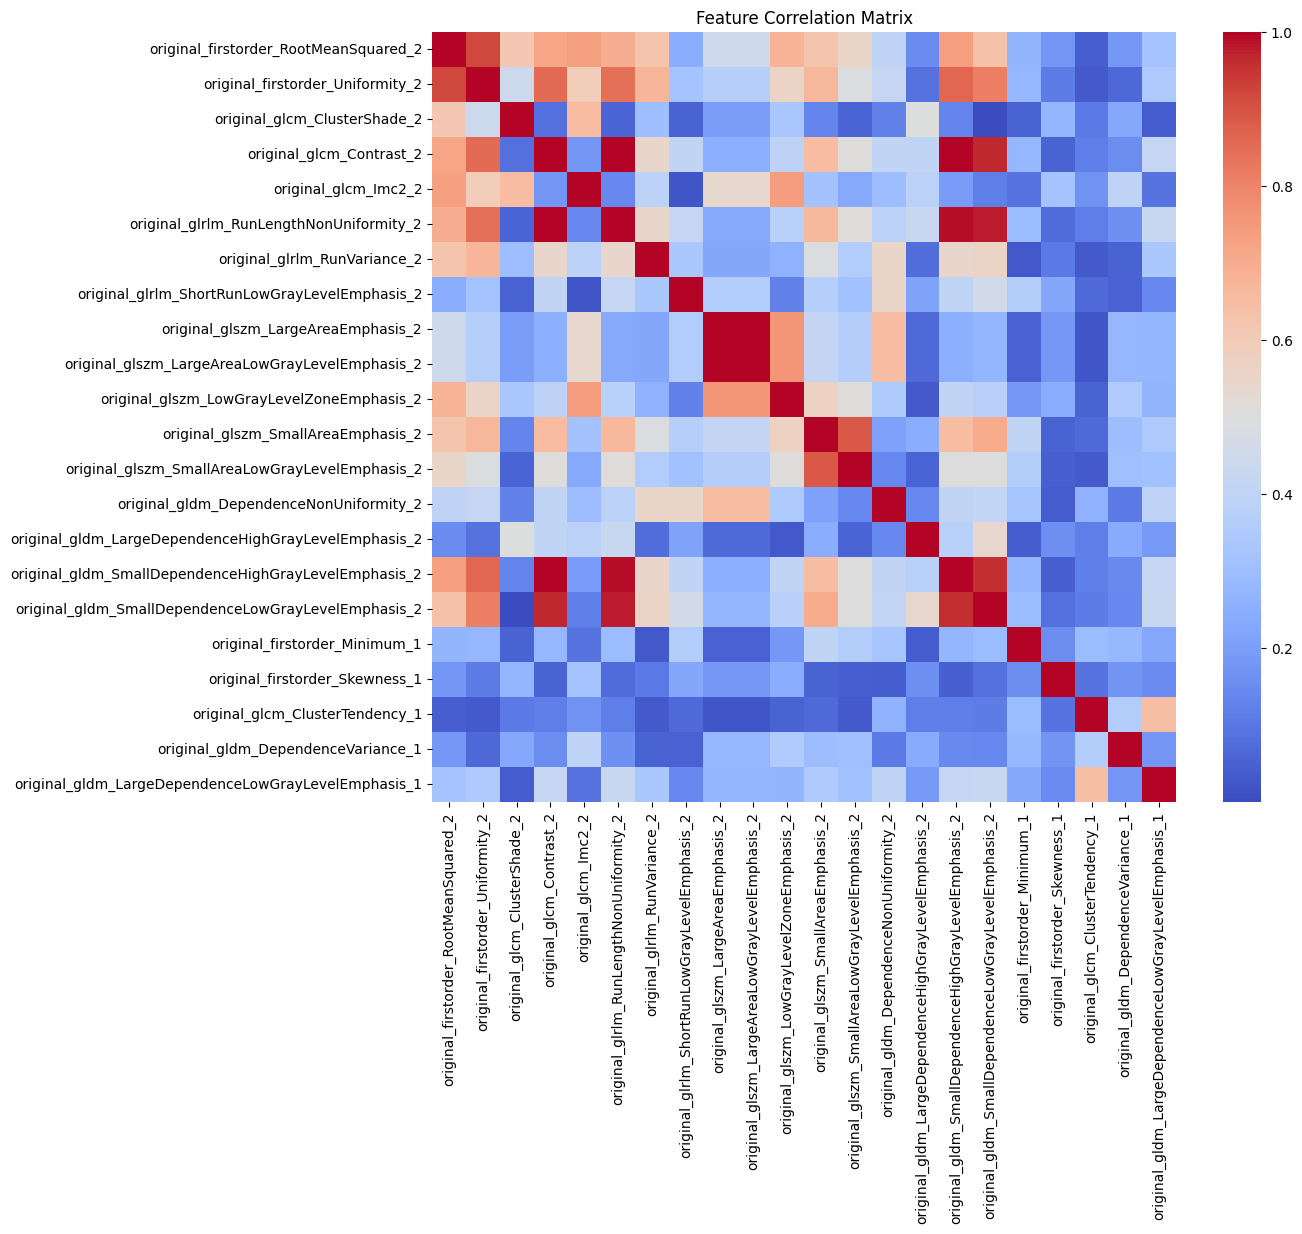

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt

# Mutual Information (how much each feature knows about the label)
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': selected_features, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print(mi_df.head(10))

# Correlation matrix (features are often redundant)
corr = X.corr().abs()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

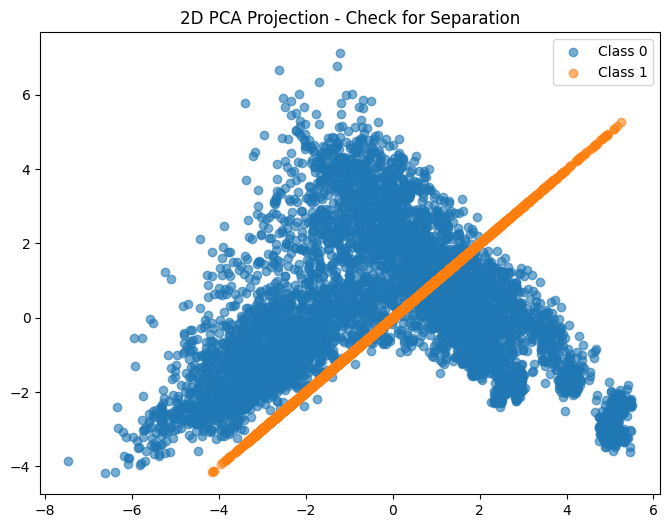

In [ ]:
# Simple linear separability test
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[y==0,0], X_pca[y==0,1], label='Class 0', alpha=0.6)
plt.scatter(X_pca[y==1,1], X_pca[y==1,1], label='Class 1', alpha=0.6)  # Fixed typo in original thought
plt.legend()
plt.title("2D PCA Projection - Check for Separation")
plt.show()

Patient_ID extraction sample:
         Filename Patient_ID
0    P175 (8).jpg       P175
1    P175 (9).jpg       P175
2    P176 (1).jpg       P176
3   P176 (10).jpg       P176
4  P176 (100).jpg       P176
5  P176 (101).jpg       P176
6  P176 (102).jpg       P176
7  P176 (103).jpg       P176
8  P176 (104).jpg       P176
9  P176 (105).jpg       P176

Total unique patients: 180
Total samples: 9435

All 22 selected features found!

Feature matrix shape: (9435, 22)
Target shape: (9435,)
Unique classes in target: [0 1]

Original class distribution:
labels
0    6491
1    2944
Name: count, dtype: int64

FOLD 1
Training set: 7822 samples from 144 patients
Validation set: 1613 samples from 36 patients

Training class distribution:
labels
0    5334
1    2488
Name: count, dtype: int64

Validation class distribution:
labels
0    1157
1     456
Name: count, dtype: int64

✓ No patient leakage - patients are properly separated!

──────────────────────────────────────────────────
APPROACH 1: Training WI

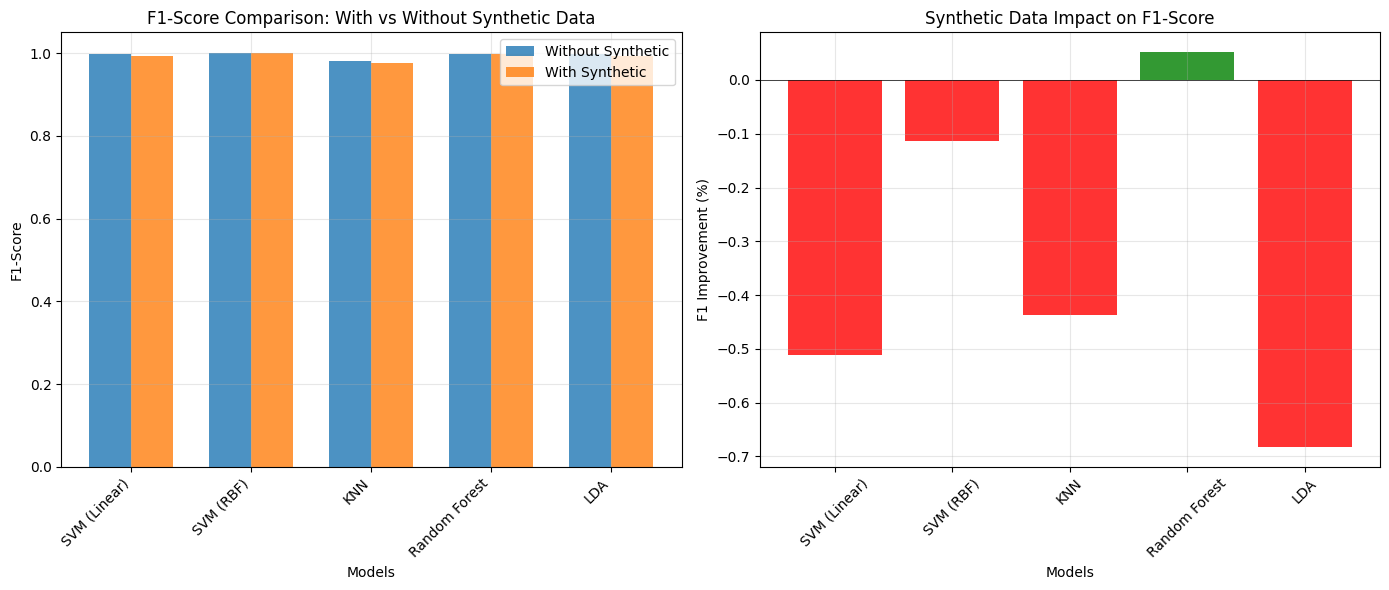

✓ Comparison plot saved as 'synthetic_comparison_plot.png'


In [ ]:
# Step 1: Define your selected features
selected_features = [
    'original_firstorder_RootMeanSquared_2',
    'original_firstorder_Uniformity_2',
    'original_glcm_ClusterShade_2',
    'original_glcm_Contrast_2',
    'original_glcm_Imc2_2',
    'original_glrlm_RunLengthNonUniformity_2',
    'original_glrlm_RunVariance_2',
    'original_glrlm_ShortRunLowGrayLevelEmphasis_2',
    'original_glszm_LargeAreaEmphasis_2',
    'original_glszm_LargeAreaLowGrayLevelEmphasis_2',
    'original_glszm_LowGrayLevelZoneEmphasis_2',
    'original_glszm_SmallAreaEmphasis_2',
    'original_glszm_SmallAreaLowGrayLevelEmphasis_2',
    'original_gldm_DependenceNonUniformity_2',
    'original_gldm_LargeDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceLowGrayLevelEmphasis_2',
    'original_firstorder_Minimum_1',
    'original_firstorder_Skewness_1',
    'original_glcm_ClusterTendency_1',
    'original_gldm_DependenceVariance_1',
    'original_gldm_LargeDependenceLowGrayLevelEmphasis_1'
]

# Step 2: Extract Patient_ID from Filename column
X_train_ful['Patient_ID'] = X_train_ful['Filename'].str.split(' ').str[0]

# Verify Patient_ID extraction
print("Patient_ID extraction sample:")
print(X_train_ful[['Filename', 'Patient_ID']].head(10))
print(f"\nTotal unique patients: {X_train_ful['Patient_ID'].nunique()}")
print(f"Total samples: {len(X_train_ful)}")

# Step 3: Define your columns
patient_col = 'Patient_ID'
target_col = 'labels'

# Step 4: Verify all selected features exist
missing_features = [f for f in selected_features if f not in X_train_ful.columns]
if missing_features:
    print(f"Warning: These features are missing: {missing_features}")
else:
    print(f"\nAll {len(selected_features)} selected features found!")

# Step 5: Prepare feature matrix X and target y
X = X_train_ful[selected_features]
y = X_train_ful[target_col]
groups = X_train_ful[patient_col]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Unique classes in target: {y.unique()}")
print(f"\nOriginal class distribution:")
print(y.value_counts())

# Step 6: Import necessary libraries
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
import pandas as pd

# Step 7: Perform StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize results storage for BOTH approaches
results_without_synthetic = {
    'fold': [], 'model': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []
}

results_with_synthetic = {
    'fold': [], 'model': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []
}

# Define models
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Step 8: Iterate through folds - Compare WITH vs WITHOUT synthetic data
for fold, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=groups)):
    # Split the data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # Get patient info for this fold
    train_patients = X_train_ful.iloc[train_idx][patient_col].unique()
    val_patients = X_train_ful.iloc[val_idx][patient_col].unique()

    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}")
    print(f"{'='*60}")
    print(f"Training set: {len(X_train_fold)} samples from {len(train_patients)} patients")
    print(f"Validation set: {len(X_val_fold)} samples from {len(val_patients)} patients")
    print(f"\nTraining class distribution:")
    print(y_train_fold.value_counts())
    print(f"\nValidation class distribution:")
    print(y_val_fold.value_counts())

    # Check for patient leakage
    overlapping_patients = set(train_patients) & set(val_patients)
    if overlapping_patients:
        print(f"WARNING: Patient leakage detected: {overlapping_patients}")
    else:
        print(f"\n✓ No patient leakage - patients are properly separated!")

    # ============================================================
    # APPROACH 1: Train WITHOUT synthetic data (original only)
    # ============================================================
    print(f"\n{'─'*50}")
    print("APPROACH 1: Training WITHOUT Synthetic Data (Original Only)")
    print(f"{'─'*50}")

    # Prepare original training data
    train_original = pd.concat([X_train_fold, y_train_fold], axis=1)
    X_original = train_original.drop('labels', axis=1)
    y_original = train_original['labels']

    print(f"Training set size: {len(X_original)} samples")
    print(f"Class distribution: {Counter(y_original)}")

    # Apply SMOTE to original data
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_original_balanced, y_original_balanced = smote.fit_resample(X_original, y_original)

    print(f"After SMOTE: {len(X_original_balanced)} samples")
    print(f"Balanced distribution: {Counter(y_original_balanced)}")

    # Train and evaluate models WITHOUT synthetic data
    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} (No Synthetic)...")

        # Train on original balanced data
        model.fit(X_original_balanced, y_original_balanced)

        # Predict on validation set
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_val_fold, y_pred)
        precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_val_fold, y_pred_proba)
        else:
            auc = roc_auc_score(y_val_fold, y_pred)

        # Store results
        results_without_synthetic['fold'].append(fold + 1)
        results_without_synthetic['model'].append(model_name)
        results_without_synthetic['accuracy'].append(accuracy)
        results_without_synthetic['precision'].append(precision)
        results_without_synthetic['recall'].append(recall)
        results_without_synthetic['f1'].append(f1)
        results_without_synthetic['auc'].append(auc)

        print(f"  ✓ Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f} | AUC: {auc:.4f}")

    # ============================================================
    # APPROACH 2: Train WITH synthetic data
    # ============================================================
    print(f"\n{'─'*50}")
    print("APPROACH 2: Training WITH Synthetic Data")
    print(f"{'─'*50}")

    # Load synthetic data for this fold
    synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold + 1}_synthetic_data.csv'

    try:
        GAN_df = pd.read_csv(synthetic_file)
        print(f"✓ Loaded synthetic data: {GAN_df.shape}")

        # Combine original and synthetic data
        combined_train = pd.concat([train_original, GAN_df], axis=0)
        X_combined = combined_train.drop('labels', axis=1)
        y_combined = combined_train['labels']

        print(f"Combined training set: {len(X_combined)} samples")
        print(f"  Original: {len(train_original)} | Synthetic: {len(GAN_df)}")
        print(f"Class distribution before SMOTE: {Counter(y_combined)}")

        # Apply SMOTE to combined data
        X_combined_balanced, y_combined_balanced = smote.fit_resample(X_combined, y_combined)

        print(f"After SMOTE: {len(X_combined_balanced)} samples")
        print(f"Balanced distribution: {Counter(y_combined_balanced)}")

        # Train and evaluate models WITH synthetic data
        for model_name, model in models.items():
            print(f"\n▶ Training {model_name} (With Synthetic)...")

            # Train on combined balanced data
            model.fit(X_combined_balanced, y_combined_balanced)

            # Predict on validation set
            y_pred = model.predict(X_val_fold)
            y_pred_proba = model.predict_proba(X_val_fold)[:, 1] if hasattr(model, 'predict_proba') else None

            # Calculate metrics
            accuracy = accuracy_score(y_val_fold, y_pred)
            precision = precision_score(y_val_fold, y_pred, average='binary', zero_division=0)
            recall = recall_score(y_val_fold, y_pred, average='binary', zero_division=0)
            f1 = f1_score(y_val_fold, y_pred, average='binary', zero_division=0)

            if y_pred_proba is not None:
                auc = roc_auc_score(y_val_fold, y_pred_proba)
            else:
                auc = roc_auc_score(y_val_fold, y_pred)

            # Store results
            results_with_synthetic['fold'].append(fold + 1)
            results_with_synthetic['model'].append(model_name)
            results_with_synthetic['accuracy'].append(accuracy)
            results_with_synthetic['precision'].append(precision)
            results_with_synthetic['recall'].append(recall)
            results_with_synthetic['f1'].append(f1)
            results_with_synthetic['auc'].append(auc)

            print(f"  ✓ Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
            print(f"  ✓ F1-Score: {f1:.4f} | AUC: {auc:.4f}")

    except FileNotFoundError:
        print(f"✗ ERROR: Synthetic data file not found: {synthetic_file}")
        print(f"  Skipping synthetic data comparison for this fold")
        continue

# Step 9: Create results summaries
results_without_df = pd.DataFrame(results_without_synthetic)
results_with_df = pd.DataFrame(results_with_synthetic)

# Calculate summary statistics
summary_without = results_without_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

summary_with = results_with_df.groupby('model').agg({
    'accuracy': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'auc': ['mean', 'std']
}).round(4)

# Print comparison results
print(f"\n{'='*80}")
print("COMPARISON RESULTS: WITH vs WITHOUT Synthetic Data")
print(f"{'='*80}")

# Create comparison table
comparison_df = pd.DataFrame()

for model_name in models.keys():
    # Get mean F1 scores
    f1_without = results_without_df[results_without_df['model'] == model_name]['f1'].mean()
    f1_with = results_with_df[results_with_df['model'] == model_name]['f1'].mean()

    # Get mean AUC scores
    auc_without = results_without_df[results_without_df['model'] == model_name]['auc'].mean()
    auc_with = results_with_df[results_with_df['model'] == model_name]['auc'].mean()

    # Calculate improvements
    f1_improvement = f1_with - f1_without
    f1_improvement_pct = (f1_improvement / f1_without) * 100 if f1_without > 0 else 0

    auc_improvement = auc_with - auc_without
    auc_improvement_pct = (auc_improvement / auc_without) * 100 if auc_without > 0 else 0

    comparison_df.loc[model_name, 'Without_Synthetic_F1'] = f1_without
    comparison_df.loc[model_name, 'With_Synthetic_F1'] = f1_with
    comparison_df.loc[model_name, 'F1_Improvement'] = f1_improvement
    comparison_df.loc[model_name, 'F1_Improvement_%'] = f1_improvement_pct
    comparison_df.loc[model_name, 'Without_Synthetic_AUC'] = auc_without
    comparison_df.loc[model_name, 'With_Synthetic_AUC'] = auc_with
    comparison_df.loc[model_name, 'AUC_Improvement'] = auc_improvement
    comparison_df.loc[model_name, 'AUC_Improvement_%'] = auc_improvement_pct

    # Determine if synthetic data helped
    if f1_improvement > 0.05:
        comparison_df.loc[model_name, 'Synthetic_Effect'] = '✅ SIGNIFICANT IMPROVEMENT'
    elif f1_improvement > 0:
        comparison_df.loc[model_name, 'Synthetic_Effect'] = '✓ Minor Improvement'
    elif f1_improvement > -0.02:
        comparison_df.loc[model_name, 'Synthetic_Effect'] = '○ Neutral Effect'
    else:
        comparison_df.loc[model_name, 'Synthetic_Effect'] = '❌ DEGRADATION'

print("\n📊 F1-Score Comparison:")
print(comparison_df[['Without_Synthetic_F1', 'With_Synthetic_F1', 'F1_Improvement_%', 'Synthetic_Effect']].round(4))

print("\n📈 AUC Comparison:")
print(comparison_df[['Without_Synthetic_AUC', 'With_Synthetic_AUC', 'AUC_Improvement_%']].round(4))

# Step 10: Detailed per-fold analysis
print(f"\n{'='*80}")
print("DETAILED PER-FOLD ANALYSIS")
print(f"{'='*80}")

for model_name in models.keys():
    print(f"\n📊 {model_name}:")

    # Get per-fold results for this model
    model_without = results_without_df[results_without_df['model'] == model_name]
    model_with = results_with_df[results_with_df['model'] == model_name]

    if len(model_with) > 0:
        for fold in range(1, 6):
            f1_without = model_without[model_without['fold'] == fold]['f1'].values[0] if len(model_without[model_without['fold'] == fold]) > 0 else np.nan
            f1_with = model_with[model_with['fold'] == fold]['f1'].values[0] if len(model_with[model_with['fold'] == fold]) > 0 else np.nan

            if not np.isnan(f1_without) and not np.isnan(f1_with):
                improvement = f1_with - f1_without
                arrow = "↑" if improvement > 0 else "↓" if improvement < 0 else "→"
                print(f"  Fold {fold}: Without={f1_without:.4f} | With={f1_with:.4f} | {arrow} {abs(improvement):.4f}")

# Step 11: Best model identification
print(f"\n{'='*80}")
print("BEST MODEL ANALYSIS")
print(f"{'='*80}")

best_without_model = results_without_df.groupby('model')['f1'].mean().idxmax()
best_without_f1 = results_without_df.groupby('model')['f1'].mean().max()

best_with_model = results_with_df.groupby('model')['f1'].mean().idxmax()
best_with_f1 = results_with_df.groupby('model')['f1'].mean().max()

print(f"\n🏆 WITHOUT Synthetic Data:")
print(f"   Best Model: {best_without_model} (F1-Score: {best_without_f1:.4f})")

print(f"\n🏆 WITH Synthetic Data:")
print(f"   Best Model: {best_with_model} (F1-Score: {best_with_f1:.4f})")

# Determine if synthetic data improved the best model
if best_with_model == best_without_model:
    improvement = best_with_f1 - best_without_f1
    if improvement > 0:
        print(f"\n✅ Synthetic data IMPROVED the best model ({best_with_model}) by {improvement:.4f} ({improvement/best_without_f1*100:.2f}%)")
    else:
        print(f"\n❌ Synthetic data DEGRADED the best model ({best_with_model}) by {abs(improvement):.4f}")
else:
    print(f"\n🔄 Synthetic data changed the best model from {best_without_model} to {best_with_model}")

# Step 12: Save all results
results_without_df.to_csv('cv_results_without_synthetic.csv', index=False)
results_with_df.to_csv('cv_results_with_synthetic.csv', index=False)
comparison_df.to_csv('cv_synthetic_comparison.csv', index=False)

# Save summaries
summary_without.to_csv('summary_without_synthetic.csv')
summary_with.to_csv('summary_with_synthetic.csv')

print(f"\n{'='*80}")
print("RESULTS SAVED")
print(f"{'='*80}")
print("✓ cv_results_without_synthetic.csv - Detailed fold results without synthetic data")
print("✓ cv_results_with_synthetic.csv - Detailed fold results with synthetic data")
print("✓ cv_synthetic_comparison.csv - Direct comparison table")
print("✓ summary_without_synthetic.csv - Summary statistics without synthetic data")
print("✓ summary_with_synthetic.csv - Summary statistics with synthetic data")

# Step 13: Visual comparison (optional - if you have matplotlib)
try:
    import matplotlib.pyplot as plt

    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # F1 Score comparison
    models_list = list(models.keys())
    f1_without_values = [comparison_df.loc[m, 'Without_Synthetic_F1'] for m in models_list]
    f1_with_values = [comparison_df.loc[m, 'With_Synthetic_F1'] for m in models_list]

    x = np.arange(len(models_list))
    width = 0.35

    axes[0].bar(x - width/2, f1_without_values, width, label='Without Synthetic', alpha=0.8)
    axes[0].bar(x + width/2, f1_with_values, width, label='With Synthetic', alpha=0.8)
    axes[0].set_xlabel('Models')
    axes[0].set_ylabel('F1-Score')
    axes[0].set_title('F1-Score Comparison: With vs Without Synthetic Data')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models_list, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Improvement plot
    improvements = [comparison_df.loc[m, 'F1_Improvement_%'] for m in models_list]
    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    axes[1].bar(models_list, improvements, color=colors, alpha=0.8)
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1].set_xlabel('Models')
    axes[1].set_ylabel('F1 Improvement (%)')
    axes[1].set_title('Synthetic Data Impact on F1-Score')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('synthetic_comparison_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Comparison plot saved as 'synthetic_comparison_plot.png'")

except ImportError:
    print("\n⚠️ matplotlib not available - skipping plot generation")

In [ ]:
# holdout test set# Step 8: Train final models on full training data (original + synthetic) and evaluate on
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np

# Load test data
X_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_test.csv')

selected_features = [
    'original_firstorder_RootMeanSquared_2',
    'original_firstorder_Uniformity_2',
    'original_glcm_ClusterShade_2',
    'original_glcm_Contrast_2',
    'original_glcm_Imc2_2',
    'original_glrlm_RunLengthNonUniformity_2',
    'original_glrlm_RunVariance_2',
    'original_glrlm_ShortRunLowGrayLevelEmphasis_2',
    'original_glszm_LargeAreaEmphasis_2',
    'original_glszm_LargeAreaLowGrayLevelEmphasis_2',
    'original_glszm_LowGrayLevelZoneEmphasis_2',
    'original_glszm_SmallAreaEmphasis_2',
    'original_glszm_SmallAreaLowGrayLevelEmphasis_2',
    'original_gldm_DependenceNonUniformity_2',
    'original_gldm_LargeDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceLowGrayLevelEmphasis_2',
    'original_firstorder_Minimum_1',
    'original_firstorder_Skewness_1',
    'original_glcm_ClusterTendency_1',
    'original_gldm_DependenceVariance_1',
    'original_gldm_LargeDependenceLowGrayLevelEmphasis_1'
]
X_test= X_test[selected_features]


# Ensure y_test is 1D series
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0] if y_test.shape[1] > 0 else y_test.squeeze()

print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nTest class distribution:")
print(y_test.value_counts())

# Option 1: Train on FULL original + ALL synthetic data from all folds
print(f"\n{'='*60}")
print("OPTION 1: Training on ALL original + ALL synthetic data")
print(f"{'='*60}")

# Load ALL original training data (original data before CV splitting)
# Assuming you have your full training data from earlier
# If not, we'll need to load it from your saved files

# Load full original training data (adjust path as needed)
# X_train_full = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_train.csv')
# y_train_full = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_train.csv')

# Alternative: Combine original data from all folds
# For now, let's assume you have X_full and y_full from your original dataset
# If you have the original X and y variables from before splitting, use those

print("\n⚠️ Note: Make sure to load your full original training data")
print("For now, assuming X and y from earlier contain your full training data\n")

# Load all synthetic data from all folds
all_synthetic_dfs = []
for fold in range(1, 6):  # Adjust number of folds as needed
    synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold}_synthetic_data.csv'
    try:
        synthetic_df = pd.read_csv(synthetic_file)
        all_synthetic_dfs.append(synthetic_df)
        print(f"✓ Loaded fold {fold} synthetic data: {synthetic_df.shape}")
    except FileNotFoundError:
        print(f"✗ Could not find: {synthetic_file}")

# Combine all synthetic data
if all_synthetic_dfs:
    combined_synthetic = pd.concat(all_synthetic_dfs, axis=0, ignore_index=True)
    print(f"\nTotal synthetic data: {combined_synthetic.shape}")

    # Remove duplicates if any
    combined_synthetic = combined_synthetic.drop_duplicates()
    print(f"After removing duplicates: {combined_synthetic.shape}")
else:
    print("No synthetic data found!")
    combined_synthetic = None

# Define models (use same hyperparameters as before)
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# Option 1A: Train on original data only (baseline)
print(f"\n{'='*60}")
print("BASELINE: Training on Original Data Only")
print(f"{'='*60}")

baseline_results = {}

for model_name, model in models.items():
    print(f"\n▶ Training {model_name} on original data...")

    # Train on original data only
    model.fit(X, y)  # Using full original training data

    # Predict on test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = roc_auc_score(y_test, y_pred)

    baseline_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ AUC: {auc:.4f}")

# Option 1B: Train on original + synthetic data (augmented)
if combined_synthetic is not None:
    print(f"\n{'='*60}")
    print("AUGMENTED: Training on Original + Synthetic Data")
    print(f"{'='*60}")

    # Combine original and synthetic data
    original_data = pd.concat([X, y], axis=1)
    combined_train = pd.concat([original_data, combined_synthetic], axis=0, ignore_index=True)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    print(f"Combined training set: {X_combined.shape}")
    print(f"  Original: {len(original_data)} samples")
    print(f"  Synthetic: {len(combined_synthetic)} samples")

    augmented_results = {}

    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on augmented data...")

        # Train on original + synthetic data
        model.fit(X_combined, y_combined)

        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = roc_auc_score(y_test, y_pred)

        augmented_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        }

        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

# Compare results
print(f"\n{'='*60}")
print("FINAL COMPARISON: Original vs Augmented Training")
print(f"{'='*60}")

comparison_df = pd.DataFrame()

for model_name in models.keys():
    baseline = baseline_results[model_name]

    comparison_df.loc[model_name, 'Original_Accuracy'] = baseline['accuracy']
    comparison_df.loc[model_name, 'Original_F1'] = baseline['f1']
    comparison_df.loc[model_name, 'Original_AUC'] = baseline['auc']

    if combined_synthetic is not None:
        augmented = augmented_results[model_name]
        comparison_df.loc[model_name, 'Augmented_Accuracy'] = augmented['accuracy']
        comparison_df.loc[model_name, 'Augmented_F1'] = augmented['f1']
        comparison_df.loc[model_name, 'Augmented_AUC'] = augmented['auc']
        comparison_df.loc[model_name, 'Improvement_F1'] = augmented['f1'] - baseline['f1']
        comparison_df.loc[model_name, 'Improvement_%'] = (augmented['f1'] - baseline['f1']) / baseline['f1'] * 100

print("\nModel Performance on Holdout Test Set:")
print(comparison_df.round(4))

# Save results
comparison_df.to_csv('test_set_results_comparison.csv')
print(f"\n✓ Results saved to: test_set_results_comparison.csv")

# Find best performing model
if combined_synthetic is not None:
    best_model = comparison_df['Augmented_F1'].idxmax()
    best_f1 = comparison_df.loc[best_model, 'Augmented_F1']
    print(f"\n⭐ Best Model on Test Set (Augmented): {best_model} (F1-Score: {best_f1:.4f})")
else:
    best_model = comparison_df['Original_F1'].idxmax()
    best_f1 = comparison_df.loc[best_model, 'Original_F1']
    print(f"\n⭐ Best Model on Test Set (Original): {best_model} (F1-Score: {best_f1:.4f})")

Test set shape: (1709, 22)
Test labels shape: (1709,)

Test class distribution:
labels
0    1166
1     543
Name: count, dtype: int64

OPTION 1: Training on ALL original + ALL synthetic data

⚠️ Note: Make sure to load your full original training data
For now, assuming X and y from earlier contain your full training data

✓ Loaded fold 1 synthetic data: (1244, 34)
✓ Loaded fold 2 synthetic data: (1087, 31)
✓ Loaded fold 3 synthetic data: (1085, 37)
✓ Loaded fold 4 synthetic data: (1205, 34)
✓ Loaded fold 5 synthetic data: (1266, 34)

Total synthetic data: (5887, 42)
After removing duplicates: (5887, 42)

BASELINE: Training on Original Data Only

▶ Training SVM (Linear) on original data...


In [ ]:
# Step 8: Train final models on full training data (original + synthetic) with SMOTE balancing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np

# Load test data
X_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_test.csv')

selected_features = [
    'original_firstorder_RootMeanSquared_2',
    'original_firstorder_Uniformity_2',
    'original_glcm_ClusterShade_2',
    'original_glcm_Contrast_2',
    'original_glcm_Imc2_2',
    'original_glrlm_RunLengthNonUniformity_2',
    'original_glrlm_RunVariance_2',
    'original_glrlm_ShortRunLowGrayLevelEmphasis_2',
    'original_glszm_LargeAreaEmphasis_2',
    'original_glszm_LargeAreaLowGrayLevelEmphasis_2',
    'original_glszm_LowGrayLevelZoneEmphasis_2',
    'original_glszm_SmallAreaEmphasis_2',
    'original_glszm_SmallAreaLowGrayLevelEmphasis_2',
    'original_gldm_DependenceNonUniformity_2',
    'original_gldm_LargeDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceLowGrayLevelEmphasis_2',
    'original_firstorder_Minimum_1',
    'original_firstorder_Skewness_1',
    'original_glcm_ClusterTendency_1',
    'original_gldm_DependenceVariance_1',
    'original_gldm_LargeDependenceLowGrayLevelEmphasis_1'
]

# Filter test data to only selected features
X_test = X_test[selected_features]

# Ensure y_test is 1D series
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0] if y_test.shape[1] > 0 else y_test.squeeze()

print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nTest class distribution:")
print(y_test.value_counts())

# Load all synthetic data from all folds
print(f"\n{'='*60}")
print("Loading Synthetic Data from All Folds")
print(f"{'='*60}")

all_synthetic_dfs = []
for fold in range(1, 6):
    synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold}_synthetic_data.csv'
    try:
        synthetic_df = pd.read_csv(synthetic_file)
        all_synthetic_dfs.append(synthetic_df)
        print(f"✓ Loaded fold {fold} synthetic data: {synthetic_df.shape}")
    except FileNotFoundError:
        print(f"✗ Could not find: {synthetic_file}")

# Combine all synthetic data
if all_synthetic_dfs:
    combined_synthetic = pd.concat(all_synthetic_dfs, axis=0, ignore_index=True)
    print(f"\nTotal synthetic data: {combined_synthetic.shape}")
    combined_synthetic = combined_synthetic.drop_duplicates()
    print(f"After removing duplicates: {combined_synthetic.shape}")
else:
    print("No synthetic data found!")
    combined_synthetic = None

# Define models
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# ============================================================
# OPTION 1: Train on original data only (BASELINE - No SMOTE)
# ============================================================
print(f"\n{'='*60}")
print("BASELINE: Training on Original Data Only (No SMOTE)")
print(f"{'='*60}")

baseline_results = {}

for model_name, model in models.items():
    print(f"\n▶ Training {model_name} on original data...")

    # Train on original data only
    model.fit(X, y)

    # Predict on test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = roc_auc_score(y_test, y_pred)

    baseline_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ AUC: {auc:.4f}")

# ============================================================
# OPTION 2: Train on original + synthetic (No SMOTE)
# ============================================================
if combined_synthetic is not None:
    print(f"\n{'='*60}")
    print("AUGMENTED: Original + Synthetic Data (No SMOTE)")
    print(f"{'='*60}")

    # Combine original and synthetic data
    original_data = pd.concat([X, y], axis=1)
    combined_train = pd.concat([original_data, combined_synthetic], axis=0, ignore_index=True)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    print(f"Combined training set: {X_combined.shape}")
    print(f"  Original: {len(original_data)} samples")
    print(f"  Synthetic: {len(combined_synthetic)} samples")
    print(f"\nClass distribution before SMOTE: {Counter(y_combined)}")

    augmented_results = {}

    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on augmented data (no SMOTE)...")

        # Train on original + synthetic data
        model.fit(X_combined, y_combined)

        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = roc_auc_score(y_test, y_pred)

        augmented_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        }

        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

# ============================================================
# OPTION 3: Train on original + synthetic WITH SMOTE BALANCING
# ============================================================
if combined_synthetic is not None:
    print(f"\n{'='*60}")
    print("SMOTE-BALANCED: Original + Synthetic Data with SMOTE")
    print(f"{'='*60}")

    # Apply SMOTE to balance the training data
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_smote_balanced, y_smote_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\n✓ SMOTE applied successfully!")
    print(f"Class distribution after SMOTE: {Counter(y_smote_balanced)}")
    print(f"Training set size after SMOTE: {len(X_smote_balanced)} samples")
    print(f"  Original + Synthetic (before SMOTE): {len(X_combined)}")
    print(f"  After SMOTE: {len(X_smote_balanced)}")
    print(f"  Added samples: {len(X_smote_balanced) - len(X_combined)}")

    smote_results = {}

    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on SMOTE-balanced data...")

        # Train on SMOTE-balanced data
        model.fit(X_smote_balanced, y_smote_balanced)

        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = roc_auc_score(y_test, y_pred)

        smote_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        }

        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

# ============================================================
# COMPARE ALL THREE APPROACHES
# ============================================================
print(f"\n{'='*60}")
print("FINAL COMPARISON: All Training Approaches")
print(f"{'='*60}")

comparison_df = pd.DataFrame()

for model_name in models.keys():
    baseline = baseline_results[model_name]

    comparison_df.loc[model_name, 'Original_Only_F1'] = baseline['f1']
    comparison_df.loc[model_name, 'Original_Only_AUC'] = baseline['auc']

    if combined_synthetic is not None:
        augmented = augmented_results[model_name]
        smote = smote_results[model_name]

        comparison_df.loc[model_name, 'Augmented_No_SMOTE_F1'] = augmented['f1']
        comparison_df.loc[model_name, 'Augmented_No_SMOTE_AUC'] = augmented['auc']
        comparison_df.loc[model_name, 'SMOTE_Balanced_F1'] = smote['f1']
        comparison_df.loc[model_name, 'SMOTE_Balanced_AUC'] = smote['auc']

        # Calculate improvements
        comparison_df.loc[model_name, 'SMOTE_vs_Augmented_Improvement'] = smote['f1'] - augmented['f1']
        comparison_df.loc[model_name, 'SMOTE_vs_Original_Improvement'] = smote['f1'] - baseline['f1']
        comparison_df.loc[model_name, 'SMOTE_Improvement_%'] = (smote['f1'] - baseline['f1']) / baseline['f1'] * 100

print("\nModel Performance on Holdout Test Set:")
print(comparison_df.round(4))

# ============================================================
# FIND BEST MODEL
# ============================================================
if combined_synthetic is not None:
    # Find best model with SMOTE
    best_model_smote = comparison_df['SMOTE_Balanced_F1'].idxmax()
    best_f1_smote = comparison_df.loc[best_model_smote, 'SMOTE_Balanced_F1']

    # Find best model without SMOTE
    best_model_augmented = comparison_df['Augmented_No_SMOTE_F1'].idxmax()
    best_f1_augmented = comparison_df.loc[best_model_augmented, 'Augmented_No_SMOTE_F1']

    print(f"\n{'='*60}")
    print("BEST MODELS SUMMARY")
    print(f"{'='*60}")
    print(f"⭐ Best Model with SMOTE: {best_model_smote} (F1-Score: {best_f1_smote:.4f})")
    print(f"⭐ Best Model without SMOTE: {best_model_augmented} (F1-Score: {best_f1_augmented:.4f})")

    # Check if SMOTE improved the best model
    best_model_original = comparison_df['Original_Only_F1'].idxmax()
    best_f1_original = comparison_df.loc[best_model_original, 'Original_Only_F1']

    print(f"⭐ Best Model (Original only): {best_model_original} (F1-Score: {best_f1_original:.4f})")

    # Determine overall best
    all_f1_scores = {
        'Original Only': best_f1_original,
        'Augmented (No SMOTE)': best_f1_augmented,
        'SMOTE Balanced': best_f1_smote
    }
    best_approach = max(all_f1_scores, key=all_f1_scores.get)
    print(f"\n🏆 OVERALL BEST: {best_approach} approach with F1-Score: {all_f1_scores[best_approach]:.4f}")

else:
    best_model = comparison_df['Original_Only_F1'].idxmax()
    best_f1 = comparison_df.loc[best_model, 'Original_Only_F1']
    print(f"\n⭐ Best Model on Test Set (Original): {best_model} (F1-Score: {best_f1:.4f})")

# ============================================================
# SAVE RESULTS
# ============================================================
comparison_df.to_csv('test_set_results_with_smote_comparison.csv')
print(f"\n✓ Results saved to: test_set_results_with_smote_comparison.csv")

# ============================================================
# DETAILED METRICS TABLE
# ============================================================
print(f"\n{'='*60}")
print("DETAILED METRICS FOR SMOTE-BALANCED MODELS")
print(f"{'='=60}")

if combined_synthetic is not None:
    detailed_metrics = pd.DataFrame(smote_results).T
    detailed_metrics = detailed_metrics.round(4)
    print(detailed_metrics)

    # Save detailed metrics
    detailed_metrics.to_csv('smote_balanced_model_metrics.csv')
    print(f"\n✓ Detailed metrics saved to: smote_balanced_model_metrics.csv")

SyntaxError: f-string: expecting '!', or ':', or '}' (1828523016.py, line 324)

In [ ]:
# Step 8: Train final models on full training data (original + synthetic) with SMOTE balancing
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd
import numpy as np

# Load test data
X_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_test.csv')

selected_features = [
    'original_firstorder_RootMeanSquared_2',
    'original_firstorder_Uniformity_2',
    'original_glcm_ClusterShade_2',
    'original_glcm_Contrast_2',
    'original_glcm_Imc2_2',
    'original_glrlm_RunLengthNonUniformity_2',
    'original_glrlm_RunVariance_2',
    'original_glrlm_ShortRunLowGrayLevelEmphasis_2',
    'original_glszm_LargeAreaEmphasis_2',
    'original_glszm_LargeAreaLowGrayLevelEmphasis_2',
    'original_glszm_LowGrayLevelZoneEmphasis_2',
    'original_glszm_SmallAreaEmphasis_2',
    'original_glszm_SmallAreaLowGrayLevelEmphasis_2',
    'original_gldm_DependenceNonUniformity_2',
    'original_gldm_LargeDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceHighGrayLevelEmphasis_2',
    'original_gldm_SmallDependenceLowGrayLevelEmphasis_2',
    'original_firstorder_Minimum_1',
    'original_firstorder_Skewness_1',
    'original_glcm_ClusterTendency_1',
    'original_gldm_DependenceVariance_1',
    'original_gldm_LargeDependenceLowGrayLevelEmphasis_1'
]

# Filter test data to only selected features
X_test = X_test[selected_features]

# Ensure y_test is 1D series
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0] if y_test.shape[1] > 0 else y_test.squeeze()

print(f"Test set shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nTest class distribution:")
print(y_test.value_counts())

# Load all synthetic data from all folds
print(f"\n{'='*60}")
print("Loading Synthetic Data from All Folds")
print(f"{'='*60}")

all_synthetic_dfs = []
for fold in range(1, 6):
    synthetic_file = f'/content/drive/MyDrive/RadiomicGenAI/GAN/fold_{fold}_synthetic_data.csv'
    try:
        synthetic_df = pd.read_csv(synthetic_file)
        all_synthetic_dfs.append(synthetic_df)
        print(f"✓ Loaded fold {fold} synthetic data: {synthetic_df.shape}")
    except FileNotFoundError:
        print(f"✗ Could not find: {synthetic_file}")

# Combine all synthetic data
if all_synthetic_dfs:
    combined_synthetic = pd.concat(all_synthetic_dfs, axis=0, ignore_index=True)
    print(f"\nTotal synthetic data: {combined_synthetic.shape}")
    combined_synthetic = combined_synthetic.drop_duplicates()
    print(f"After removing duplicates: {combined_synthetic.shape}")
else:
    print("No synthetic data found!")
    combined_synthetic = None

# Define models
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42, probability=True),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42, probability=True),
    'KNN': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'LDA': LinearDiscriminantAnalysis()
}

# ============================================================
# OPTION 1: Train on original data only (BASELINE - No SMOTE)
# ============================================================
print(f"\n{'='*60}")
print("BASELINE: Training on Original Data Only (No SMOTE)")
print(f"{'='*60}")

baseline_results = {}

for model_name, model in models.items():
    print(f"\n▶ Training {model_name} on original data...")

    # Train on original data only
    model.fit(X, y)

    # Predict on test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

    if y_pred_proba is not None:
        auc = roc_auc_score(y_test, y_pred_proba)
    else:
        auc = roc_auc_score(y_test, y_pred)

    baseline_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc
    }

    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ AUC: {auc:.4f}")

# ============================================================
# OPTION 2: Train on original + synthetic (No SMOTE)
# ============================================================
if combined_synthetic is not None:
    print(f"\n{'='*60}")
    print("AUGMENTED: Original + Synthetic Data (No SMOTE)")
    print(f"{'='*60}")

    # Combine original and synthetic data
    original_data = pd.concat([X, y], axis=1)
    combined_train = pd.concat([original_data, combined_synthetic], axis=0, ignore_index=True)
    X_combined = combined_train.drop('labels', axis=1)
    y_combined = combined_train['labels']

    print(f"Combined training set: {X_combined.shape}")
    print(f"  Original: {len(original_data)} samples")
    print(f"  Synthetic: {len(combined_synthetic)} samples")
    print(f"\nClass distribution before SMOTE: {Counter(y_combined)}")

    augmented_results = {}

    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on augmented data (no SMOTE)...")

        # Train on original + synthetic data
        model.fit(X_combined, y_combined)

        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = roc_auc_score(y_test, y_pred)

        augmented_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        }

        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

# ============================================================
# OPTION 3: Train on original + synthetic WITH SMOTE BALANCING
# ============================================================
if combined_synthetic is not None:
    print(f"\n{'='*60}")
    print("SMOTE-BALANCED: Original + Synthetic Data with SMOTE")
    print(f"{'='*60}")

    # Apply SMOTE to balance the training data
    smote = SMOTE(random_state=42, sampling_strategy='auto')
    X_smote_balanced, y_smote_balanced = smote.fit_resample(X_combined, y_combined)

    print(f"\n✓ SMOTE applied successfully!")
    print(f"Class distribution after SMOTE: {Counter(y_smote_balanced)}")
    print(f"Training set size after SMOTE: {len(X_smote_balanced)} samples")
    print(f"  Original + Synthetic (before SMOTE): {len(X_combined)}")
    print(f"  After SMOTE: {len(X_smote_balanced)}")
    print(f"  Added samples: {len(X_smote_balanced) - len(X_combined)}")

    smote_results = {}

    for model_name, model in models.items():
        print(f"\n▶ Training {model_name} on SMOTE-balanced data...")

        # Train on SMOTE-balanced data
        model.fit(X_smote_balanced, y_smote_balanced)

        # Predict on test set
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='binary', zero_division=0)
        recall = recall_score(y_test, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)

        if y_pred_proba is not None:
            auc = roc_auc_score(y_test, y_pred_proba)
        else:
            auc = roc_auc_score(y_test, y_pred)

        smote_results[model_name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        }

        print(f"  ✓ Accuracy: {accuracy:.4f}")
        print(f"  ✓ Precision: {precision:.4f}")
        print(f"  ✓ Recall: {recall:.4f}")
        print(f"  ✓ F1-Score: {f1:.4f}")
        print(f"  ✓ AUC: {auc:.4f}")

# ============================================================
# COMPARE ALL THREE APPROACHES
# ============================================================
print(f"\n{'='*60}")
print("FINAL COMPARISON: All Training Approaches")
print(f"{'='*60}")

comparison_df = pd.DataFrame()

for model_name in models.keys():
    baseline = baseline_results[model_name]

    comparison_df.loc[model_name, 'Original_Only_F1'] = baseline['f1']
    comparison_df.loc[model_name, 'Original_Only_AUC'] = baseline['auc']

    if combined_synthetic is not None:
        augmented = augmented_results[model_name]
        smote = smote_results[model_name]

        comparison_df.loc[model_name, 'Augmented_No_SMOTE_F1'] = augmented['f1']
        comparison_df.loc[model_name, 'Augmented_No_SMOTE_AUC'] = augmented['auc']
        comparison_df.loc[model_name, 'SMOTE_Balanced_F1'] = smote['f1']
        comparison_df.loc[model_name, 'SMOTE_Balanced_AUC'] = smote['auc']

        # Calculate improvements
        comparison_df.loc[model_name, 'SMOTE_vs_Augmented_Improvement'] = smote['f1'] - augmented['f1']
        comparison_df.loc[model_name, 'SMOTE_vs_Original_Improvement'] = smote['f1'] - baseline['f1']
        comparison_df.loc[model_name, 'SMOTE_Improvement_%'] = (smote['f1'] - baseline['f1']) / baseline['f1'] * 100

print("\nModel Performance on Holdout Test Set:")
print(comparison_df.round(4))

# ============================================================
# FIND BEST MODEL
# ============================================================
if combined_synthetic is not None:
    # Find best model with SMOTE
    best_model_smote = comparison_df['SMOTE_Balanced_F1'].idxmax()
    best_f1_smote = comparison_df.loc[best_model_smote, 'SMOTE_Balanced_F1']

    # Find best model without SMOTE
    best_model_augmented = comparison_df['Augmented_No_SMOTE_F1'].idxmax()
    best_f1_augmented = comparison_df.loc[best_model_augmented, 'Augmented_No_SMOTE_F1']

    print(f"\n{'='*60}")
    print("BEST MODELS SUMMARY")
    print(f"{'='*60}")
    print(f"⭐ Best Model with SMOTE: {best_model_smote} (F1-Score: {best_f1_smote:.4f})")
    print(f"⭐ Best Model without SMOTE: {best_model_augmented} (F1-Score: {best_f1_augmented:.4f})")

    # Check if SMOTE improved the best model
    best_model_original = comparison_df['Original_Only_F1'].idxmax()
    best_f1_original = comparison_df.loc[best_model_original, 'Original_Only_F1']

    print(f"⭐ Best Model (Original only): {best_model_original} (F1-Score: {best_f1_original:.4f})")

    # Determine overall best
    all_f1_scores = {
        'Original Only': best_f1_original,
        'Augmented (No SMOTE)': best_f1_augmented,
        'SMOTE Balanced': best_f1_smote
    }
    best_approach = max(all_f1_scores, key=all_f1_scores.get)
    print(f"\n🏆 OVERALL BEST: {best_approach} approach with F1-Score: {all_f1_scores[best_approach]:.4f}")

else:
    best_model = comparison_df['Original_Only_F1'].idxmax()
    best_f1 = comparison_df.loc[best_model, 'Original_Only_F1']
    print(f"\n⭐ Best Model on Test Set (Original): {best_model} (F1-Score: {best_f1:.4f})")

# ============================================================
# SAVE RESULTS
# ============================================================
comparison_df.to_csv('test_set_results_with_smote_comparison.csv')
print(f"\n✓ Results saved to: test_set_results_with_smote_comparison.csv")

# ============================================================
# DETAILED METRICS TABLE
# ============================================================
print(f"\n{'='*60}")
print("DETAILED METRICS FOR SMOTE-BALANCED MODELS")
print(f"{'='*60}")

if combined_synthetic is not None:
    detailed_metrics = pd.DataFrame(smote_results).T
    detailed_metrics = detailed_metrics.round(4)
    print(detailed_metrics)

    # Save detailed metrics
    detailed_metrics.to_csv('smote_balanced_model_metrics.csv')
    print(f"\n✓ Detailed metrics saved to: smote_balanced_model_metrics.csv")

Test set shape: (1709, 22)
Test labels shape: (1709,)

Test class distribution:
labels
0    1166
1     543
Name: count, dtype: int64

Loading Synthetic Data from All Folds
✓ Loaded fold 1 synthetic data: (3911, 23)
✓ Loaded fold 2 synthetic data: (3723, 23)
✓ Loaded fold 3 synthetic data: (3775, 23)
✓ Loaded fold 4 synthetic data: (3752, 23)
✓ Loaded fold 5 synthetic data: (3707, 23)

Total synthetic data: (18868, 23)
After removing duplicates: (18868, 23)

BASELINE: Training on Original Data Only (No SMOTE)

▶ Training SVM (Linear) on original data...
  ✓ Accuracy: 0.9368
  ✓ Precision: 0.9020
  ✓ Recall: 0.8987
  ✓ F1-Score: 0.9004
  ✓ AUC: 0.9438

▶ Training KNN on original data...
  ✓ Accuracy: 0.8391
  ✓ Precision: 0.6872
  ✓ Recall: 0.9061
  ✓ F1-Score: 0.7816
  ✓ AUC: 0.9041

▶ Training Random Forest on original data...
  ✓ Accuracy: 0.7244
  ✓ Precision: 0.5355
  ✓ Recall: 1.0000
  ✓ F1-Score: 0.6975
  ✓ AUC: 0.9725

▶ Training LDA on original data...
  ✓ Accuracy: 0.9222
  ✓ P

In [ ]:
fold_1

,original_firstorder_RootMeanSquared_2,original_firstorder_Uniformity_2,original_glcm_ClusterShade_2,original_glcm_Contrast_2,original_glcm_Imc2_2,original_glrlm_RunLengthNonUniformity_2,original_glrlm_RunVariance_2,original_glrlm_ShortRunLowGrayLevelEmphasis_2,original_glszm_LargeAreaEmphasis_2,original_glszm_LargeAreaLowGrayLevelEmphasis_2,...,original_gldm_DependenceNonUniformity_2,original_gldm_LargeDependenceHighGrayLevelEmphasis_2,original_gldm_SmallDependenceHighGrayLevelEmphasis_2,original_gldm_SmallDependenceLowGrayLevelEmphasis_2,original_firstorder_Minimum_1,original_firstorder_Skewness_1,original_glcm_ClusterTendency_1,original_gldm_DependenceVariance_1,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,labels
0,0.115054,0.964685,0.002554,0.007813,0.751461,0.000412,0.159863,0.033598,0.000144,0.027576,...,0.014231,0.130696,0.002210,0.101611,0.742254,0.501318,0.193679,0.362951,0.322970,0
1,0.302182,0.917061,0.219240,0.059354,0.867938,0.001433,0.231217,0.223169,0.002381,0.007004,...,0.492241,0.170652,0.042231,0.101739,0.005175,0.715995,0.502400,0.832792,0.258754,0
2,0.160809,0.999192,-0.001493,-0.005994,0.248447,0.000053,0.291345,0.012264,0.045112,0.923706,...,0.948362,0.252111,-0.008983,0.022596,0.370503,0.844941,0.362465,0.539175,0.281782,1
3,0.893259,0.748860,0.091505,0.418887,0.362605,0.512306,-0.007976,0.517665,0.004469,0.001607,...,0.515042,0.368773,0.475837,0.309785,0.000317,0.782893,0.424666,0.338506,0.364368,1
4,0.044199,1.006910,-0.002549,-0.003045,0.461832,-0.003113,0.673375,0.981873,-0.000014,0.039488,...,0.582856,0.169538,0.010898,0.091252,0.048894,0.619431,0.438442,0.537900,0.501325,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3906,0.046427,0.988482,0.027456,0.005496,0.588726,0.003585,0.559492,-0.000594,0.024482,0.519378,...,0.481200,0.131449,-0.001956,0.043152,0.045582,0.231718,0.337581,0.598051,0.294127,1
3907,0.043318,0.992164,0.002637,0.008032,0.165130,0.007436,0.237571,0.102792,0.017936,0.032347,...,0.078833,0.481368,0.005866,0.115968,0.701123,0.669281,0.344998,0.402130,0.219024,1
3908,0.370236,0.694845,0.223109,0.191137,0.789739,0.220832,0.066020,0.475792,-0.002927,0.000398,...,0.120061,0.091105,0.030123,0.310877,0.002619,0.485120,0.307634,0.284288,0.180150,0
3909,-0.013469,0.989607,-0.001957,-0.004563,-0.019929,-0.001665,0.212010,0.019014,1.020654,0.075922,...,0.983106,0.334201,-0.001738,0.030835,0.034487,0.666940,0.388841,0.395064,0.249572,1


In [ ]:
# Load test data
X_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_test.csv')



In [ ]:
GAN_df['labels'].value_counts()


,count
labels,
0,939
1,835


In [ ]:
# 读数据 + 预处理  30 seconds to generate the  data
# X = features_df.iloc[:,:].values
# y = labels_df.values.squeeze()

X_1 = X[y == 1]

scaler = StandardScaler()
X_1_scaled = scaler.fit_transform(X_1)

X_tensor = torch.tensor(X_1_scaled, dtype=torch.float32)


# 定义 VAE 模型
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.fc_mu = nn.Linear(512, latent_dim)
        self.fc_logvar = nn.Linear(512, latent_dim)
        self.fc2 = nn.Linear(latent_dim, 512)
        self.fc3 = nn.Linear(512, input_dim)
        self.fc_res = nn.Linear(latent_dim, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h) + self.fc_res(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z


# 定义损失
def vae_loss(recon_x, x, mu, logvar, z, beta=0.1):
    recon = nn.functional.mse_loss(recon_x, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl


# 训练 VAE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = VAE(X_1.shape[1], latent_dim=10).to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-4)
loader = DataLoader(TensorDataset(X_tensor), batch_size=32, shuffle=True)

n_epochs = 200
losses = []

vae.train()
for epoch in range(n_epochs):
    beta = min(0.1, 0.1 * (epoch / 30))  # Linear ramp-up over 30 epochs
    epoch_loss = []
    for (x_batch,) in loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        recon, mu, logvar, z = vae(x_batch)
        loss = vae_loss(recon, x_batch, mu, logvar, z, beta)
        loss.backward()
        optimizer.step()
        epoch_loss.append(loss.item())
    avg = np.mean(epoch_loss)
    losses.append(avg)
    # Print only every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == n_epochs - 1:
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg:.6f}, Beta: {beta:.4f}')

# 生成1774个合成数据
vae.eval()
with torch.no_grad():
    z = torch.randn(1774, 10).to(device)
    synth = vae.decode(z).cpu().numpy()

synth = scaler.inverse_transform(synth)
synth = np.clip(synth, a_min=0, a_max=None)

vae_df = pd.DataFrame(synth, columns=features_df.columns[:])
vae_df.to_csv("/content/cross/vae_synthetic_1774.csv", index=False)

In [ ]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)# 6 mins

# Define parameters at the top
num_epochs = 200
timesteps = 1000

# 1. Data Preparation with enhanced scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(reference_data.values)

# Convert to PyTorch tensors with validation split
data_tensor = torch.tensor(scaled_data, dtype=torch.float32)
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# 2. Enhanced Diffusion Model with better architecture
class NumericalDiffusion(nn.Module):
    def __init__(self, input_dim, timesteps, hidden_dim=512):
        super().__init__()
        self.input_dim = input_dim
        self.timesteps = timesteps

        # Enhanced time embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # Network with residual connections
        self.net = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(-1) / self.timesteps  # Normalized time
        time_emb = self.time_mlp(t)
        return self.net(torch.cat([x, time_emb], dim=-1))

class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return x + self.block(x)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time * embeddings.unsqueeze(0)
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# 3. Diffusion Process with Cosine Schedule
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

betas = cosine_beta_schedule(timesteps)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

def forward_diffusion(x_0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_0)
    sqrt_alpha = sqrt_alphas_cumprod[t].reshape(-1, 1)
    sqrt_one_minus_alpha = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1)
    return sqrt_alpha * x_0 + sqrt_one_minus_alpha * noise, noise

# 4. Training Loop with Validation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NumericalDiffusion(input_dim=reference_data.shape[1], timesteps=timesteps).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

loss_history = {'train': [], 'val': []}

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for batch in dataloader:
        x_0 = batch[0].to(device)
        batch_size = x_0.shape[0]

        t = torch.randint(0, timesteps, (batch_size,), device=device)
        x_t, noise = forward_diffusion(x_0, t)

        optimizer.zero_grad()
        predicted_noise = model(x_t, t.float())
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history['train'].append(avg_loss)
    scheduler.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for batch in dataloader:
            x_0 = batch[0].to(device)
            t = torch.randint(0, timesteps, (x_0.shape[0],), device=device)
            x_t, noise = forward_diffusion(x_0, t)
            val_loss += F.mse_loss(model(x_t, t.float()), noise).item()
        loss_history['val'].append(val_loss / len(dataloader))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_loss:.4f}, Val Loss: {loss_history['val'][-1]:.4f}")

# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(loss_history['train'], label='Train Loss')
plt.plot(loss_history['val'], label='Validation Loss')
plt.title('Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# 5. Sampling Function
@torch.no_grad()
def sample(model, num_samples, input_dim, timesteps=1000):
    model.eval()
    x = torch.randn((num_samples, input_dim), device=device)

    for i in reversed(range(timesteps)):
        t = torch.full((num_samples,), i, dtype=torch.long, device=device)
        predicted_noise = model(x, t.float())

        alpha = alphas[t].reshape(-1, 1)
        alpha_cumprod = alphas_cumprod[t].reshape(-1, 1)
        beta = betas[t].reshape(-1, 1)

        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha)) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * predicted_noise
        ) + torch.sqrt(beta) * noise

    return x.cpu()

# Generate synthetic data
print("Generating synthetic data...")

num_synthetic_samples = 1774


synthetic_data = sample(model, num_synthetic_samples, reference_data.shape[1])

# Convert back to original scale
synthetic_df = pd.DataFrame(
    scaler.inverse_transform(synthetic_data.numpy()),
    columns=reference_data.columns
)

# Save results
synthetic_df.to_csv('/content/drive/MyDrive/Generative AI/diffusion/df_synthetic_1744.csv', index=False)

In [ ]:
!pip install tab-ddpm   # or clone the repo from yandex-research/tab-ddpm

ERROR: Could not find a version that satisfies the requirement tab-ddpm (from versions: none)
ERROR: No matching distribution found for tab-ddpm


In [ ]:
 train_df

,Filename,Full_Path,Folder,Category,Set,Patient_ID,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.582547,0.545455,0.396354,0.616884,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P175,0.645040,0.527273,0.434862,0.628177,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.649142,0.490909,0.466725,0.598950,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.689844,0.509091,0.456378,0.615469,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,P176,0.515126,0.363636,0.254387,0.446446,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.479219,0.513514,0.418945,0.405777,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.125624,0.135135,0.045599,0.030834,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.300642,0.324324,0.212113,0.210141,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,P100,0.255086,0.270270,0.138055,0.128048,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
ful_data_df=pd.concat([X_train_ful,X_test_ful],axis=0)

In [ ]:
# Save as CSV file
ful_data_df.to_csv('/content/drive/MyDrive/ful_data_df.csv', index=False)

print("File saved successfully to /content/drive/MyDrive/ful_data_df.csv")

File saved successfully to /content/drive/MyDrive/ful_data_df.csv


In [ ]:
ful_data_df

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.582547,0.545455,0.396354,0.616884,0.40,...,0.818368,0.025265,0.014643,0.070803,0.053259,1.270768e-01,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.645040,0.527273,0.434862,0.628177,0.55,...,0.801259,0.150401,0.144197,0.113444,0.159663,4.533057e-02,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.649142,0.490909,0.466725,0.598950,0.50,...,0.732614,0.139834,0.145134,0.102257,0.156583,4.500873e-02,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.689844,0.509091,0.456378,0.615469,0.55,...,0.657548,0.131487,0.146848,0.088266,0.139622,4.549148e-02,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.515126,0.363636,0.254387,0.446446,0.35,...,0.710785,0.122062,0.135625,0.092403,0.139296,4.822709e-02,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.073327,0.116279,0.024623,0.012458,0.10,...,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816,1
1705,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.064675,0.093023,0.020482,0.007747,0.10,...,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108,1
1706,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.080431,0.116279,0.028073,0.015377,0.10,...,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438,1
1707,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.089851,0.162791,0.044603,0.033063,0.15,...,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857,1


In [ ]:
X_train_ful

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.582547,0.545455,0.396354,0.616884,0.400000,...,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.645040,0.527273,0.434862,0.628177,0.550000,...,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.649142,0.490909,0.466725,0.598950,0.500000,...,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.689844,0.509091,0.456378,0.615469,0.550000,...,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.515126,0.363636,0.254387,0.446446,0.350000,...,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.479219,0.513514,0.418945,0.405777,0.500000,...,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714,1
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.125624,0.135135,0.045599,0.030834,0.111111,...,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270,1
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.300642,0.324324,0.212113,0.210141,0.333333,...,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932,1
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.255086,0.270270,0.138055,0.128048,0.277778,...,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290,1


In [ ]:
ful_data_df

In [ ]:
X_test_ful

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,P111 (55).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test,0.755419,0.742857,0.328281,0.719474,0.705882,...,0.282166,0.156319,0.337306,0.845606,0.035094,0.910987,8.630000e-06,0.860953,0.196355,0.000335
1,P111 (56).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test,0.944571,0.885714,0.446098,0.879273,0.823529,...,0.311853,0.159442,0.323738,0.817473,0.032639,0.810202,8.890000e-06,0.836485,0.203410,0.000352
2,P111 (57).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test,0.863989,0.800000,0.377980,0.792507,0.764706,...,0.259871,0.151897,0.352882,0.927471,0.035085,0.861046,8.130000e-06,0.920208,0.232400,0.000317
3,P111 (58).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test,0.928945,0.914286,0.454917,0.902293,0.882353,...,0.298058,0.169830,0.354851,0.881908,0.037470,1.000000,7.940000e-06,0.952587,0.217515,0.000314
4,P111 (59).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test,0.700874,0.628571,0.254369,0.586588,0.529412,...,0.231350,0.157895,0.326420,0.883110,0.031653,0.826711,8.590000e-06,0.862925,0.234978,0.000342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.073327,0.116279,0.024623,0.012458,0.100000,...,0.078283,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816
1705,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.064675,0.093023,0.020482,0.007747,0.100000,...,0.078564,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108
1706,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.080431,0.116279,0.028073,0.015377,0.100000,...,0.078101,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438
1707,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.089851,0.162791,0.044603,0.033063,0.150000,...,0.077030,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857


In [ ]:
X_train_ful

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LargeDependenceLowGrayLevelEmphasis_1,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.582547,0.545455,0.396354,0.616884,0.400000,...,0.830399,0.818368,0.025265,0.014643,0.070803,0.053259,0.127077,0.037945,0.062754,0.128997
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.645040,0.527273,0.434862,0.628177,0.550000,...,0.724026,0.801259,0.150401,0.144197,0.113444,0.159663,0.045331,0.119520,0.171853,0.048561
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.649142,0.490909,0.466725,0.598950,0.500000,...,0.650363,0.732614,0.139834,0.145134,0.102257,0.156583,0.045009,0.117673,0.163791,0.048140
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.689844,0.509091,0.456378,0.615469,0.550000,...,0.594166,0.657548,0.131487,0.146848,0.088266,0.139622,0.045491,0.113955,0.160928,0.049391
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.515126,0.363636,0.254387,0.446446,0.350000,...,0.633244,0.710785,0.122062,0.135625,0.092403,0.139296,0.048227,0.109215,0.161631,0.052086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,P100 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.479219,0.513514,0.418945,0.405777,0.500000,...,0.238112,0.770839,0.445710,0.282059,0.476742,0.676156,0.006067,0.318451,0.317569,0.007714
9431,P100 (130).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.125624,0.135135,0.045599,0.030834,0.111111,...,0.269532,0.478224,0.113763,0.070085,0.136278,0.218532,0.027308,0.117355,0.125390,0.028270
9432,P100 (131).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.300642,0.324324,0.212113,0.210141,0.333333,...,0.301243,0.665162,0.327752,0.243734,0.314027,0.565440,0.010572,0.230315,0.224883,0.011932
9433,P100 (132).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_train,M,train,0.255086,0.270270,0.138055,0.128048,0.277778,...,0.241782,0.621833,0.305659,0.227618,0.306739,0.469715,0.011216,0.229160,0.216103,0.012290


In [ ]:
ful_data_df

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.582547,0.545455,0.396354,0.616884,0.40,...,0.818368,0.025265,0.014643,0.070803,0.053259,1.270768e-01,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.645040,0.527273,0.434862,0.628177,0.55,...,0.801259,0.150401,0.144197,0.113444,0.159663,4.533057e-02,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.649142,0.490909,0.466725,0.598950,0.50,...,0.732614,0.139834,0.145134,0.102257,0.156583,4.500873e-02,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.689844,0.509091,0.456378,0.615469,0.55,...,0.657548,0.131487,0.146848,0.088266,0.139622,4.549148e-02,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.515126,0.363636,0.254387,0.446446,0.35,...,0.710785,0.122062,0.135625,0.092403,0.139296,4.822709e-02,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.073327,0.116279,0.024623,0.012458,0.10,...,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816,1
1705,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.064675,0.093023,0.020482,0.007747,0.10,...,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108,1
1706,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.080431,0.116279,0.028073,0.015377,0.10,...,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438,1
1707,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.089851,0.162791,0.044603,0.033063,0.15,...,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857,1


In [ ]:
merged_trainname.shape


(1709, 5)

In [ ]:
merged_testname

,Filename,Full_Path,Folder,Category,Set
0,P111 (55).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
1,P111 (56).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
2,P111 (57).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
3,P111 (58).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
4,P111 (59).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
...,...,...,...,...,...
1704,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test
1705,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test
1706,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test
1707,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test


In [ ]:
merged_testname

,Filename,Full_Path,Folder,Category,Set
0,P111 (55).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
1,P111 (56).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
2,P111 (57).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
3,P111 (58).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
4,P111 (59).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_test,B,test
...,...,...,...,...,...
1704,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test
1705,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test
1706,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test
1707,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test


In [ ]:
B_train_dfname

,Filename,Full_Path,Folder,Category,Set
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
...,...,...,...,...,...
6486,P030 (12).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
6487,P030 (13).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
6488,P030 (14).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train
6489,P030 (15).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train


In [ ]:
ful_data_df

,Filename,Full_Path,Folder,Category,Set,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.582547,0.545455,0.396354,0.616884,0.40,...,0.818368,0.025265,0.014643,0.070803,0.053259,1.270768e-01,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.645040,0.527273,0.434862,0.628177,0.55,...,0.801259,0.150401,0.144197,0.113444,0.159663,4.533057e-02,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.649142,0.490909,0.466725,0.598950,0.50,...,0.732614,0.139834,0.145134,0.102257,0.156583,4.500873e-02,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.689844,0.509091,0.456378,0.615469,0.55,...,0.657548,0.131487,0.146848,0.088266,0.139622,4.549148e-02,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,B_train,B,train,0.515126,0.363636,0.254387,0.446446,0.35,...,0.710785,0.122062,0.135625,0.092403,0.139296,4.822709e-02,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,P205 (70).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.073327,0.116279,0.024623,0.012458,0.10,...,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816,1
1705,P205 (71).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.064675,0.093023,0.020482,0.007747,0.10,...,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108,1
1706,P205 (72).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.080431,0.116279,0.028073,0.015377,0.10,...,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438,1
1707,P205 (8).jpg,/content/drive/MyDrive/Zenodo_dataset/Zenodo_d...,M_test,M,test,0.089851,0.162791,0.044603,0.033063,0.15,...,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857,1


In [ ]:
# Drop the columns
ful_data_df = ful_data_df.drop(columns=['Full_Path', 'Folder', 'Category', 'Set'])

# Verify the columns are gone
print(ful_data_df.columns.tolist())

['Filename', 'diagnostics_Image-original_Mean_2', 'original_firstorder_90Percentile_2', 'original_firstorder_Energy_2', 'original_firstorder_Entropy_2', 'original_firstorder_InterquartileRange_2', 'original_firstorder_Kurtosis_2', 'original_firstorder_Maximum_2', 'original_firstorder_MeanAbsoluteDeviation_2', 'original_firstorder_Mean_2', 'original_firstorder_Median_2', 'original_firstorder_Range_2', 'original_firstorder_RobustMeanAbsoluteDeviation_2', 'original_firstorder_RootMeanSquared_2', 'original_firstorder_Skewness_2', 'original_firstorder_TotalEnergy_2', 'original_firstorder_Uniformity_2', 'original_firstorder_Variance_2', 'original_glcm_Autocorrelation_2', 'original_glcm_JointAverage_2', 'original_glcm_ClusterProminence_2', 'original_glcm_ClusterShade_2', 'original_glcm_ClusterTendency_2', 'original_glcm_Contrast_2', 'original_glcm_Correlation_2', 'original_glcm_DifferenceAverage_2', 'original_glcm_DifferenceEntropy_2', 'original_glcm_DifferenceVariance_2', 'original_glcm_Join

In [ ]:
ful_data_df

,Filename,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,...,original_gldm_LowGrayLevelEmphasis_1,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels
0,P175 (8).jpg,0.582547,0.545455,0.396354,0.616884,0.40,0.009485,0.785714,0.609804,0.531721,...,0.818368,0.025265,0.014643,0.070803,0.053259,1.270768e-01,0.037945,0.062754,0.128997,0
1,P175 (9).jpg,0.645040,0.527273,0.434862,0.628177,0.55,0.014145,1.000000,0.619630,0.579742,...,0.801259,0.150401,0.144197,0.113444,0.159663,4.533057e-02,0.119520,0.171853,0.048561,0
2,P176 (1).jpg,0.649142,0.490909,0.466725,0.598950,0.50,0.018614,1.000000,0.611184,0.570195,...,0.732614,0.139834,0.145134,0.102257,0.156583,4.500873e-02,0.117673,0.163791,0.048140,0
3,P176 (10).jpg,0.689844,0.509091,0.456378,0.615469,0.55,0.017537,0.888889,0.612716,0.587089,...,0.657548,0.131487,0.146848,0.088266,0.139622,4.549148e-02,0.113955,0.160928,0.049391,0
4,P176 (100).jpg,0.515126,0.363636,0.254387,0.446446,0.35,0.022841,0.785714,0.445207,0.421455,...,0.710785,0.122062,0.135625,0.092403,0.139296,4.822709e-02,0.109215,0.161631,0.052086,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,P205 (70).jpg,0.073327,0.116279,0.024623,0.012458,0.10,0.009888,0.212000,0.117338,0.093825,...,0.994956,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816,1
1705,P205 (71).jpg,0.064675,0.093023,0.020482,0.007747,0.10,0.010193,0.184000,0.106537,0.085278,...,0.997065,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108,1
1706,P205 (72).jpg,0.080431,0.116279,0.028073,0.015377,0.10,0.009173,0.228000,0.126704,0.101969,...,0.993584,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438,1
1707,P205 (8).jpg,0.089851,0.162791,0.044603,0.033063,0.15,0.007454,0.288000,0.161883,0.138749,...,0.984396,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857,1


In [ ]:
# Extract patient ID (everything before the space)
ful_data_df['Patient_ID'] = ful_data_df['Filename'].str.split(' ').str[0]

# Verify the result
print(ful_data_df[['Filename', 'Patient_ID']].head(10))

         Filename Patient_ID
0    P175 (8).jpg       P175
1    P175 (9).jpg       P175
2    P176 (1).jpg       P176
3   P176 (10).jpg       P176
4  P176 (100).jpg       P176
5  P176 (101).jpg       P176
6  P176 (102).jpg       P176
7  P176 (103).jpg       P176
8  P176 (104).jpg       P176
9  P176 (105).jpg       P176


In [ ]:
ful_data_df

,Filename,diagnostics_Image-original_Mean_2,original_firstorder_90Percentile_2,original_firstorder_Energy_2,original_firstorder_Entropy_2,original_firstorder_InterquartileRange_2,original_firstorder_Kurtosis_2,original_firstorder_Maximum_2,original_firstorder_MeanAbsoluteDeviation_2,original_firstorder_Mean_2,...,original_gldm_SmallDependenceEmphasis_1,original_gldm_SmallDependenceHighGrayLevelEmphasis_1,original_gldm_SmallDependenceLowGrayLevelEmphasis_1,original_ngtdm_Busyness_1,original_ngtdm_Coarseness_1,original_ngtdm_Complexity_1,original_ngtdm_Contrast_1,original_ngtdm_Strength_1,labels,Patient_ID
0,P175 (8).jpg,0.582547,0.545455,0.396354,0.616884,0.40,0.009485,0.785714,0.609804,0.531721,...,0.025265,0.014643,0.070803,0.053259,1.270768e-01,0.037945,0.062754,0.128997,0,P175
1,P175 (9).jpg,0.645040,0.527273,0.434862,0.628177,0.55,0.014145,1.000000,0.619630,0.579742,...,0.150401,0.144197,0.113444,0.159663,4.533057e-02,0.119520,0.171853,0.048561,0,P175
2,P176 (1).jpg,0.649142,0.490909,0.466725,0.598950,0.50,0.018614,1.000000,0.611184,0.570195,...,0.139834,0.145134,0.102257,0.156583,4.500873e-02,0.117673,0.163791,0.048140,0,P176
3,P176 (10).jpg,0.689844,0.509091,0.456378,0.615469,0.55,0.017537,0.888889,0.612716,0.587089,...,0.131487,0.146848,0.088266,0.139622,4.549148e-02,0.113955,0.160928,0.049391,0,P176
4,P176 (100).jpg,0.515126,0.363636,0.254387,0.446446,0.35,0.022841,0.785714,0.445207,0.421455,...,0.122062,0.135625,0.092403,0.139296,4.822709e-02,0.109215,0.161631,0.052086,0,P176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1704,P205 (70).jpg,0.073327,0.116279,0.024623,0.012458,0.10,0.009888,0.212000,0.117338,0.093825,...,0.012988,0.000368,0.024754,0.000023,7.440000e-10,0.000006,0.000356,0.001816,1,P205
1705,P205 (71).jpg,0.064675,0.093023,0.020482,0.007747,0.10,0.010193,0.184000,0.106537,0.085278,...,0.007652,0.000217,0.017731,0.000014,1.280000e-09,0.000003,0.000120,0.003108,1,P205
1706,P205 (72).jpg,0.080431,0.116279,0.028073,0.015377,0.10,0.009173,0.228000,0.126704,0.101969,...,0.015705,0.000449,0.028279,0.000029,5.870000e-10,0.000007,0.000576,0.001438,1,P205
1707,P205 (8).jpg,0.089851,0.162791,0.044603,0.033063,0.15,0.007454,0.288000,0.161883,0.138749,...,0.030000,0.000867,0.047079,0.000042,2.640000e-10,0.000035,0.001536,0.001857,1,P205


In [ ]:
# from ctgan import CTGAN
# import time

# discrete_columns = ['labels']

# # Use verbose=True to see progress (recommended for timing)
# ctgan = CTGAN(batch_size=50, epochs=200, verbose=True)

# print(f"Training on dataset with shape: {train1.shape}")
# print("Starting training at:", time.strftime("%H:%M:%S"))

# start_time = time.time()
# ctgan.fit(train1, discrete_columns)
# training_time = time.time() - start_time

# print(f"Training finished at: {time.strftime('%H:%M:%S')}")
# print(f"Training time: {training_time/60:.2f} minutes")

# # Sample with timing
# sample_start = time.time()
# GAN_df = ctgan.sample(1774)
# sampling_time = time.time() - sample_start

# print(f"Total execution time: {(training_time + sampling_time)/60:.2f} minutes")

In [ ]:

# def load_data(data_dir: str = "data") -> Dict[str, pd.DataFrame]:
#     """
#     Load training and testing data from local directory.

#     Args:
#         data_dir: Directory containing the CSV files

#     Returns:
#         Dictionary containing dataframes for train/test features and labels
#     """
#     try:
#         data = {
#             'X_train': pd.read_csv(f"{data_dir}/x_train.csv"),
#             'X_test': pd.read_csv(f"{data_dir}/x_test.csv"),
#             'y_train': pd.read_csv(f"{data_dir}/y_train.csv"),
#             'y_test': pd.read_csv(f"{data_dir}/y_test.csv")
#         }
#         print(f"Successfully loaded data from {data_dir}/")
#         for key, df in data.items():
#             print(f"   {key}: {df.shape}")
#         return data
#     except FileNotFoundError as e:
#         print(f"Error loading data: {e}")
#         print("Please ensure CSV files are in the specified directory")
#         return None

In [ ]:
# def load_synthetic_data(data_dir: str = "synthetic_data") -> Dict[str, pd.DataFrame]:
#     """
#     Load synthetic datasets generated by different models.

#     Args:
#         data_dir: Directory containing synthetic data files

#     Returns:
#         Dictionary containing synthetic dataframes
#     """
#     synthetic_files = {
#         'diffusion': f"{data_dir}/df_synthetic.csv",
#         'vae': f"{data_dir}/vae_synthetic.csv",
#         'gan': f"{data_dir}/gan_df.csv"
#     }

#     synthetic_data = {}
#     for name, filepath in synthetic_files.items():
#         try:
#             synthetic_data[name] = pd.read_csv(filepath)
#             print(f"Loaded {name} synthetic data: {synthetic_data[name].shape}")
#         except FileNotFoundError:
#             print(f"Warning: {name} synthetic data not found at {filepath}")

#     return synthetic_data

In [ ]:
# def validate_features(X_train: pd.DataFrame, X_test: pd.DataFrame,
#                      model_name: str = "") -> bool:
#     """
#     Basic feature validation before training.

#     Args:
#         X_train: Training features
#         X_test: Testing features
#         model_name: Name of the model for logging

#     Returns:
#         True if validation passes, False otherwise
#     """
#     print(f"Validating features for {model_name}")

#     # Check column names match
#     train_cols = set(X_train.columns)
#     test_cols = set(X_test.columns)

#     if train_cols != test_cols:
#         print("Error: Column names don't match!")
#         missing_in_test = train_cols - test_cols
#         missing_in_train = test_cols - train_cols
#         if missing_in_test:
#             print(f"   Missing in test: {missing_in_test}")
#         if missing_in_train:
#             print(f"   Missing in train: {missing_in_train}")
#         return False

#     # Check for labels column
#     if 'labels' in X_train.columns:
#         print("Error: 'labels' found in X_train features!")
#         return False
#     if 'labels' in X_test.columns:
#         print("Error: 'labels' found in X_test features!")
#         return False

#     print("Feature validation passed")
#     return True

In [ ]:
# def get_models() -> Dict[str, Any]:
#     """
#     Create fresh model instances for each evaluation pass.
#     """
#     return {
#         'SVM (Linear)': Pipeline([
#             ('scaler', StandardScaler()),
#             ('model', SVC(kernel='linear', random_state=CONFIG['random_state']))
#         ]),
#         'KNN': Pipeline([
#             ('scaler', StandardScaler()),
#             ('model', KNeighborsClassifier())
#         ]),
#         'Random Forest': RandomForestClassifier(random_state=CONFIG['random_state']),
#         'LDA': Pipeline([
#             ('scaler', StandardScaler()),
#             ('model', LinearDiscriminantAnalysis())
#         ])
#     }

In [ ]:
# def cross_validate_models(models: Dict[str, Any],
#                           X_train: pd.DataFrame, y_train: pd.Series,
#                           dataset_name: str = "Dataset") -> Dict[str, Dict[str, float]]:
#     """
#     Run stratified K-fold cross-validation for each model.

#     Args:
#         models: Dictionary of model names and instances
#         X_train: Training features
#         y_train: Training labels
#         dataset_name: Name of dataset for logging

#     Returns:
#         Dictionary containing mean/std CV metrics by model
#     """
#     print(f"\n{'='*60}")
#     print(f"CROSS-VALIDATION ON {dataset_name.upper()} ({CONFIG['cv_folds']}-FOLD)")
#     print(f"{'='*60}")

#     cv = StratifiedKFold(
#         n_splits=CONFIG['cv_folds'],
#         shuffle=CONFIG['cv_shuffle'],
#         random_state=CONFIG['cv_random_state']
#     )

#     scoring = {
#         'accuracy': 'accuracy',
#         'precision': 'precision',
#         'recall': 'recall',
#         'f1': 'f1'
#     }

#     cv_results = {}

#     for model_name, model in models.items():
#         print(f"Running CV for {model_name}...")
#         try:
#             scores = cross_validate(
#                 model, X_train, y_train,
#                 cv=cv,
#                 scoring=scoring,
#                 n_jobs=-1
#             )

#             result = {
#                 'CV_Accuracy_Mean': float(np.mean(scores['test_accuracy'])),
#                 'CV_Accuracy_STD': float(np.std(scores['test_accuracy'])),
#                 'CV_Precision_Mean': float(np.mean(scores['test_precision'])),
#                 'CV_Recall_Mean': float(np.mean(scores['test_recall'])),
#                 'CV_F1_Mean': float(np.mean(scores['test_f1'])),
#                 'CV_F1_STD': float(np.std(scores['test_f1']))
#             }
#             cv_results[model_name] = result
#             print(
#                 f"   {model_name}: CV F1={result['CV_F1_Mean']:.4f} "
#                 f"(+/- {result['CV_F1_STD']:.4f})"
#             )
#         except Exception as e:
#             print(f"   CV failed for {model_name}: {e}")

#     return cv_results

In [ ]:
# def evaluate_model(model, X_train: pd.DataFrame, y_train: pd.Series,
#                    X_test: pd.DataFrame, y_test: pd.Series,
#                    model_name: str) -> Dict[str, float]:
#     """
#     Train and evaluate a single model.

#     Args:
#         model: Sklearn model instance
#         X_train: Training features
#         y_train: Training labels
#         X_test: Test features
#         y_test: Test labels
#         model_name: Name of the model

#     Returns:
#         Dictionary containing evaluation metrics
#     """
#     print(f"Training {model_name}...")
#     try:
#         # Train model
#         model.fit(X_train, y_train)

#         # Make predictions
#         y_pred = model.predict(X_test)

#         # Calculate metrics
#         metrics = {
#             'Accuracy': accuracy_score(y_test, y_pred),
#             'Precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
#             'Recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
#             'F1-Score': f1_score(y_test, y_pred, average='binary', zero_division=0)
#         }

#         print(f"{model_name} evaluation completed:")
#         for metric, value in metrics.items():
#             print(f"   {metric}: {value:.4f}")

#         return metrics

#     except Exception as e:
#         print(f"{model_name} failed: {e}")
#         return None


In [ ]:
# def train_and_evaluate(models: Dict[str, Any],
#                       X_train: pd.DataFrame, y_train: pd.Series,
#                       X_test: pd.DataFrame, y_test: pd.Series,
#                       dataset_name: str = "Dataset") -> Dict[str, Dict]:
#     """
#     Train and evaluate multiple models.

#     Args:
#         models: Dictionary of model names and instances
#         X_train: Training features
#         y_train: Training labels
#         X_test: Test features
#         y_test: Test labels
#         dataset_name: Name of the dataset for reporting

#     Returns:
#         Dictionary containing all results
#     """
#     print(f"\n{'='*60}")
#     print(f"EVALUATING MODELS ON {dataset_name.upper()}")
#     print(f"{'='*60}")

#     all_results = {}

#     for model_name, model in models.items():
#         print(f"\n{'-'*40}")
#         print(f"MODEL: {model_name}")
#         print(f"{'-'*40}")

#         # Validate features first
#         if not validate_features(X_train, X_test, model_name):
#             print("Feature validation failed! Skipping this model.")
#             continue

#         # Evaluate model
#         results = evaluate_model(model, X_train, y_train, X_test, y_test, model_name)

#         if results:
#             all_results[model_name] = results

#     return all_results

In [ ]:
# def create_comparison_table(all_results: Dict[str, Dict]) -> pd.DataFrame:
#     """
#     Create a comparison table from all model results.

#     Args:
#         all_results: Dictionary containing all model results

#     Returns:
#         DataFrame with comparison results
#     """
#     if not all_results:
#         return pd.DataFrame()

#     comparison_data = []
#     for model_name, metrics in all_results.items():
#         comparison_data.append({
#             'Model': model_name,
#             'Accuracy': f"{metrics['Accuracy']:.4f}",
#             'Precision': f"{metrics['Precision']:.4f}",
#             'Recall': f"{metrics['Recall']:.4f}",
#             'F1-Score': f"{metrics['F1-Score']:.4f}"
#         })

#     return pd.DataFrame(comparison_data)


# def create_ranking_table(all_results: Dict[str, Dict]) -> pd.DataFrame:
#     """
#     Create final ranking table sorted by F1-Score.

#     Args:
#         all_results: Dictionary containing all model results

#     Returns:
#         Sorted DataFrame with rankings
#     """
#     if not all_results:
#         return pd.DataFrame()

#     ranking_data = []
#     for model_name, metrics in all_results.items():
#         ranking_data.append({
#             'Model': model_name,
#             'F1-Score': metrics['F1-Score'],
#             'Accuracy': metrics['Accuracy'],
#             'Precision': metrics['Precision'],
#             'Recall': metrics['Recall']
#         })

#     ranking_df = pd.DataFrame(ranking_data)
#     return ranking_df.sort_values('F1-Score', ascending=False)


# def plot_model_comparison(all_results: Dict[str, Dict],
#                          save_path: str = None):
#     """
#     Create bar plot comparing model performance.

#     Args:
#         all_results: All model results
#         save_path: Optional path to save the plot
#     """
#     if not all_results:
#         return

#     fig, axes = plt.subplots(2, 2, figsize=(15, 10))
#     axes = axes.ravel()

#     metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
#     colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

#     model_names = list(all_results.keys())

#     for idx, (metric, color) in enumerate(zip(metrics, colors)):
#         values = [all_results[model][metric] for model in model_names]

#         # Create bar plot
#         bars = axes[idx].bar(model_names, values, color=color, alpha=0.8)

#         # Add value labels on bars
#         for bar, value in zip(bars, values):
#             height = bar.get_height()
#             axes[idx].text(bar.get_x() + bar.get_width()/2., height,
#                           f'{value:.3f}',
#                           ha='center', va='bottom', fontsize=10, fontweight='bold')

#         axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
#         axes[idx].set_ylabel(metric)
#         axes[idx].set_ylim(0, 1.1)
#         axes[idx].tick_params(axis='x', rotation=45)

#     plt.tight_layout()

#     if save_path:
#         plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
#     plt.show()


# def print_classification_reports(all_results: Dict[str, Dict],
#                                models: Dict[str, Any],
#                                X_test: pd.DataFrame, y_test: pd.Series):
#     """
#     Print detailed classification reports for each model.

#     Args:
#         all_results: All model results
#         models: Dictionary of models
#         X_test: Test features
#         y_test: Test labels
#     """
#     print("\n" + "="*60)
#     print("DETAILED CLASSIFICATION REPORTS")
#     print("="*60)

#     for model_name in all_results.keys():
#         if model_name in models:
#             print(f"\n{'-'*40}")
#             print(f"CLASSIFICATION REPORT: {model_name}")
#             print(f"{'-'*40}")
#             y_pred = models[model_name].predict(X_test)
#             print(classification_report(y_test, y_pred, zero_division=0))




In [ ]:
# def main():
#     """
#     Main execution function.
#     """
#     print("GENERATIVE AI CLASSIFICATION PIPELINE")
#     print("=" * 60)

#     # Load data
#     data = load_data()
#     if data is None:
#         print("Cannot proceed without data")
#         return

#     # Load synthetic data
#     synthetic_data = load_synthetic_data()

#     # Process each dataset
#     results_by_dataset = {}
#     cv_results_by_dataset = {}

#     # 1. Original data only
#     print("\nProcessing Original Dataset")
#     X_train_orig = data['X_train'].copy()
#     X_test_orig = data['X_test'].copy()
#     y_train_orig = data['y_train'].copy()
#     y_test_orig = data['y_test'].copy()

#     # Ensure y is 1D array
#     if y_train_orig.shape[1] == 1:
#         y_train_orig = y_train_orig.iloc[:, 0]
#     if y_test_orig.shape[1] == 1:
#         y_test_orig = y_test_orig.iloc[:, 0]

#     # K-fold cross-validation on original training data
#     models_for_cv = get_models()
#     cv_results_by_dataset['original'] = cross_validate_models(
#         models_for_cv, X_train_orig, y_train_orig, "Original"
#     )

#     # Holdout evaluation
#     models_for_holdout = get_models()
#     results_orig = train_and_evaluate(
#         models_for_holdout, X_train_orig, y_train_orig, X_test_orig, y_test_orig, "Original"
#     )
#     results_by_dataset['original'] = results_orig

#     # 2. Process each synthetic dataset
#     for synth_name, synth_df in synthetic_data.items():
#         print(f"\nProcessing {synth_name.upper()} Synthetic Dataset")

#         # Create combined dataset
#         X_train_combined = data['X_train'].copy()
#         X_train_combined['labels'] = y_train_orig

#         # Select same columns as synthetic data
#         selected_columns = synth_df.columns
#         X_train_combined = X_train_combined[selected_columns]

#         # Add labels to synthetic data if not present
#         if 'labels' not in synth_df.columns:
#             synth_df = synth_df.assign(labels=1)

#         # Combine datasets
#         combined_data = pd.concat([X_train_combined, synth_df], axis=0)

#         # Separate features and target
#         y_train_combined = combined_data['labels']
#         X_train_combined = combined_data.drop('labels', axis=1)

#         # Use original test data (with selected columns)
#         X_test_combined = data['X_test'][selected_columns]
#         y_test_combined = y_test_orig

#         # K-fold cross-validation on combined training data
#         models_for_cv = get_models()
#         cv_results_by_dataset[synth_name] = cross_validate_models(
#             models_for_cv, X_train_combined, y_train_combined, f"{synth_name.upper()} Synthetic"
#         )

#         # Holdout evaluation on original test data
#         models_for_holdout = get_models()
#         results_synth = train_and_evaluate(
#             models_for_holdout, X_train_combined, y_train_combined,
#             X_test_combined, y_test_combined, f"{synth_name.upper()} Synthetic"
#         )
#         results_by_dataset[synth_name] = results_synth

#     # Final comparison across all datasets
#     print("\n\n" + "="*80)
#     print("FINAL COMPARISON ACROSS ALL DATASETS")
#     print("="*80)

#     for dataset_name, results in results_by_dataset.items():
#         cv_results = cv_results_by_dataset.get(dataset_name, {})
#         if cv_results:
#             print(f"\n{dataset_name.upper()} DATASET CROSS-VALIDATION RESULTS:")
#             cv_df = pd.DataFrame([
#                 {
#                     'Model': model_name,
#                     'CV_Accuracy_Mean': metrics['CV_Accuracy_Mean'],
#                     'CV_Accuracy_STD': metrics['CV_Accuracy_STD'],
#                     'CV_Precision_Mean': metrics['CV_Precision_Mean'],
#                     'CV_Recall_Mean': metrics['CV_Recall_Mean'],
#                     'CV_F1_Mean': metrics['CV_F1_Mean'],
#                     'CV_F1_STD': metrics['CV_F1_STD']
#                 }
#                 for model_name, metrics in cv_results.items()
#             ])
#             print(cv_df.round(4).to_string(index=False))

#         if results:  # Only print if we have results
#             print(f"\n{dataset_name.upper()} DATASET RESULTS:")
#             comparison_df = create_comparison_table(results)
#             print(comparison_df.to_string(index=False))

#             # Create ranking
#             ranking_df = create_ranking_table(results)
#             print(f"\n{dataset_name.upper()} DATASET RANKING BY F1-SCORE:")
#             print(ranking_df.round(4).to_string(index=False))

#     # Plot comparisons
#     print("\nGenerating visualizations...")
#     for dataset_name, results in results_by_dataset.items():
#         if results:
#             print(f"\nPerformance comparison for {dataset_name.upper()} dataset:")
#             plot_model_comparison(results, save_path=f"{dataset_name}_comparison.png")

#     print("\nPipeline execution completed successfully!")


# if __name__ == "__main__":
#     main()

GENERATIVE AI CLASSIFICATION PIPELINE
Error loading data: [Errno 2] No such file or directory: 'data/x_train.csv'
Please ensure CSV files are in the specified directory
Cannot proceed without data


In [ ]:
X_train=pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_train.csv')
X_test=pd.read_csv('/content/drive/MyDrive/Generative AI/Data/x_test.csv')
y_train=pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_train.csv')
y_test=pd.read_csv('/content/drive/MyDrive/Generative AI/Data/y_test.csv')

In [ ]:
# import Synthesis DATA
df_sythesis=pd.read_csv('/content/drive/MyDrive/Generative AI/diffusion/df_synthetic_1744.csv')
vae_sythesis=pd.read_csv('/content/drive/MyDrive/Generative AI/VAE/vae_synthetic_1774.csv')
gan_sythesis=pd.read_csv('/content/drive/MyDrive/Generative AI/GAN/gan_df.csv')

GENERATIVE AI CLASSIFICATION PIPELINE WITH 5-FOLD CV
Successfully loaded data from Google Drive
   X_train: (9435, 182)
   X_test: (1709, 182)
   y_train: (9435, 1)
   y_test: (1709, 1)
Loaded diffusion synthetic data: (1774, 22)
   Added 'labels' column with value 1 to diffusion data
Loaded vae synthetic data: (1774, 22)
   Added 'labels' column with value 1 to vae data
Loaded gan synthetic data: (1774, 22)
   Added 'labels' column with value 1 to gan data

Processing Original Dataset

EVALUATING MODELS ON ORIGINAL WITH 5-FOLD CV

----------------------------------------
MODEL: SVM (Linear)
----------------------------------------
Validating features for SVM (Linear)
Feature validation passed
Training SVM (Linear) with 5-fold CV...

5-Fold Cross-Validation Results:
   Accuracy:  1.0000 (+/- 0.0000)
   Precision: 1.0000 (+/- 0.0000)
   Recall:    1.0000 (+/- 0.0000)
   F1-Score:  1.0000 (+/- 0.0000)

Hold-out Test Set Results:
   Accuracy:  0.9748
   Precision: 1.0000
   Recall:    0.9

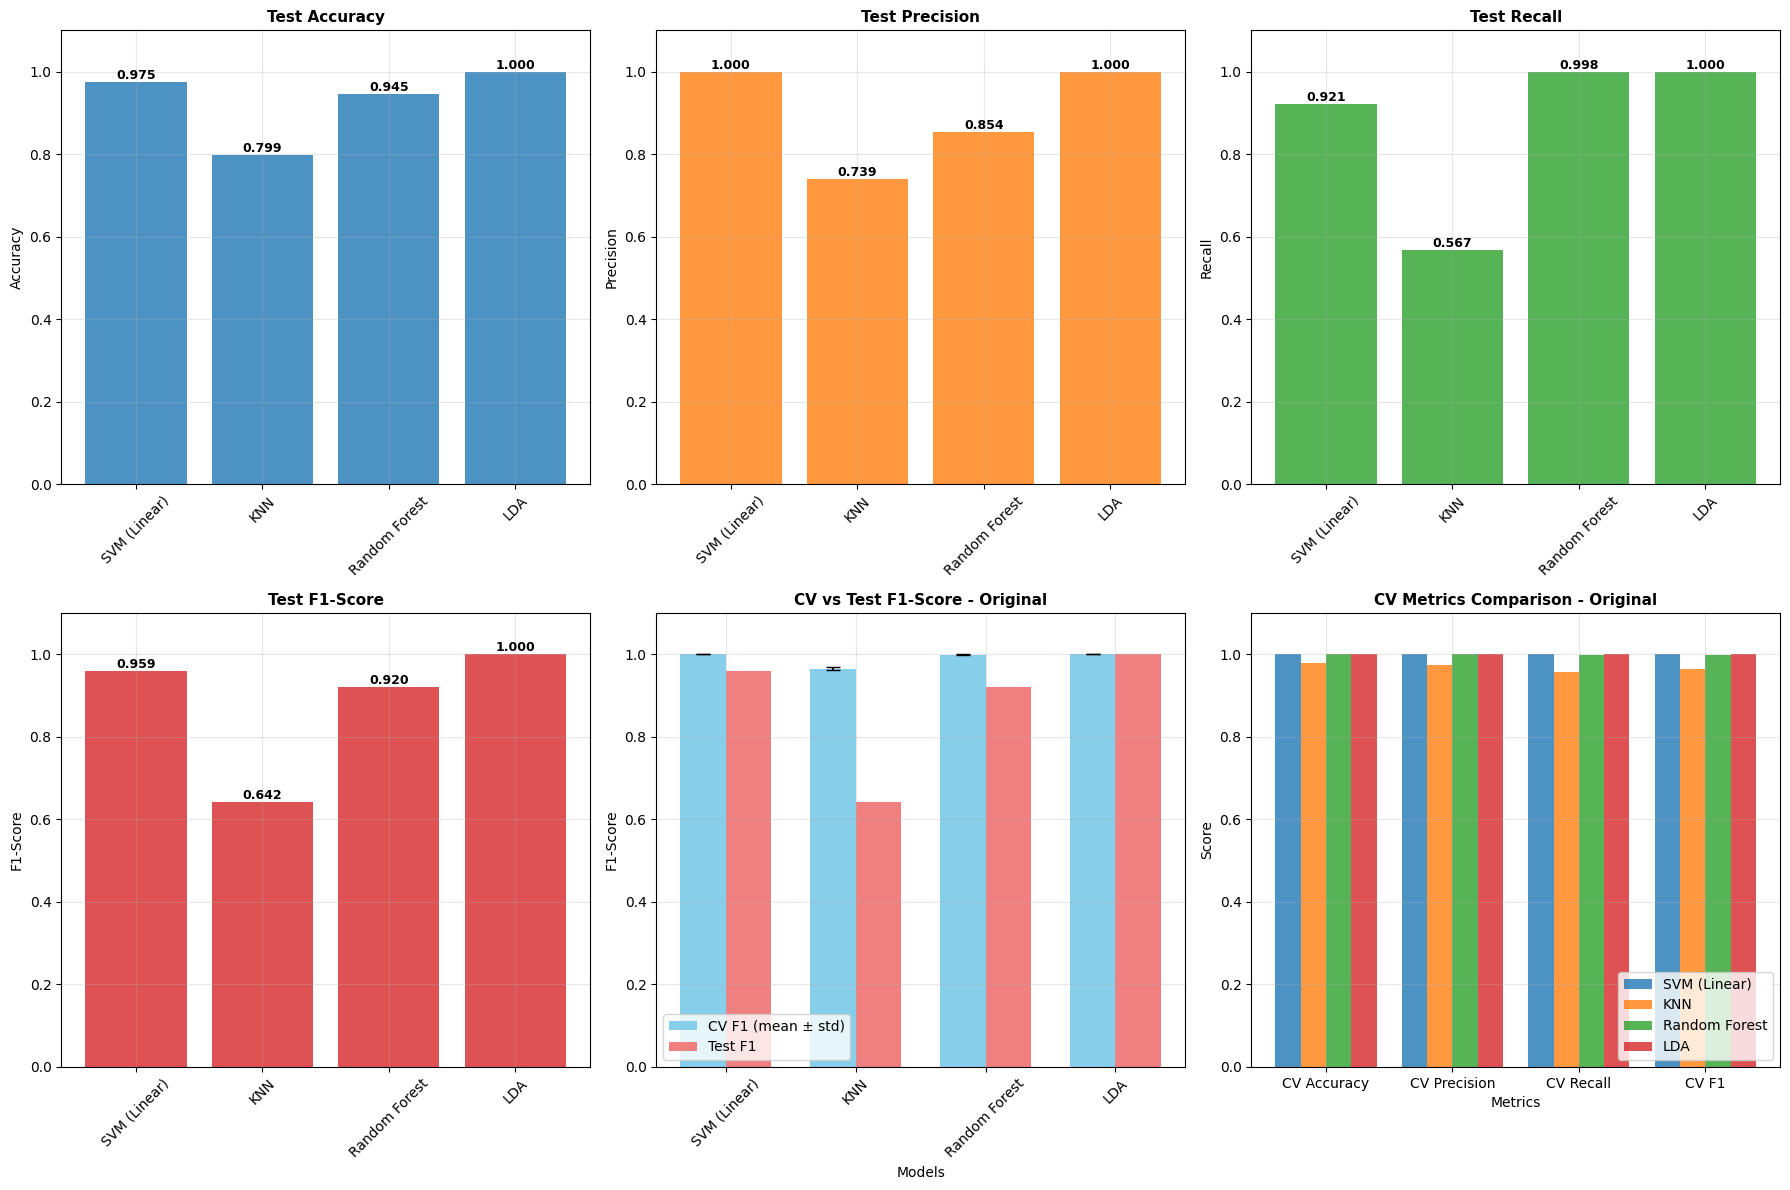


Performance comparison for Diffusion Synthetic dataset:
CV comparison plot saved to: /content/diffusion_synthetic_cv_comparison.png


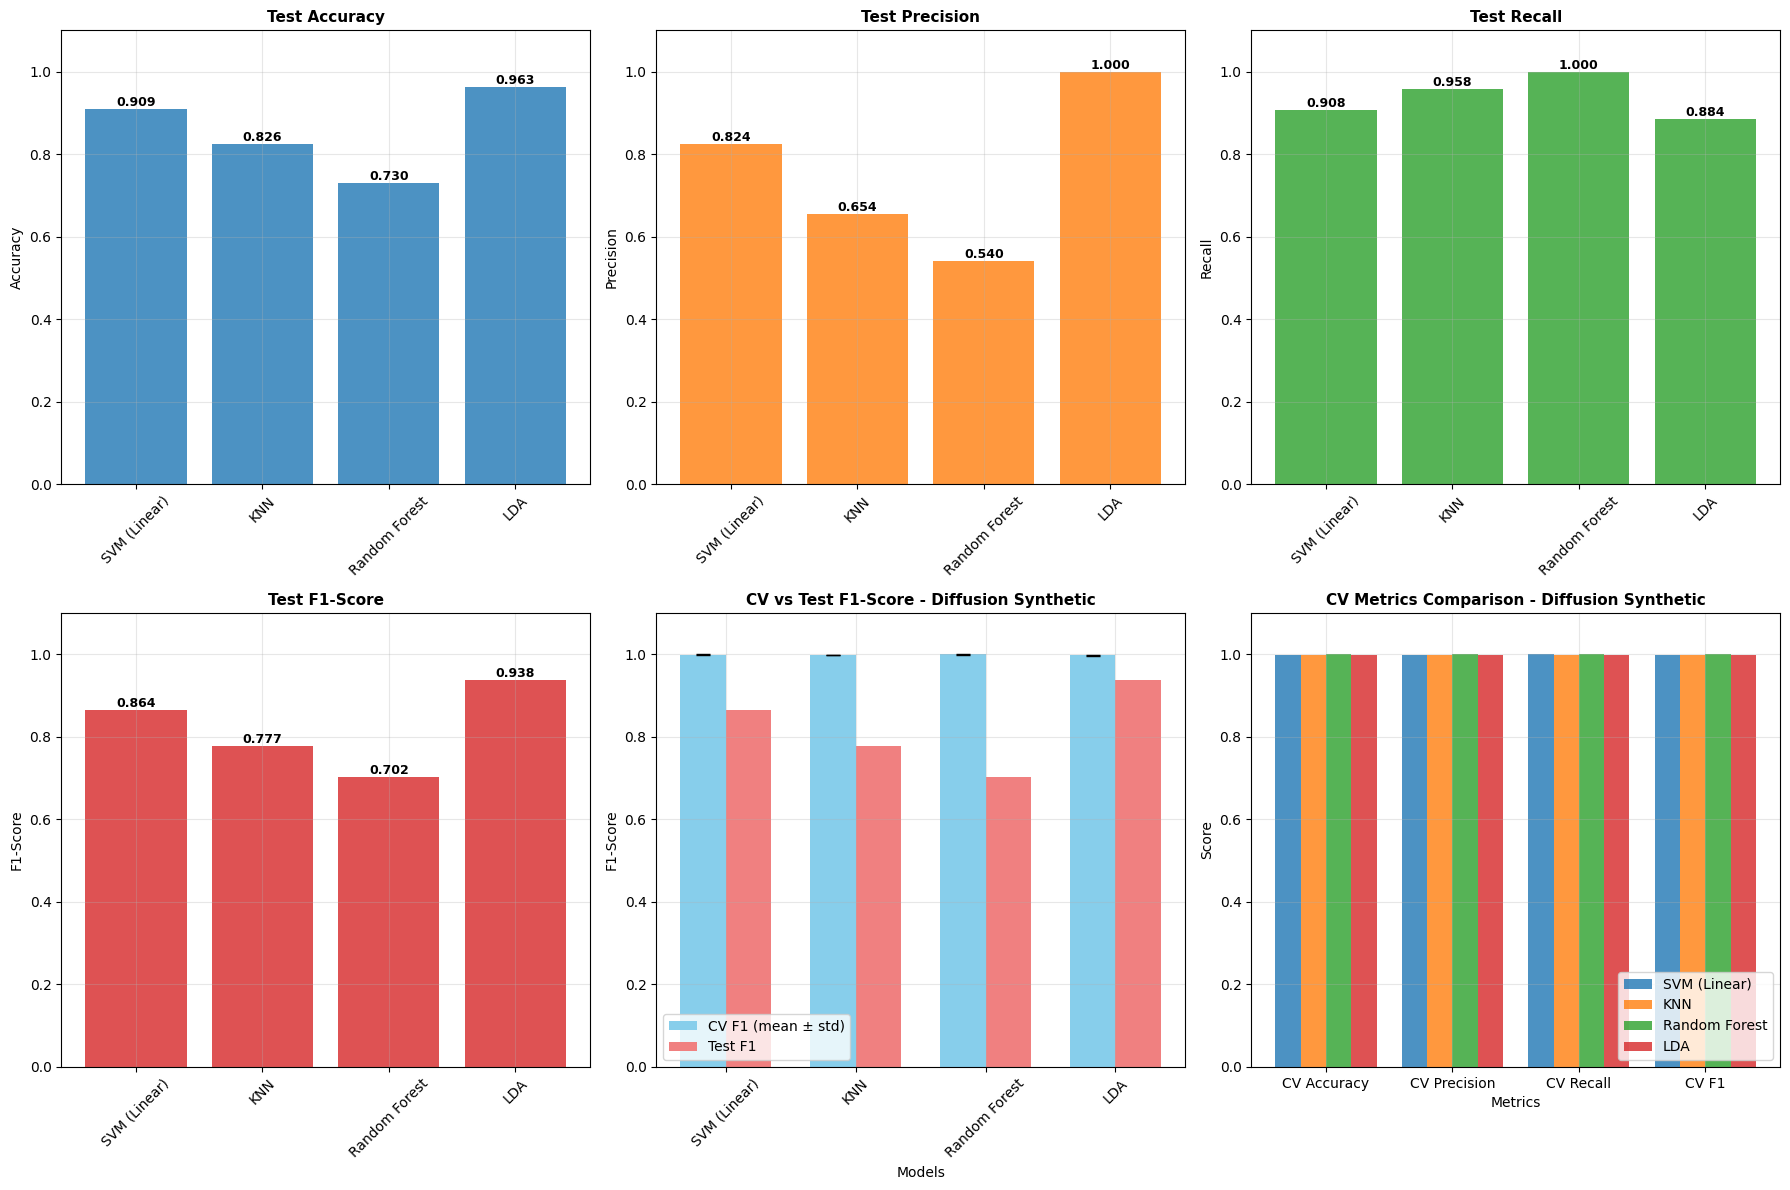


Performance comparison for Vae Synthetic dataset:
CV comparison plot saved to: /content/vae_synthetic_cv_comparison.png


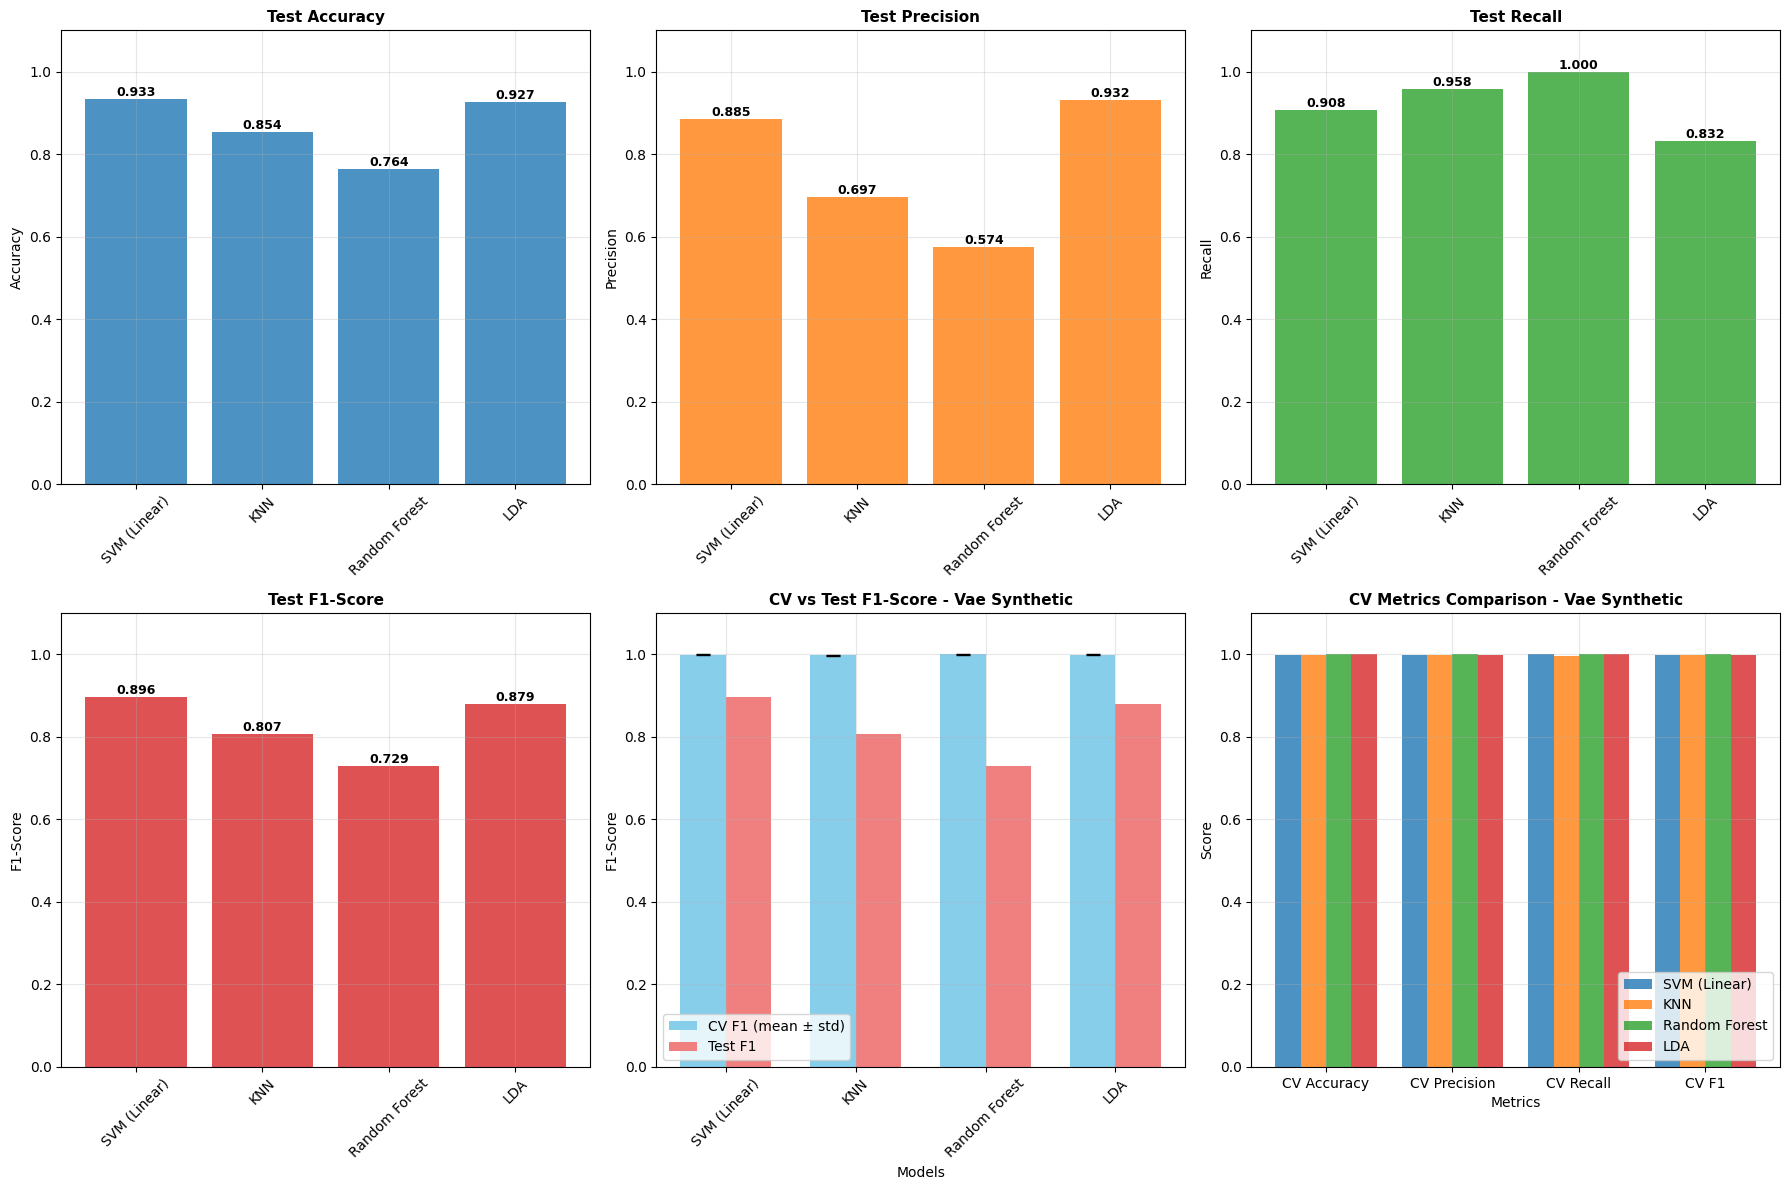


Performance comparison for Gan Synthetic dataset:
CV comparison plot saved to: /content/gan_synthetic_cv_comparison.png


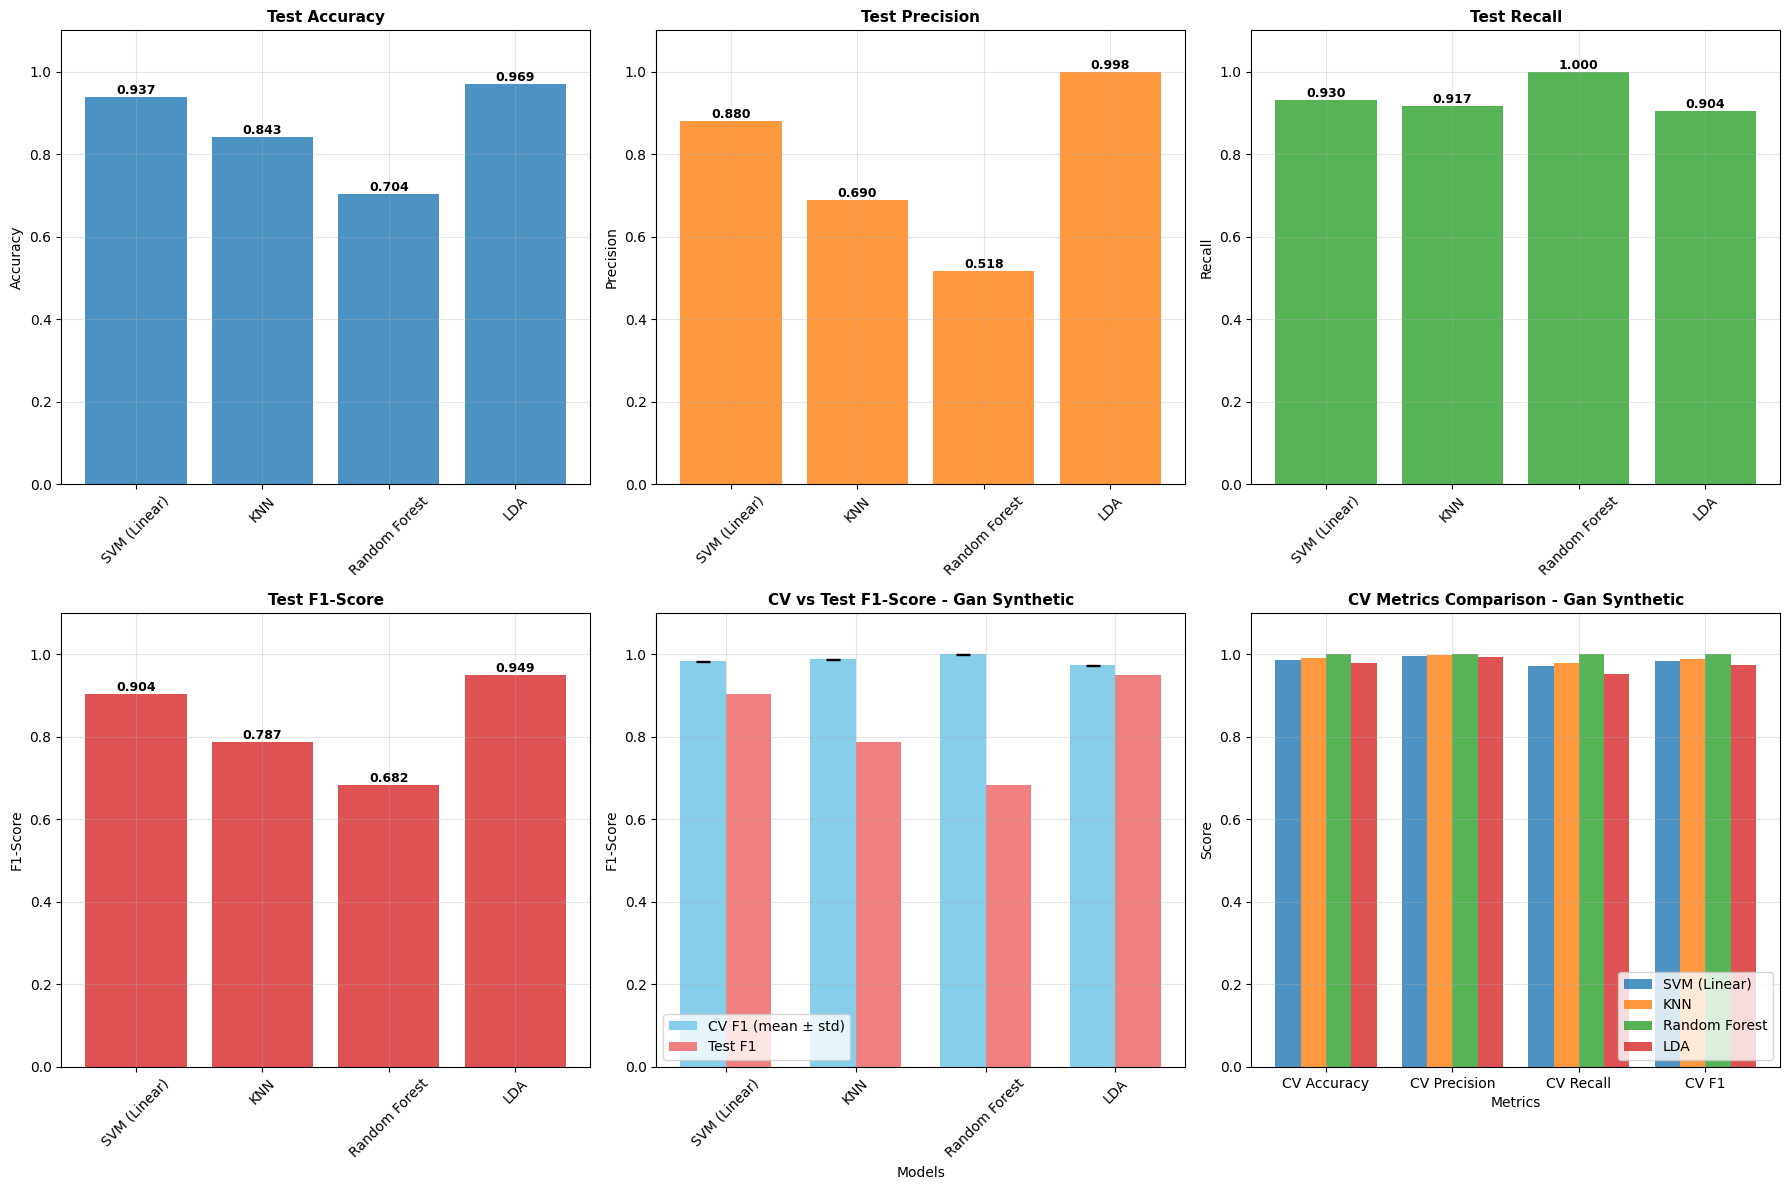


Pipeline execution completed successfully!


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Clean Generative AI Classification Analysis with 5-Fold Cross-Validation
=======================================================================

A clean, professional machine learning pipeline for comparing classification models
on original and synthetic datasets using 5-fold cross-validation.

Author: Clean version without symbols
Date: 2026-04-24
"""

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import os
from typing import Dict, Tuple, List, Any
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Configuration
CONFIG = {
    'test_size': 0.2,
    'random_state': 42,
    'cv_folds': 5,
    'figsize': (15, 12),
    'dpi': 100
}

# Updated paths based on your Google Drive structure
DATA_PATHS = {
    'X_train': '/content/drive/MyDrive/Generative AI/Data/x_train.csv',
    'X_test': '/content/drive/MyDrive/Generative AI/Data/x_test.csv',
    'y_train': '/content/drive/MyDrive/Generative AI/Data/y_train.csv',
    'y_test': '/content/drive/MyDrive/Generative AI/Data/y_test.csv'
}

SYNTHETIC_DATA_PATHS = {
    'diffusion': '/content/drive/MyDrive/Generative AI/diffusion/df_synthetic_1744.csv',
    'vae': '/content/drive/MyDrive/Generative AI/VAE/vae_synthetic_1774.csv',
    'gan': '/content/drive/MyDrive/Generative AI/GAN/gan_df.csv'
}


def load_data() -> Dict[str, pd.DataFrame]:
    """
    Load training and testing data from Google Drive.

    Returns:
        Dictionary containing dataframes for train/test features and labels
    """
    try:
        data = {
            'X_train': pd.read_csv(DATA_PATHS['X_train']),
            'X_test': pd.read_csv(DATA_PATHS['X_test']),
            'y_train': pd.read_csv(DATA_PATHS['y_train']),
            'y_test': pd.read_csv(DATA_PATHS['y_test'])
        }
        print(f"Successfully loaded data from Google Drive")
        for key, df in data.items():
            print(f"   {key}: {df.shape}")
        return data
    except FileNotFoundError as e:
        print(f"Error loading data: {e}")
        print("Please ensure all files exist in the specified Google Drive paths")
        return None
    except Exception as e:
        print(f"Unexpected error loading data: {e}")
        return None


def load_synthetic_data() -> Dict[str, pd.DataFrame]:
    """
    Load synthetic datasets generated by different models from Google Drive.

    Returns:
        Dictionary containing synthetic dataframes
    """
    synthetic_data = {}

    for name, filepath in SYNTHETIC_DATA_PATHS.items():
        try:
            df = pd.read_csv(filepath)
            print(f"Loaded {name} synthetic data: {df.shape}")

            # Add labels column with value 1 for all synthetic data
            if 'labels' not in df.columns:
                df['labels'] = 1
                print(f"   Added 'labels' column with value 1 to {name} data")

            synthetic_data[name] = df

        except FileNotFoundError:
            print(f"Warning: {name} synthetic data not found at {filepath}")
        except Exception as e:
            print(f"Error loading {name} synthetic data: {e}")

    return synthetic_data


def validate_features(X_train: pd.DataFrame, X_test: pd.DataFrame,
                     model_name: str = "") -> bool:
    """
    Basic feature validation before training.

    Args:
        X_train: Training features
        X_test: Testing features
        model_name: Name of the model for logging

    Returns:
        True if validation passes, False otherwise
    """
    print(f"Validating features for {model_name}")

    # Check column names match
    train_cols = set(X_train.columns)
    test_cols = set(X_test.columns)

    if train_cols != test_cols:
        print("Error: Column names don't match!")
        missing_in_test = train_cols - test_cols
        missing_in_train = test_cols - train_cols
        if missing_in_test:
            print(f"   Missing in test: {missing_in_test}")
        if missing_in_train:
            print(f"   Missing in train: {missing_in_train}")
        return False

    # Check for labels column
    if 'labels' in X_train.columns:
        print("Error: 'labels' found in X_train features!")
        return False
    if 'labels' in X_test.columns:
        print("Error: 'labels' found in X_test features!")
        return False

    print("Feature validation passed")
    return True


def evaluate_model_with_cv(model, X_train: pd.DataFrame, y_train: pd.Series,
                          X_test: pd.DataFrame, y_test: pd.Series,
                          model_name: str, cv_folds: int = 5) -> Dict[str, float]:
    """
    Train and evaluate a single model with cross-validation.

    Args:
        model: Sklearn model instance
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        y_test: Test labels
        model_name: Name of the model
        cv_folds: Number of cross-validation folds

    Returns:
        Dictionary containing evaluation metrics including CV scores
    """
    print(f"Training {model_name} with {cv_folds}-fold CV...")
    try:
        # Setup stratified k-fold cross-validation
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=CONFIG['random_state'])

        # Perform cross-validation
        cv_scores = cross_validate(model, X_train, y_train, cv=cv,
                                  scoring=['accuracy', 'precision', 'recall', 'f1'],
                                  return_train_score=True)

        # Print CV results
        print(f"\n{cv_folds}-Fold Cross-Validation Results:")
        print(f"   Accuracy:  {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std()*2:.4f})")
        print(f"   Precision: {cv_scores['test_precision'].mean():.4f} (+/- {cv_scores['test_precision'].std()*2:.4f})")
        print(f"   Recall:    {cv_scores['test_recall'].mean():.4f} (+/- {cv_scores['test_recall'].std()*2:.4f})")
        print(f"   F1-Score:  {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std()*2:.4f})")

        # Train final model on full training data
        model.fit(X_train, y_train)

        # Make predictions on test set
        y_pred = model.predict(X_test)

        # Calculate test metrics
        metrics = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, average='binary', zero_division=0),
            'CV_Accuracy_mean': cv_scores['test_accuracy'].mean(),
            'CV_Accuracy_std': cv_scores['test_accuracy'].std(),
            'CV_Precision_mean': cv_scores['test_precision'].mean(),
            'CV_Precision_std': cv_scores['test_precision'].std(),
            'CV_Recall_mean': cv_scores['test_recall'].mean(),
            'CV_Recall_std': cv_scores['test_recall'].std(),
            'CV_F1_mean': cv_scores['test_f1'].mean(),
            'CV_F1_std': cv_scores['test_f1'].std()
        }

        print(f"\nHold-out Test Set Results:")
        print(f"   Accuracy:  {metrics['Accuracy']:.4f}")
        print(f"   Precision: {metrics['Precision']:.4f}")
        print(f"   Recall:    {metrics['Recall']:.4f}")
        print(f"   F1-Score:  {metrics['F1-Score']:.4f}")

        return metrics

    except Exception as e:
        print(f"{model_name} failed: {e}")
        import traceback
        traceback.print_exc()
        return None


def train_and_evaluate(models: Dict[str, Any],
                      X_train: pd.DataFrame, y_train: pd.Series,
                      X_test: pd.DataFrame, y_test: pd.Series,
                      dataset_name: str = "Dataset") -> Dict[str, Dict]:
    """
    Train and evaluate multiple models with cross-validation.

    Args:
        models: Dictionary of model names and instances
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        y_test: Test labels
        dataset_name: Name of the dataset for reporting

    Returns:
        Dictionary containing all results
    """
    print(f"\n{'='*60}")
    print(f"EVALUATING MODELS ON {dataset_name.upper()} WITH {CONFIG['cv_folds']}-FOLD CV")
    print(f"{'='*60}")

    all_results = {}

    for model_name, model in models.items():
        print(f"\n{'-'*40}")
        print(f"MODEL: {model_name}")
        print(f"{'-'*40}")

        # Validate features first
        if not validate_features(X_train, X_test, model_name):
            print("Feature validation failed! Skipping this model.")
            continue

        # Evaluate model with cross-validation
        results = evaluate_model_with_cv(model, X_train, y_train, X_test, y_test,
                                        model_name, CONFIG['cv_folds'])

        if results:
            all_results[model_name] = results

    return all_results


def create_comparison_table(all_results: Dict[str, Dict]) -> pd.DataFrame:
    """
    Create a comparison table from all model results including CV scores.

    Args:
        all_results: Dictionary containing all model results

    Returns:
        DataFrame with comparison results
    """
    if not all_results:
        return pd.DataFrame()

    comparison_data = []
    for model_name, metrics in all_results.items():
        comparison_data.append({
            'Model': model_name,
            'Test Accuracy': f"{metrics['Accuracy']:.4f}",
            'Test Precision': f"{metrics['Precision']:.4f}",
            'Test Recall': f"{metrics['Recall']:.4f}",
            'Test F1-Score': f"{metrics['F1-Score']:.4f}",
            'CV F1 (mean±std)': f"{metrics['CV_F1_mean']:.4f}±{metrics['CV_F1_std']:.4f}"
        })

    return pd.DataFrame(comparison_data)


def create_ranking_table(all_results: Dict[str, Dict]) -> pd.DataFrame:
    """
    Create final ranking table sorted by CV F1-Score.

    Args:
        all_results: Dictionary containing all model results

    Returns:
        Sorted DataFrame with rankings
    """
    if not all_results:
        return pd.DataFrame()

    ranking_data = []
    for model_name, metrics in all_results.items():
        ranking_data.append({
            'Model': model_name,
            'Test F1': metrics['F1-Score'],
            'CV F1 (mean)': metrics['CV_F1_mean'],
            'CV F1 (std)': metrics['CV_F1_std'],
            'Test Accuracy': metrics['Accuracy'],
            'Test Precision': metrics['Precision'],
            'Test Recall': metrics['Recall']
        })

    ranking_df = pd.DataFrame(ranking_data)
    return ranking_df.sort_values('CV F1 (mean)', ascending=False)


def plot_model_comparison(all_results: Dict[str, Dict],
                         dataset_name: str = "",
                         save_dir: str = "/content"):
    """
    Create bar plot comparing model performance with CV error bars.

    Args:
        all_results: All model results
        dataset_name: Name of the dataset for the plot title
        save_dir: Directory to save the plot
    """
    if not all_results:
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    cv_metrics = ['CV_Accuracy_mean', 'CV_Precision_mean', 'CV_Recall_mean', 'CV_F1_mean']
    cv_stds = ['CV_Accuracy_std', 'CV_Precision_std', 'CV_Recall_std', 'CV_F1_std']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    model_names = list(all_results.keys())

    # Plot 1: Test set metrics
    for idx, (metric, color) in enumerate(zip(metrics, colors)):
        values = [all_results[model][metric] for model in model_names]
        bars = axes[idx].bar(model_names, values, color=color, alpha=0.8)

        for bar, value in zip(bars, values):
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{value:.3f}', ha='center', va='bottom',
                          fontsize=9, fontweight='bold')

        axes[idx].set_title(f'Test {metric}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(metric)
        axes[idx].set_ylim(0, 1.1)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(True, alpha=0.3)

    # Plot 2: CV F1 scores with error bars
    cv_f1_means = [all_results[model]['CV_F1_mean'] for model in model_names]
    cv_f1_stds = [all_results[model]['CV_F1_std'] for model in model_names]
    test_f1 = [all_results[model]['F1-Score'] for model in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    bars1 = axes[4].bar(x - width/2, cv_f1_means, width, yerr=cv_f1_stds,
                        label='CV F1 (mean ± std)', color='skyblue', capsize=5)
    bars2 = axes[4].bar(x + width/2, test_f1, width,
                        label='Test F1', color='lightcoral')

    axes[4].set_xlabel('Models')
    axes[4].set_ylabel('F1-Score')
    axes[4].set_title(f'CV vs Test F1-Score - {dataset_name}', fontsize=11, fontweight='bold')
    axes[4].set_xticks(x)
    axes[4].set_xticklabels(model_names, rotation=45)
    axes[4].legend()
    axes[4].grid(True, alpha=0.3)
    axes[4].set_ylim(0, 1.1)

    # Plot 3: All CV metrics comparison
    cv_metrics_names = ['CV Accuracy', 'CV Precision', 'CV Recall', 'CV F1']
    bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, model_name in enumerate(model_names):
        values = [all_results[model_name][cv_metrics[j]] for j in range(4)]
        x_pos = np.arange(4) + i * 0.2
        axes[5].bar(x_pos, values, 0.2, label=model_name, alpha=0.8)

    axes[5].set_xlabel('Metrics')
    axes[5].set_ylabel('Score')
    axes[5].set_title(f'CV Metrics Comparison - {dataset_name}', fontsize=11, fontweight='bold')
    axes[5].set_xticks(np.arange(4) + 0.3)
    axes[5].set_xticklabels(cv_metrics_names)
    axes[5].legend(loc='lower right')
    axes[5].grid(True, alpha=0.3)
    axes[5].set_ylim(0, 1.1)

    plt.tight_layout()

    # Save plot
    save_path = f"{save_dir}/{dataset_name.lower().replace(' ', '_')}_cv_comparison.png"
    plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
    print(f"CV comparison plot saved to: {save_path}")
    plt.show()


def print_classification_reports(all_results: Dict[str, Dict],
                               models: Dict[str, Any],
                               X_test: pd.DataFrame, y_test: pd.Series):
    """
    Print detailed classification reports for each model.

    Args:
        all_results: All model results
        models: Dictionary of models
        X_test: Test features
        y_test: Test labels
    """
    print("\n" + "="*60)
    print("DETAILED CLASSIFICATION REPORTS")
    print("="*60)

    for model_name in all_results.keys():
        if model_name in models:
            print(f"\n{'-'*40}")
            print(f"CLASSIFICATION REPORT: {model_name}")
            print(f"{'-'*40}")
            y_pred = models[model_name].predict(X_test)
            print(classification_report(y_test, y_pred, zero_division=0))


def print_cv_summary(all_results: Dict[str, Dict]):
    """
    Print cross-validation summary.

    Args:
        all_results: All model results including CV scores
    """
    print("\n" + "="*60)
    print("CROSS-VALIDATION SUMMARY")
    print("="*60)

    for model_name, metrics in all_results.items():
        print(f"\n{model_name}:")
        print(f"   CV F1-Score: {metrics['CV_F1_mean']:.4f} (±{metrics['CV_F1_std']:.4f})")
        print(f"   CV Accuracy: {metrics['CV_Accuracy_mean']:.4f} (±{metrics['CV_Accuracy_std']:.4f})")
        print(f"   Test F1-Score: {metrics['F1-Score']:.4f}")
        print(f"   Generalization Gap: {abs(metrics['CV_F1_mean'] - metrics['F1-Score']):.4f}")


def prepare_data(data: Dict[str, pd.DataFrame]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Prepare and clean the data for model training.

    Args:
        data: Dictionary containing raw data

    Returns:
        Tuple of (X_train, X_test, y_train, y_test)
    """
    X_train = data['X_train'].copy()
    X_test = data['X_test'].copy()
    y_train = data['y_train'].copy()
    y_test = data['y_test'].copy()

    # Ensure y is 1D array
    if len(y_train.shape) > 1 and y_train.shape[1] == 1:
        y_train = y_train.iloc[:, 0]
    if len(y_test.shape) > 1 and y_test.shape[1] == 1:
        y_test = y_test.iloc[:, 0]

    return X_train, X_test, y_train, y_test


def main():
    """
    Main execution function with 5-fold cross-validation.
    """
    print("GENERATIVE AI CLASSIFICATION PIPELINE WITH 5-FOLD CV")
    print("=" * 60)

    # Initialize models (create fresh instances for each dataset)
    base_models = {
        'SVM (Linear)': lambda: SVC(kernel='linear', random_state=CONFIG['random_state']),
        'KNN': lambda: KNeighborsClassifier(),
        'Random Forest': lambda: RandomForestClassifier(random_state=CONFIG['random_state']),
        'LDA': lambda: LinearDiscriminantAnalysis()
    }

    # Load data
    data = load_data()
    if data is None:
        print("Cannot proceed without data")
        return

    # Prepare original data
    X_train_orig, X_test_orig, y_train_orig, y_test_orig = prepare_data(data)

    # Load synthetic data
    synthetic_data = load_synthetic_data()

    # Process each dataset
    results_by_dataset = {}

    # 1. Original data only
    print("\nProcessing Original Dataset")
    models_orig = {name: model_fn() for name, model_fn in base_models.items()}
    results_orig = train_and_evaluate(
        models_orig, X_train_orig, y_train_orig, X_test_orig, y_test_orig, "Original"
    )
    results_by_dataset['Original'] = results_orig

    # 2. Process each synthetic dataset
    for synth_name, synth_df in synthetic_data.items():
        print(f"\nProcessing {synth_name.upper()} Synthetic Dataset")

        # Create combined dataset
        X_train_combined = X_train_orig.copy()
        X_train_combined['labels'] = y_train_orig

        # Select same columns as synthetic data
        selected_columns = synth_df.columns.tolist()
        # Make sure we have all columns from synthetic data in original
        available_columns = [col for col in selected_columns if col in X_train_combined.columns]
        X_train_combined = X_train_combined[available_columns]

        # Ensure synthetic data has same columns
        synth_df = synth_df[available_columns]

        # Combine datasets
        combined_data = pd.concat([X_train_combined, synth_df], axis=0)

        # Separate features and target
        y_train_combined = combined_data['labels']
        X_train_combined = combined_data.drop('labels', axis=1)

        # Use original test data (with selected columns, excluding 'labels')
        test_columns = [col for col in available_columns if col != 'labels']
        X_test_combined = X_test_orig[test_columns]
        y_test_combined = y_test_orig

        # Create fresh model instances
        models_synth = {name: model_fn() for name, model_fn in base_models.items()}

        results_synth = train_and_evaluate(
            models_synth, X_train_combined, y_train_combined,
            X_test_combined, y_test_combined, f"{synth_name.upper()} Synthetic"
        )
        results_by_dataset[f"{synth_name.title()} Synthetic"] = results_synth

    # Final comparison across all datasets
    print("\n\n" + "="*80)
    print("FINAL COMPARISON ACROSS ALL DATASETS")
    print("="*80)

    for dataset_name, results in results_by_dataset.items():
        if results:  # Only print if we have results
            print(f"\n{dataset_name.upper()} DATASET RESULTS:")
            comparison_df = create_comparison_table(results)
            print(comparison_df.to_string(index=False))

            # Create ranking
            ranking_df = create_ranking_table(results)
            print(f"\n{dataset_name.upper()} DATASET RANKING BY CV F1-SCORE:")
            print(ranking_df.round(4).to_string(index=False))

            # Print CV summary
            print_cv_summary(results)

    # Plot comparisons
    print("\nGenerating visualizations...")
    for dataset_name, results in results_by_dataset.items():
        if results:
            print(f"\nPerformance comparison for {dataset_name} dataset:")
            plot_model_comparison(results, dataset_name, save_dir="/content")

    print("\nPipeline execution completed successfully!")

    return results_by_dataset


if __name__ == "__main__":
    results = main()

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

def evaluate_model_cv(model, X_train: pd.DataFrame, y_train: pd.Series,
                      X_test: pd.DataFrame, y_test: pd.Series,
                      model_name: str, cv_folds: int = 5) -> Dict[str, float]:
    """
    Train and evaluate a single model with cross-validation.

    Args:
        model: Sklearn model instance
        X_train: Training features
        y_train: Training labels
        X_test: Test features
        y_test: Test labels
        model_name: Name of the model
        cv_folds: Number of cross-validation folds

    Returns:
        Dictionary containing evaluation metrics
    """
    print(f"Training {model_name} with {cv_folds}-fold CV...")
    try:
        # Setup stratified k-fold cross-validation
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=CONFIG['random_state'])

        # Cross-validation scores
        cv_scores = cross_validate(model, X_train, y_train, cv=cv,
                                  scoring=['accuracy', 'precision', 'recall', 'f1'],
                                  return_train_score=True)

        # Print CV results
        print(f"\n{cv_folds}-Fold Cross-Validation Results:")
        print(f"   Accuracy:  {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std()*2:.4f})")
        print(f"   Precision: {cv_scores['test_precision'].mean():.4f} (+/- {cv_scores['test_precision'].std()*2:.4f})")
        print(f"   Recall:    {cv_scores['test_recall'].mean():.4f} (+/- {cv_scores['test_recall'].std()*2:.4f})")
        print(f"   F1-Score:  {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std()*2:.4f})")

        # Train final model on full training data
        model.fit(X_train, y_train)

        # Evaluate on hold-out test set
        y_pred = model.predict(X_test)

        # Calculate test metrics
        metrics = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='binary', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='binary', zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, average='binary', zero_division=0),
            'CV_Accuracy_mean': cv_scores['test_accuracy'].mean(),
            'CV_Accuracy_std': cv_scores['test_accuracy'].std(),
            'CV_F1_mean': cv_scores['test_f1'].mean(),
            'CV_F1_std': cv_scores['test_f1'].std()
        }

        print(f"\nHold-out Test Set Results:")
        print(f"   Accuracy:  {metrics['Accuracy']:.4f}")
        print(f"   Precision: {metrics['Precision']:.4f}")
        print(f"   Recall:    {metrics['Recall']:.4f}")
        print(f"   F1-Score:  {metrics['F1-Score']:.4f}")

        return metrics

    except Exception as e:
        print(f"{model_name} failed: {e}")
        import traceback
        traceback.print_exc()
        return None


def create_comparison_table_cv(all_results: Dict[str, Dict]) -> pd.DataFrame:
    """
    Create a comparison table with CV metrics.
    """
    if not all_results:
        return pd.DataFrame()

    comparison_data = []
    for model_name, metrics in all_results.items():
        comparison_data.append({
            'Model': model_name,
            'Test Accuracy': f"{metrics['Accuracy']:.4f}",
            'Test F1-Score': f"{metrics['F1-Score']:.4f}",
            'CV F1 (mean)': f"{metrics['CV_F1_mean']:.4f}",
            'CV F1 (std)': f"{metrics['CV_F1_std']:.4f}",
            'Test Precision': f"{metrics['Precision']:.4f}",
            'Test Recall': f"{metrics['Recall']:.4f}"
        })

    return pd.DataFrame(comparison_data)


def plot_cv_results(all_results: Dict[str, Dict], dataset_name: str = "", save_dir: str = "/content"):
    """
    Plot cross-validation results vs test results.
    """
    if not all_results:
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    model_names = list(all_results.keys())

    # Plot CV F1 scores with error bars
    cv_f1_means = [all_results[model]['CV_F1_mean'] for model in model_names]
    cv_f1_stds = [all_results[model]['CV_F1_std'] for model in model_names]
    test_f1 = [all_results[model]['F1-Score'] for model in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    bars1 = ax1.bar(x - width/2, cv_f1_means, width, yerr=cv_f1_stds,
                    label='CV F1 (mean ± 2std)', color='skyblue', capsize=5)
    bars2 = ax1.bar(x + width/2, test_f1, width,
                    label='Test F1', color='lightcoral')

    ax1.set_xlabel('Models')
    ax1.set_ylabel('F1-Score')
    ax1.set_title(f'Cross-Validation vs Test F1-Score - {dataset_name}')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.1)

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    # Plot all metrics comparison
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for model_idx, model_name in enumerate(model_names):
        values = [all_results[model_name][m] for m in metrics]
        x_pos = np.arange(len(metrics)) + model_idx * 0.2
        ax2.bar(x_pos, values, 0.2, label=model_name, alpha=0.8)

    ax2.set_xlabel('Metrics')
    ax2.set_ylabel('Score')
    ax2.set_title(f'Model Performance Comparison - {dataset_name}')
    ax2.set_xticks(np.arange(len(metrics)) + 0.3)
    ax2.set_xticklabels(metrics)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.1)

    plt.tight_layout()
    save_path = f"{save_dir}/{dataset_name.lower().replace(' ', '_')}_cv_comparison.png"
    plt.savefig(save_path, dpi=CONFIG['dpi'], bbox_inches='tight')
    print(f"CV comparison plot saved to: {save_path}")
    plt.show()


# Update main() to use CV evaluation
def main():
    """
    Main execution function with cross-validation.
    """
    print("GENERATIVE AI CLASSIFICATION PIPELINE WITH 5-FOLD CV")
    print("=" * 60)

    # Initialize models
    models = {
        'SVM (Linear)': SVC(kernel='linear', random_state=CONFIG['random_state']),
        'KNN': KNeighborsClassifier(),
        'Random Forest': RandomForestClassifier(random_state=CONFIG['random_state']),
        'LDA': LinearDiscriminantAnalysis()
    }

    # Load data
    data = load_data()
    if data is None:
        print("Cannot proceed without data")
        return

    # Prepare original data
    X_train_orig, X_test_orig, y_train_orig, y_test_orig = prepare_data(data)

    # Load synthetic data
    synthetic_data = load_synthetic_data()

    # Process each dataset with CV
    results_by_dataset = {}

    # 1. Original data
    print("\nProcessing Original Dataset with 5-Fold CV")
    original_models = {name: model.__class__(**model.get_params())
                      for name, model in models.items()}  # Fresh model instances

    results_orig = {}
    for model_name, model in original_models.items():
        results = evaluate_model_cv(model, X_train_orig, y_train_orig,
                                   X_test_orig, y_test_orig, model_name, cv_folds=5)
        if results:
            results_orig[model_name] = results

    results_by_dataset['Original'] = results_orig
    plot_cv_results(results_orig, "Original")

    # Continue with synthetic datasets...
    # [Rest of the synthetic data processing with CV]
